# Load all necessary packages

Read in all necessary packages:

In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pandas.io.parsers import read_csv
import scanpy as sc
import numpy as np
from functools import reduce
from anndata import AnnData, read_h5ad
import loompy
import collections
import scipy
import math
from matplotlib.colors import LinearSegmentedColormap
import random
from sklearn.mixture import GaussianMixture
from scipy.stats import poisson

import scipy
import tqdm
from statsmodels.stats.multitest import multipletests
import matplotlib.patches as mpatches

/var/folders/pb/hvc2shb53x194_v0c3h_jyccsf3dhb/T/ipykernel_14380/284414565.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


OMP: Info #273: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [2]:
sc.set_figure_params(dpi = 80)
sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

In [3]:
greens_r = sns.blend_palette(['black','#238b45', '#75c477', '#c8e9c1' ], as_cmap = True)
purples_r = sns.blend_palette(['black','#6a51a3', '#9e9bc8', '#dadaeb'], as_cmap = True)
oranges_r = sns.blend_palette(['black','#d94801', '#fd8e3d', '#fdd1a3'], as_cmap = True)

k27_k4 = sns.blend_palette(['#6a51a3', '#9e9bc8', '#dadaeb','#c8e9c1','#75c477','#238b45'], as_cmap = True)
k4_k27 = sns.blend_palette(['#238b45', '#75c477', '#c8e9c1' ,'#dadaeb','#9e9bc8','#6a51a3' ], as_cmap = True)
Green='#238b45'
Purple='#6a51a3'
Orange='#d94801'


In [4]:
cols = ['grey','skyblue','orange','red']
cols2 = ['white','deepskyblue','orange','red','grey']

leg_dict2 = {'negative': 'grey','positive': 'skyblue','going up': 'orange','going down': 'red'}
coldict=dict(zip(list(pd.DataFrame([0,1,2,3,4]).astype('category')[0]), cols2))
leg_dict = {'negative': 'white', 'positive': 'deepskyblue', 'going up': 'orange', 'going down': 'red'}

In [5]:
pseudo = []
def bintable(df, stepsize):    
    df = df.sort_values(by = ['hour','pseudotime'],ascending=True)
    df['order'] = list(range(0,len(df)))
    df['steps'] = df['order'].apply(lambda x: np.floor(x/stepsize))
    binned_table_mean = {}
    binned_table_sum = {}
    celltype = []
    for step in df['steps'].unique():
        binned_table_mean[step] = df[df['steps'] == step].mean(numeric_only=True)
        binned_table_sum[step] = df[df['steps'] == step].sum(numeric_only=True)
        celltype.append(df[df['steps'] == step]['hour'].value_counts().sort_values(ascending=False).index[0])
    binned_pseudo = pd.DataFrame(pd.DataFrame(binned_table_mean).T['pseudotime'])
    binned_pseudo['celltype'] = celltype
    binned_final_mean = pd.DataFrame(binned_table_mean).T.drop(['order','steps','pseudotime'],axis = 1)
    binned_final_sum = pd.DataFrame(binned_table_sum).T.drop(['order','steps','pseudotime'],axis = 1)
    binned_pseudo = binned_pseudo.iloc[:-1,:]
    binned_final_mean = binned_final_mean.iloc[:-1,:]
    binned_final_sum = binned_final_sum.iloc[:-1,:]
    return binned_pseudo, binned_final_mean, binned_final_sum

## K4me3 TSS table

In [6]:
pwd

'/Users/m.blotenburg/Documents/Projects/TCHIC/data/jupyter_notebooks/2024/fig4'

In [7]:
tss_k4 = pd.read_csv('../data/peter/20240114_H3K4me3_sc_selected_dyn_TSS_v2.csv', sep = '\t', index_col=0)

In [8]:
tss_k4.index.name = 'cell'
tss_k4.head(2)

,Dlgap1:1,Dlgap1:2,Dlgap1:3,Dlgap1:4,Dlgap1:5,Ank3:1,Ank3:2,Ank3:3,Ank3:4,Ank3:5,...,C2cd2:1,C2cd2:2,C2cd2:3,C2cd2:4,C2cd2:5,Rcan1:1,Rcan1:2,Rcan1:3,Prickle1:1,Prickle1:2
cell,,,,,,,,,,,,,,,,,,,,,
PZ-MB-TChIC-Gastd6-rep3-H3K4me3-6_78,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PZ-MB-TChIC-Gastd7-rep2-H3K4me3-2_72,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
tss_k4.shape

(25344, 525)

## K27me3 TSS table

In [10]:
tss_k27 = pd.read_csv('../data/peter/20240114_H3K27me3_sc_selected_dyn_TSS_v2.csv', sep = '\t', index_col=0)
tss_k27.index.name = 'cell'

In [11]:
tss_k27.head(2)

,Dlgap1:1,Dlgap1:2,Dlgap1:3,Dlgap1:4,Dlgap1:5,Ank3:1,Ank3:2,Ank3:3,Ank3:4,Ank3:5,...,C2cd2:1,C2cd2:2,C2cd2:3,C2cd2:4,C2cd2:5,Rcan1:1,Rcan1:2,Rcan1:3,Prickle1:1,Prickle1:2
cell,,,,,,,,,,,,,,,,,,,,,
PZ-MB-TChIC-Gastd4-rep4-H3K27me3-5_139,1.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PZ-MB-TChIC-Gastd3-rep3-H3K27me3-2_45,0.0,1.0,1.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0


In [12]:
tss_k27.shape

(25344, 525)

## RNA table

In [13]:
tss_rna = pd.read_csv('../data/peter/20240114_RNA_sc_selected_dyn_TSS_v2.csv', sep = '\t', index_col=0)
tss_rna.index.name = 'cell'

In [14]:
tss_rna = tss_rna.T
tss_rna.head(2)

cell,Dlgap1:1,Dlgap1:2,Dlgap1:3,Dlgap1:4,Dlgap1:5,Ank3:1,Ank3:2,Ank3:3,Ank3:4,Ank3:5,...,C2cd2:1,C2cd2:2,C2cd2:3,C2cd2:4,C2cd2:5,Rcan1:1,Rcan1:2,Rcan1:3,Prickle1:1,Prickle1:2
PZ-MB-TChIC-Gastd3-rep4-H3K27me3-1_181,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
PZ-MB-TChIC-Gastd5-rep4-H3K27me3-5_44,0,0,0,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,3,3


In [15]:
tss_rna.shape

(50688, 525)

## plotting

## some QC

Text(0.5, 1.0, 'K4 cells')

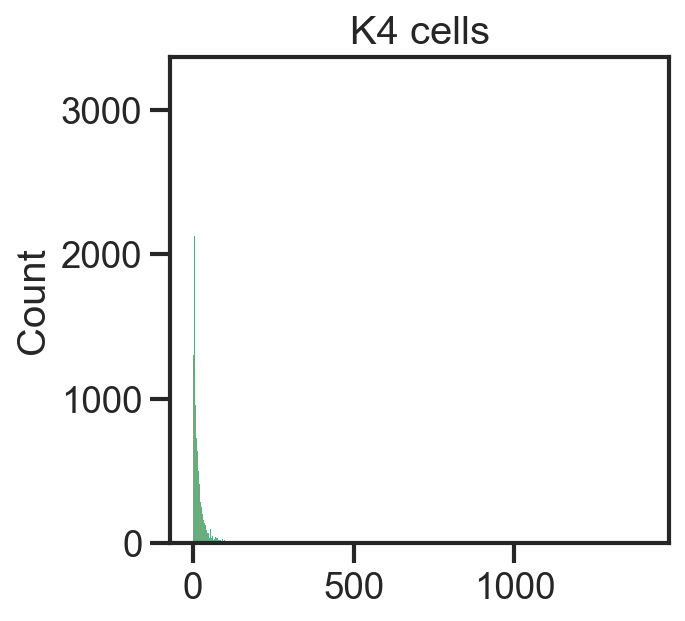

In [16]:
sns.histplot(tss_k4.sum(axis=1), color = Green)
plt.title('K4 cells')

Text(0.5, 1.0, 'K4 genes')

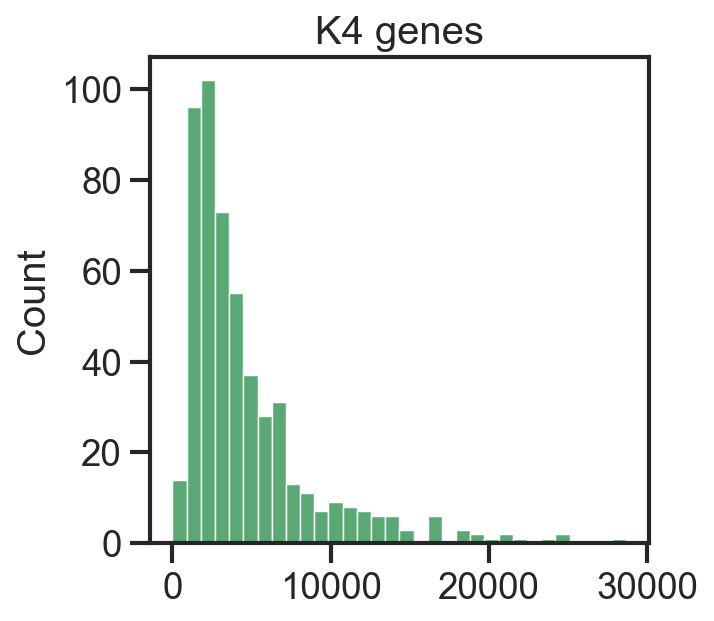

In [17]:
sns.histplot(tss_k27.sum(axis=0), color = Green)
plt.title('K4 genes')

Text(0.5, 1.0, 'K27 cells')

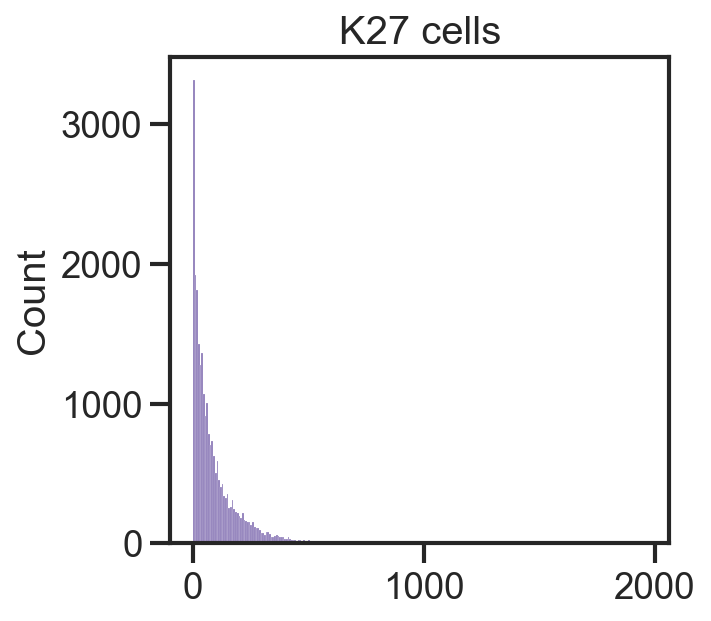

In [18]:
sns.histplot(tss_k27.sum(axis=1), color = Purple)
plt.title('K27 cells')

Text(0.5, 1.0, 'K27 genes')

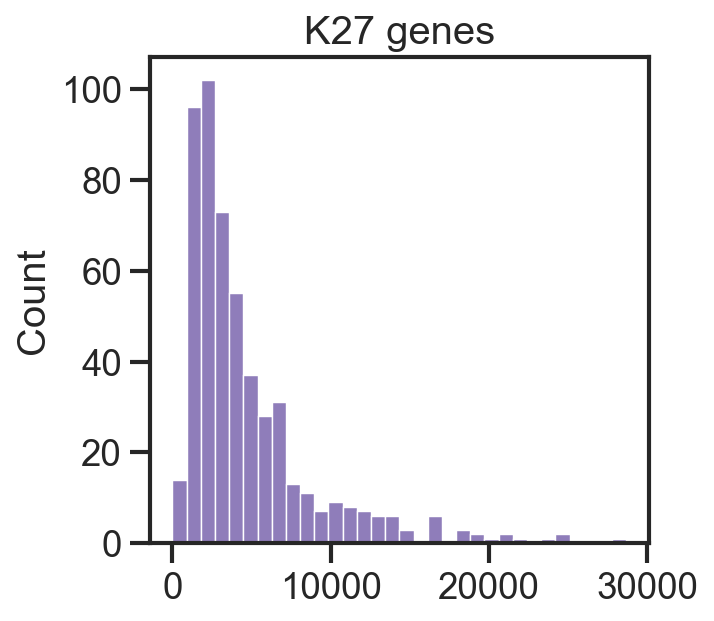

In [19]:
sns.histplot(tss_k27.sum(axis=0), color = Purple)
plt.title('K27 genes')

Text(0.5, 1.0, 'RNA cells')

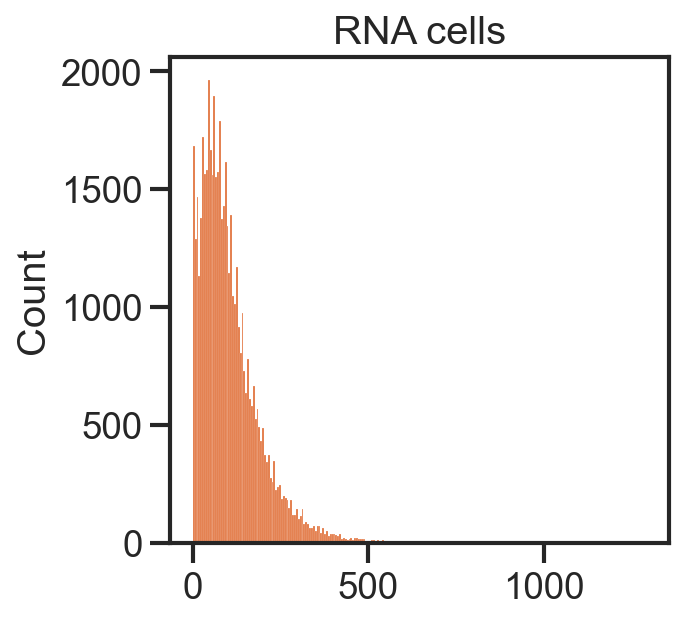

In [20]:
sns.histplot(tss_rna.sum(axis=1), color = Orange)
plt.title('RNA cells')

Text(0.5, 1.0, 'RNA genes')

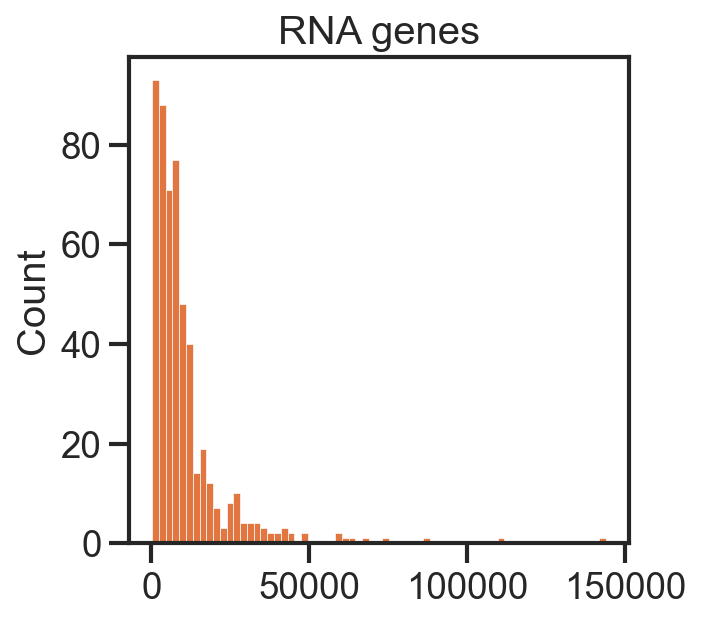

In [21]:
sns.histplot(tss_rna.sum(axis=0), color = Orange)
plt.title('RNA genes')

In [22]:
tss_k4.sum(axis=1).sort_values().value_counts()

0.0       1782
1.0       1425
2.0       1302
3.0       1171
5.0       1122
          ... 
248.0        1
163.0        1
169.0        1
242.0        1
1411.0       1
Length: 321, dtype: int64

In [23]:
tss_k27.sum(axis=1).sort_values().value_counts()

0.0       702
1.0       525
3.0       419
2.0       380
4.0       368
         ... 
689.0       1
691.0       1
483.0       1
695.0       1
1966.0      1
Length: 778, dtype: int64

In [24]:
tss_rna.sum(axis=1).sort_values().value_counts()

53      361
49      348
45      343
41      342
50      341
       ... 
586       1
585       1
584       1
476       1
1293      1
Length: 632, dtype: int64

## load adata file, subset dataframes

In [25]:
# remove zero counts
tss_k4 = tss_k4[tss_k4.sum(axis=1) != 0 ]
tss_k27 = tss_k27[tss_k27.sum(axis=1) != 0 ]

In [26]:
idx = tss_k4.columns.str.split(':', expand=True)
tss_k4.columns = idx
tss_k4.columns.names = ['gene','TSS']

In [27]:
idx = tss_k27.columns.str.split(':', expand=True)
tss_k27.columns = idx
tss_k27.columns.names = ['gene','TSS']

In [28]:
tss_k4.head(3)

gene                                  Dlgap1                     Ank3       \
TSS                                        1    2    3    4    5    1    2   
cell                                                                         
PZ-MB-TChIC-Gastd6-rep3-H3K4me3-6_78     0.0  0.0  0.0  0.0  0.0  0.0  0.0   
PZ-MB-TChIC-Gastd6-rep2-H3K4me3-1_346    0.0  0.0  0.0  0.0  0.0  0.0  0.0   
PZ-MB-TChIC-mESCs-rep4-H3K4me3-4_135     0.0  0.0  0.0  0.0  0.0  0.0  0.0   

gene                                                  ... C2cd2            \
TSS                                      3    4    5  ...     1    2    3   
cell                                                  ...                   
PZ-MB-TChIC-Gastd6-rep3-H3K4me3-6_78   0.0  0.0  0.0  ...   0.0  1.0  0.0   
PZ-MB-TChIC-Gastd6-rep2-H3K4me3-1_346  0.0  0.0  0.0  ...   0.0  0.0  0.0   
PZ-MB-TChIC-mESCs-rep4-H3K4me3-4_135   0.0  0.0  0.0  ...   0.0  0.0  0.0   

gene                                            Rcan1           Prickle1       
TSS                                      4    5     1    2    3        1    2  
cell                                                                           
PZ-MB-TChIC-Gastd6-rep3-H3K4me3-6_78   0.0  0.0   0.0  0.0  0.0      0.0  0.0  
PZ-MB-TChIC-Gastd6-rep2-H3K4me3-1_346  0.0  0.0   0.0  0.0  0.0      0.0  0.0  
PZ-MB-TChIC-mESCs-rep4-H3K4me3-4_135   0.0  0.0   0.0  0.0  0.0      0.0  0.0  

[3 rows x 525 columns]

In [29]:
tss_k27.head(3)

gene                                   Dlgap1                     Ank3       \
TSS                                         1    2    3    4    5    1    2   
cell                                                                          
PZ-MB-TChIC-Gastd4-rep4-H3K27me3-5_139    1.0  0.0  0.0  0.0  0.0  2.0  0.0   
PZ-MB-TChIC-Gastd3-rep3-H3K27me3-2_45     0.0  1.0  1.0  0.0  0.0  2.0  1.0   
PZ-MB-TChIC-mESCs-rep4-H3K27me3-4_157     0.0  1.0  1.0  2.0  2.0  1.0  0.0   

gene                                                   ... C2cd2            \
TSS                                       3    4    5  ...     1    2    3   
cell                                                   ...                   
PZ-MB-TChIC-Gastd4-rep4-H3K27me3-5_139  0.0  0.0  0.0  ...   0.0  0.0  0.0   
PZ-MB-TChIC-Gastd3-rep3-H3K27me3-2_45   0.0  0.0  0.0  ...   0.0  1.0  0.0   
PZ-MB-TChIC-mESCs-rep4-H3K27me3-4_157   2.0  2.0  2.0  ...   1.0  1.0  0.0   

gene                                             Rcan1           Prickle1       
TSS                                       4    5     1    2    3        1    2  
cell                                                                            
PZ-MB-TChIC-Gastd4-rep4-H3K27me3-5_139  0.0  0.0   0.0  0.0  0.0      0.0  0.0  
PZ-MB-TChIC-Gastd3-rep3-H3K27me3-2_45   0.0  0.0   0.0  0.0  0.0      1.0  2.0  
PZ-MB-TChIC-mESCs-rep4-H3K27me3-4_157   0.0  1.0   0.0  2.0  1.0      1.0  2.0  

[3 rows x 525 columns]

In [30]:
tss_rna = tss_rna[tss_rna.sum(axis=1) != 0 ]
idx = tss_rna.columns.str.split(':', expand=True)
tss_rna.columns = idx
tss_rna.columns.names = ['gene','TSS']
tss_rna.head(3)

gene                                   Dlgap1             Ank3              \
TSS                                         1  2  3  4  5    1  2  3  4  5   
PZ-MB-TChIC-Gastd3-rep4-H3K27me3-1_181      0  0  0  0  0    0  0  0  0  0   
PZ-MB-TChIC-Gastd5-rep4-H3K27me3-5_44       0  0  0  0  0    0  2  0  0  0   
PZ-MB-TChIC-Gastd4-rep3-H3K4me3-2_299       0  0  0  0  0    0  0  0  0  0   

gene                                    ... C2cd2             Rcan1        \
TSS                                     ...     1  2  3  4  5     1  2  3   
PZ-MB-TChIC-Gastd3-rep4-H3K27me3-1_181  ...     0  0  0  0  0     0  0  0   
PZ-MB-TChIC-Gastd5-rep4-H3K27me3-5_44   ...     0  0  0  0  0     0  0  0   
PZ-MB-TChIC-Gastd4-rep3-H3K4me3-2_299   ...     0  0  0  0  0     0  0  0   

gene                                   Prickle1     
TSS                                           1  2  
PZ-MB-TChIC-Gastd3-rep4-H3K27me3-1_181        0  0  
PZ-MB-TChIC-Gastd5-rep4-H3K27me3-5_44         3  3  
PZ-MB-TChIC-Gastd4-rep3-H3K4me3-2_299         1  0  

[3 rows x 525 columns]

In [31]:
adata = sc.read_h5ad('../../2023/data/20230704_adata_all.h5ad')
adata

AnnData object with n_obs × n_vars = 38117 × 27384
    obs: 'batch', 'day', 'replicates', 'mark', 'day_rep', 'dataset', 'hour', 'celltype', 'celltype_general', 'lineage', 'lin_day', 'percent_mito', 'n_counts', 'n_counts_proteincoding', 'n_genes', 'S_score', 'G2M_score', 'phase', 'enrichment', 'coverage', 'QC', 'pseudotime', 'pseudotime2'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene', 'gene_biotype', 'gene_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'QC_colors', 'batch_colors', 'celltype_colors', 'celltype_general_colors', 'dataset_colors', 'day_colors', 'hour_colors', 'hvg', 'leiden', 'leiden_colors', 'lin_day_colors', 'lineage_colors', 'log1p', 'mark_colors', 'neighbors', 'old_celltype_colors', 'old_leiden_general_colors', 'old_leiden_merge_colors', 'pca', 'phase_colors', 'predicted_final_colors', 'predicted_id_E75_colors', 'predicted_id_E85_colors', 'replicates_colors', 'umap', 'umap_density_mark_par

In [32]:
pseudo = pd.DataFrame(adata.obs['pseudotime'])
#pseudo = pseudo[(adata.obs['lineage'] == 'Pluripotent')]
pseudo = pseudo[adata.obs['celltype'] != 'PGCs']
pseudo = pseudo[adata.obs['celltype'] != 'Epidermis Progenitors']
pseudo = pseudo[adata.obs['celltype'] != 'Epiblast']
pseudo = pseudo[adata.obs['celltype'] != 'Naive PGCs']
pseudo = pseudo[adata.obs['celltype'] != 'Reprogramming PGCs']
##pseudo = pseudo[adata.obs['celltype'] != 'mESCs']

pseudo.head(2)

/var/folders/pb/hvc2shb53x194_v0c3h_jyccsf3dhb/T/ipykernel_14380/15251580.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pseudo = pseudo[adata.obs['celltype'] != 'Epidermis Progenitors']
/var/folders/pb/hvc2shb53x194_v0c3h_jyccsf3dhb/T/ipykernel_14380/15251580.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pseudo = pseudo[adata.obs['celltype'] != 'Epiblast']
/var/folders/pb/hvc2shb53x194_v0c3h_jyccsf3dhb/T/ipykernel_14380/15251580.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pseudo = pseudo[adata.obs['celltype'] != 'Naive PGCs']
/var/folders/pb/hvc2shb53x194_v0c3h_jyccsf3dhb/T/ipykernel_14380/15251580.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pseudo = pseudo[adata.obs['celltype'] != 'Reprogramming PGCs']


,pseudotime
index,
PZ-MB-TChIC-Gastd5-rep2-H3K27me3-1_341,56.601980
PZ-MB-TChIC-Gastd5-rep2-H3K27me3-1_310,30.236847


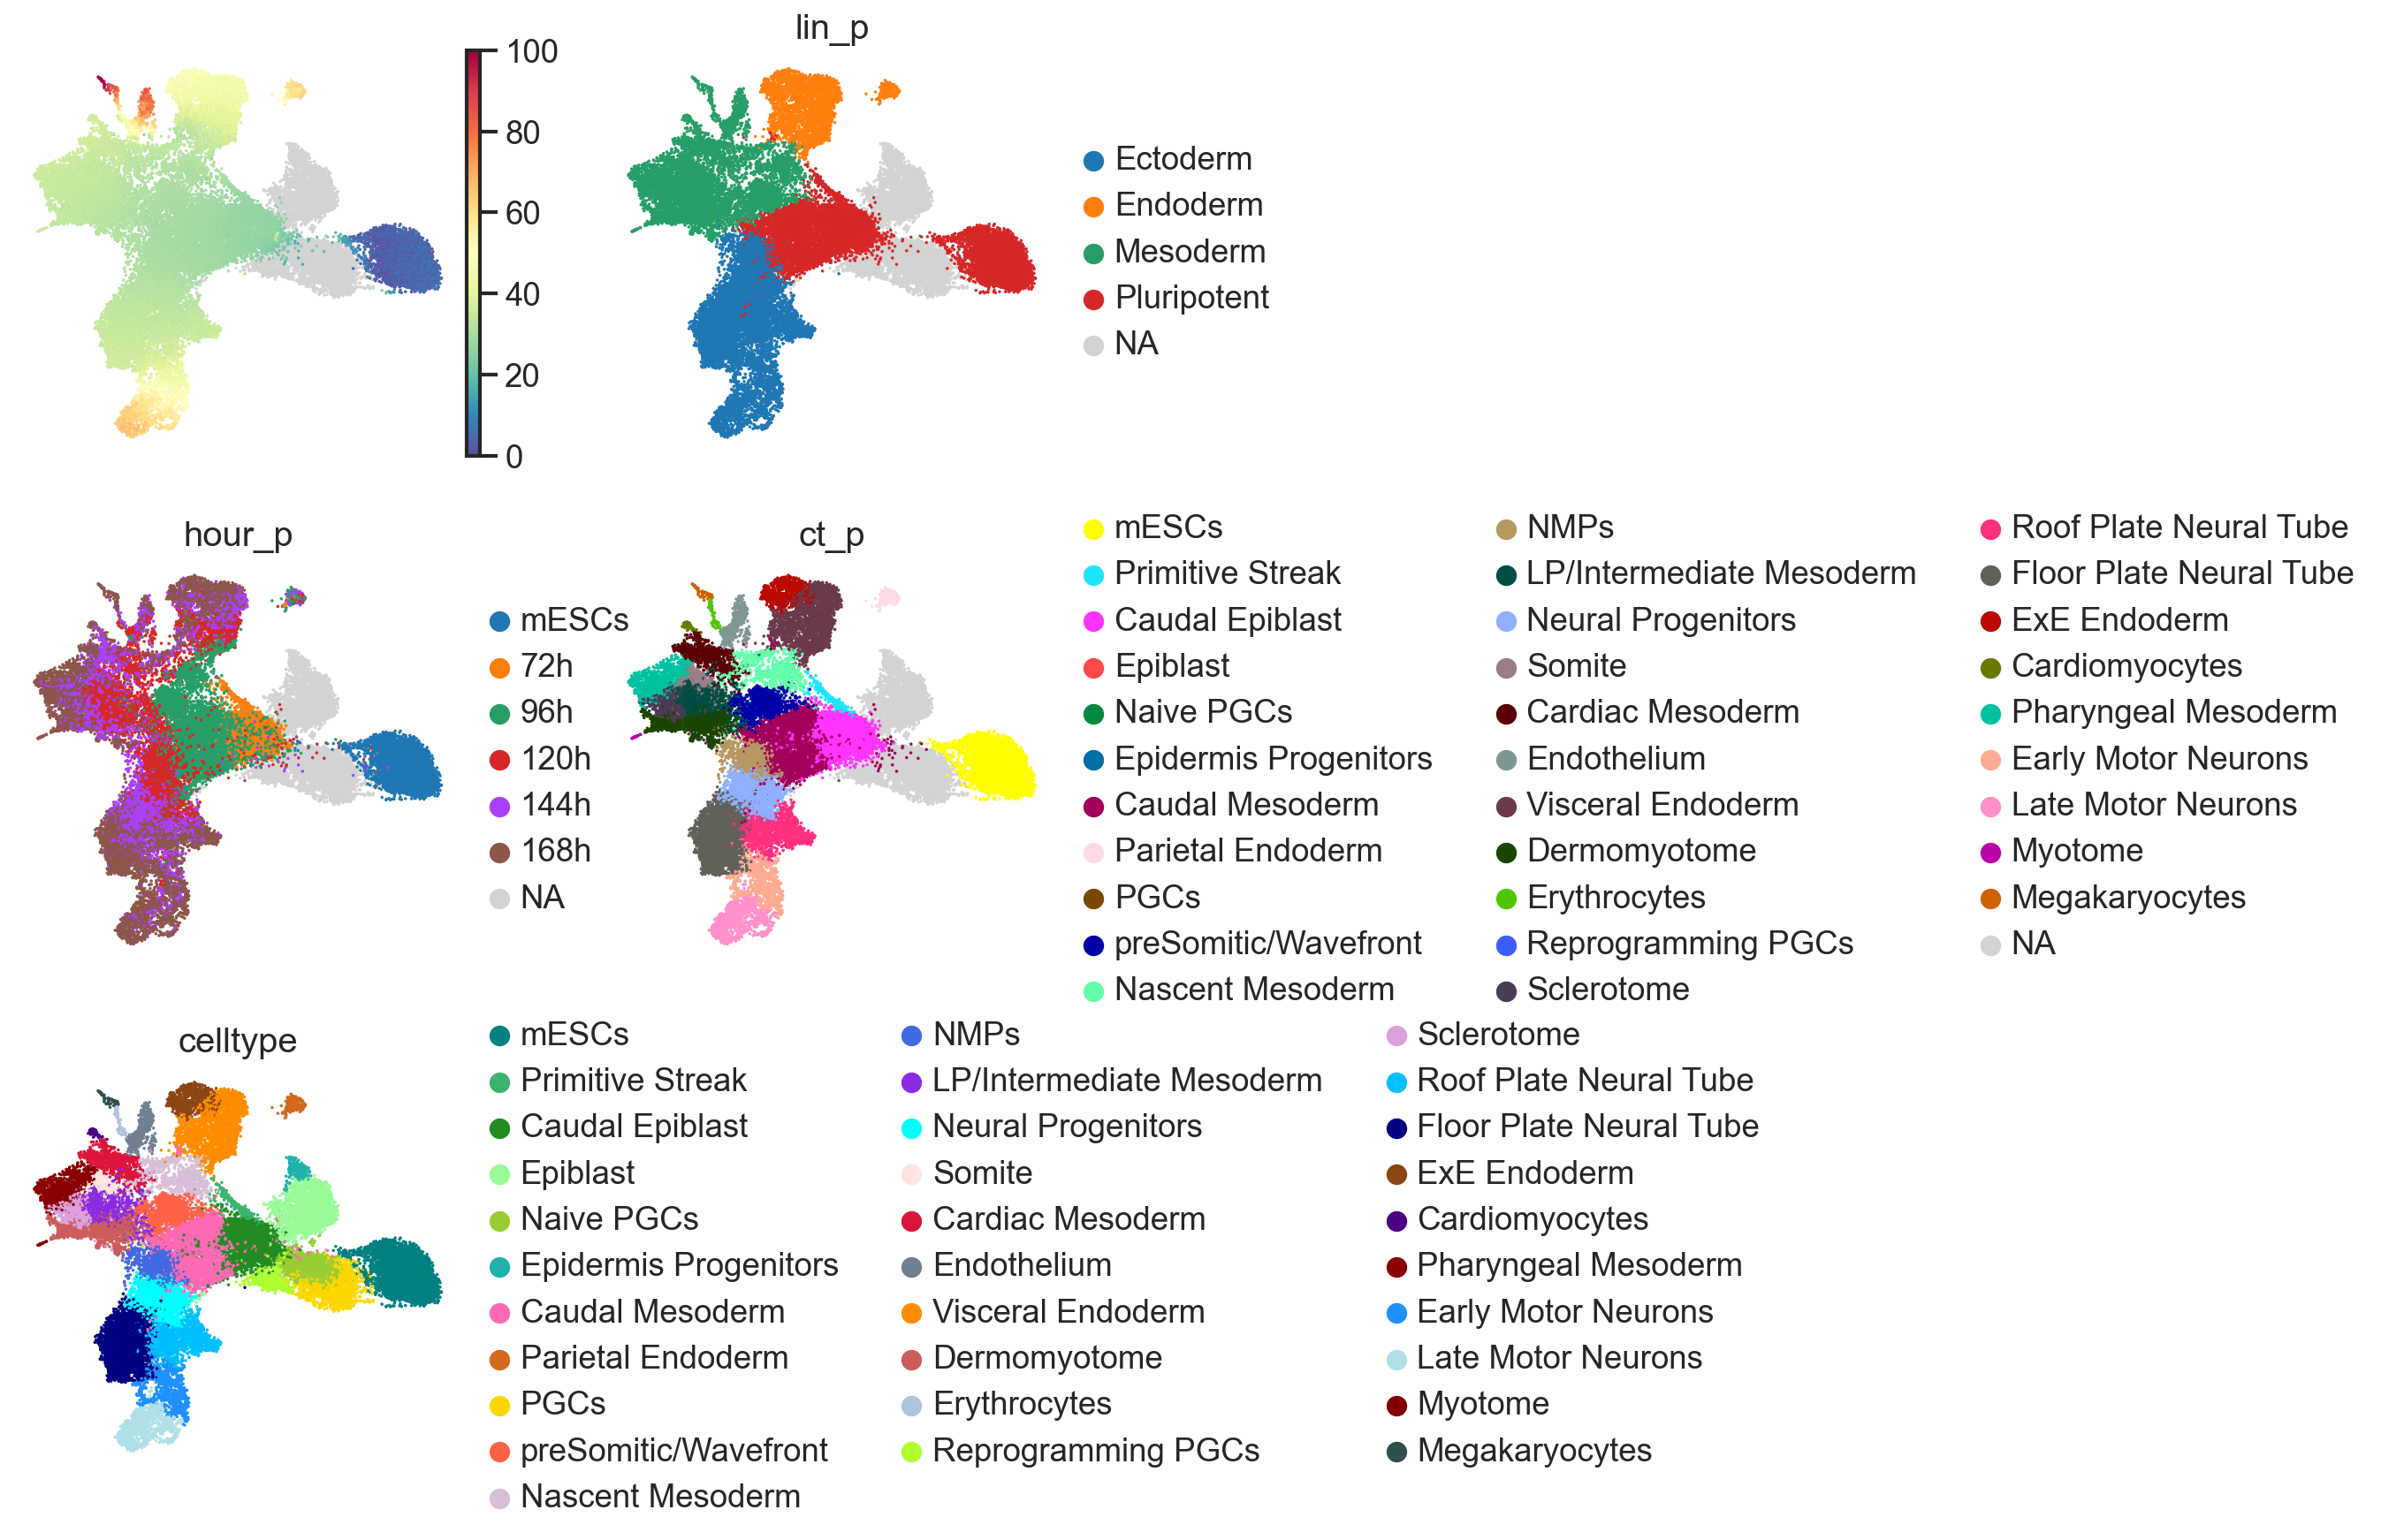

In [33]:
adata.obs['pseudo_p'] = adata.obs.loc[pseudo.index]['pseudotime']
adata.obs['lin_p'] = adata.obs.loc[pseudo.index]['lineage']
adata.obs['ct_p'] = adata.obs.loc[pseudo.index]['celltype']
adata.obs['hour_p'] = adata.obs.loc[pseudo.index]['hour']
sc.pl.umap(adata,color = ['pseudo_p','lin_p','hour_p','ct_p','celltype'], frameon = False, cmap = 'Spectral_r',size = 10, vmin = 0, vmax = 100, title = '', ncols=2)

In [34]:
common_barcodes = np.intersect1d(tss_k4.index,pseudo.index).astype(str)
df_k4 = tss_k4.loc[common_barcodes]


In [35]:
df_k4.shape

(14948, 525)

In [36]:
tss_k4.shape

(23562, 525)

In [37]:
df_k4['pseudo'] = pseudo['pseudotime']
df_k4['lineage'] = adata.obs['lineage']

In [38]:
df_k4 = df_k4[~df_k4['pseudo'].isna()]

In [39]:
df_k4 = df_k4.sort_values(by='pseudo')
df_k4.head(2)

gene                                Dlgap1                     Ank3            \
TSS                                      1    2    3    4    5    1    2    3   
cell                                                                            
PZ-MB-TChIC-mESCs-rep4-H3K4me3-3_22    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
PZ-MB-TChIC-mESCs-rep4-H3K4me3-5_51    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

gene                                           ... C2cd2           Rcan1       \
TSS                                    4    5  ...     3    4    5     1    2   
cell                                           ...                              
PZ-MB-TChIC-mESCs-rep4-H3K4me3-3_22  0.0  0.0  ...   0.0  0.0  0.0   0.0  0.0   
PZ-MB-TChIC-mESCs-rep4-H3K4me3-5_51  0.0  0.0  ...   0.0  0.0  0.0   1.0  0.0   

gene                                     Prickle1         pseudo      lineage  
TSS                                    3        1    2                         
cell                                                                           
PZ-MB-TChIC-mESCs-rep4-H3K4me3-3_22  0.0      0.0  0.0  0.083724  Pluripotent  
PZ-MB-TChIC-mESCs-rep4-H3K4me3-5_51  0.0      0.0  0.0  0.109738  Pluripotent  

[2 rows x 527 columns]

In [40]:
common_barcodes2 = np.intersect1d(tss_k27.index,pseudo.index).astype(str)
df_k27 = tss_k27.loc[common_barcodes2]
df_k27['pseudo'] = pseudo['pseudotime']
df_k27['lineage'] = adata.obs['lineage']

df_k27 = df_k27[~df_k27['pseudo'].isna()]
df_k27 = df_k27.sort_values(by='pseudo')
df_k27.head(2)

gene                                  Dlgap1                     Ank3       \
TSS                                        1    2    3    4    5    1    2   
cell                                                                         
PZ-MB-TChIC-mESCs-rep4-H3K27me3-1_12     0.0  0.0  0.0  0.0  0.0  0.0  0.0   
PZ-MB-TChIC-mESCs-rep4-H3K27me3-2_144    0.0  0.0  0.0  1.0  0.0  0.0  0.0   

gene                                                  ... C2cd2            \
TSS                                      3    4    5  ...     3    4    5   
cell                                                  ...                   
PZ-MB-TChIC-mESCs-rep4-H3K27me3-1_12   0.0  0.0  0.0  ...   0.0  0.0  0.0   
PZ-MB-TChIC-mESCs-rep4-H3K27me3-2_144  0.0  0.0  0.0  ...   1.0  0.0  1.0   

gene                                  Rcan1           Prickle1         pseudo  \
TSS                                       1    2    3        1    2             
cell                                                                            
PZ-MB-TChIC-mESCs-rep4-H3K27me3-1_12    0.0  0.0  0.0      0.0  0.0  0.000000   
PZ-MB-TChIC-mESCs-rep4-H3K27me3-2_144   0.0  0.0  0.0      0.0  0.0  0.045098   

gene                                       lineage  
TSS                                                 
cell                                                
PZ-MB-TChIC-mESCs-rep4-H3K27me3-1_12   Pluripotent  
PZ-MB-TChIC-mESCs-rep4-H3K27me3-2_144  Pluripotent  

[2 rows x 527 columns]

In [41]:
common_barcodes3 = np.intersect1d(tss_rna.index,pseudo.index).astype(str)
df_rna = tss_rna.loc[common_barcodes3]
df_rna['pseudo'] = pseudo['pseudotime']
df_rna['lineage'] = adata.obs['lineage']

df_rna = df_rna[~df_rna['pseudo'].isna()]
df_rna = df_rna.sort_values(by='pseudo')
df_rna.head(2)

gene                                  Dlgap1             Ank3              \
TSS                                        1  2  3  4  5    1  2  3  4  5   
PZ-MB-TChIC-mESCs-rep4-H3K27me3-1_12       0  0  0  0  0    0  0  0  0  0   
PZ-MB-TChIC-mESCs-rep4-H3K27me3-2_144      0  0  0  0  0    0  0  0  0  0   

gene                                   ... C2cd2       Rcan1       Prickle1  \
TSS                                    ...     3  4  5     1  2  3        1   
PZ-MB-TChIC-mESCs-rep4-H3K27me3-1_12   ...     0  0  0     0  0  0        0   
PZ-MB-TChIC-mESCs-rep4-H3K27me3-2_144  ...     0  0  0     0  0  0        0   

gene                                        pseudo      lineage  
TSS                                    2                         
PZ-MB-TChIC-mESCs-rep4-H3K27me3-1_12   0  0.000000  Pluripotent  
PZ-MB-TChIC-mESCs-rep4-H3K27me3-2_144  0  0.045098  Pluripotent  

[2 rows x 527 columns]

## make heatmaps

In [42]:
import warnings
warnings.filterwarnings('ignore')

In [43]:
def makeHeatmap(df, lineage, threshold = 300, steps = 100, aspect_ratio=2, palette = greens_r, vmax = 1):
    df_p = df[(df['lineage'] == 'Pluripotent') | (df['lineage'] == lineage)]
    df_p = df_p.drop(['pseudo','lineage'],axis=1)
    sns.histplot(df_p.sum(axis=0), color = 'cornflowerblue')
    
    plt.axvline(threshold, color = 'black')
    plt.show()
    
    df_p = df_p.loc[:,df_p.sum(axis=0) > threshold]
    df_p[['hour','pseudotime']] = adata.obs[['celltype','pseudotime']]
    b_pseudo, b, b_sum = bintable(df_p, steps)
    
    for gene in df_p.T.reset_index()['gene'].value_counts().sort_values(ascending=False)[0:10].index:
        
        fig,axes = plt.subplots(2,1,figsize = (df_p[gene].shape[0]*0.0005*aspect_ratio,df_p[gene].shape[1]/aspect_ratio), 
                                gridspec_kw={'hspace': 0.1, 'height_ratios':[4*df_p[gene].shape[1], 2]})
        
        axes = axes.flatten()
        ax = sns.heatmap(b[gene].T,ax=axes[0], cmap = palette,cbar = False, vmax=vmax)
        
        lineage_cols = str('celltype') + '_colors'
        lin_dict = dict(zip(list(adata.obs['celltype'].cat.categories),
                            adata.uns[lineage_cols]))

        axes[1].imshow(pd.DataFrame(pd.factorize(b_pseudo['celltype'])[0]).T, interpolation='none', aspect='auto', 
                               cmap=LinearSegmentedColormap.from_list('cmap_celltypes', 
                                                              list( map(lin_dict.get, list(b_pseudo['celltype'].unique()))), 
                                                              N=len(list( map(lin_dict.get, list(b_pseudo['celltype'].unique()))))))

        axes[0].tick_params(labelbottom=False, bottom=False)
        axes[0].tick_params(labelleft=False, left=False)
        axes[0].set(title=gene)
        axes[1].tick_params(labelbottom=False, bottom=False)
        axes[1].tick_params(labelleft=False, left=False)
        axes[1].set(xlabel='',
               ylabel='ct',
               title='')

        
        
        
        
        plt.xlabel('pseudotime')
        plt.show()

    

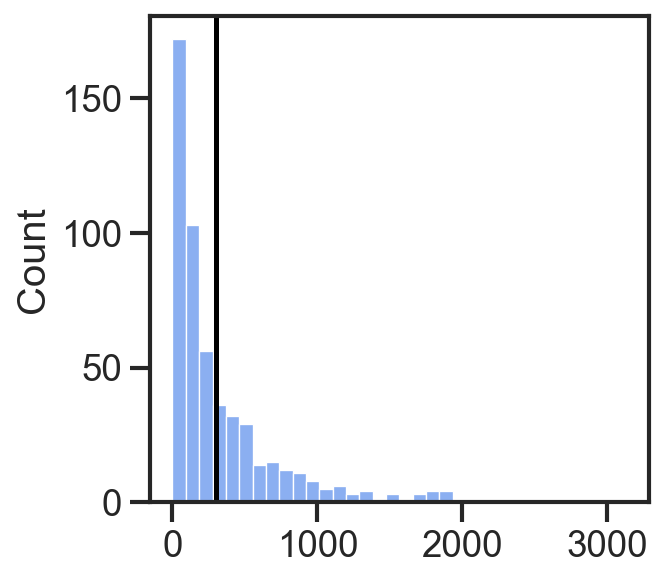

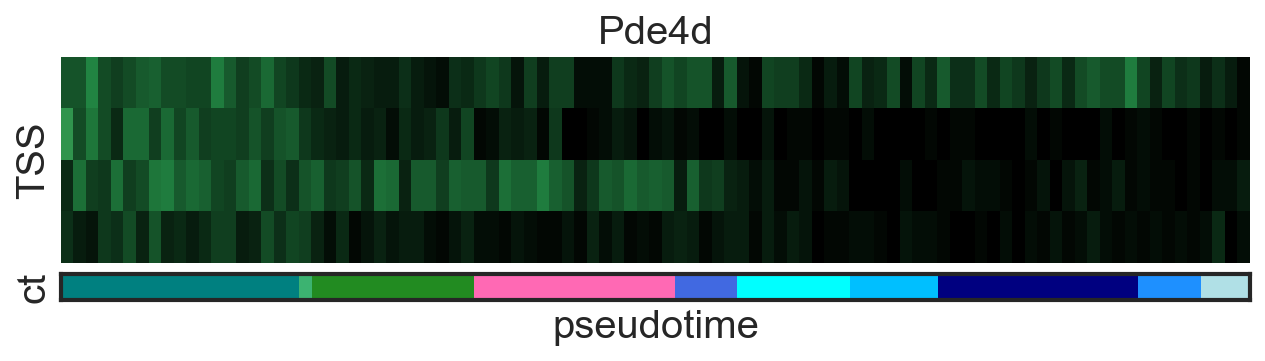

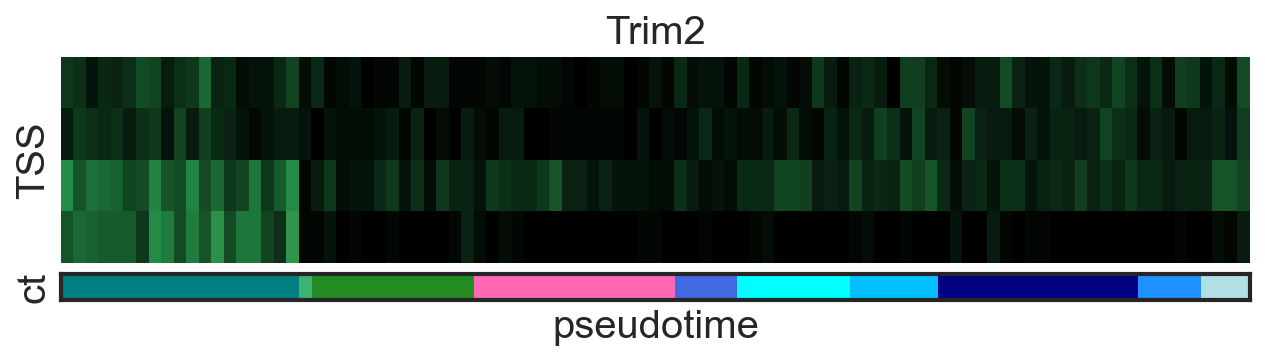

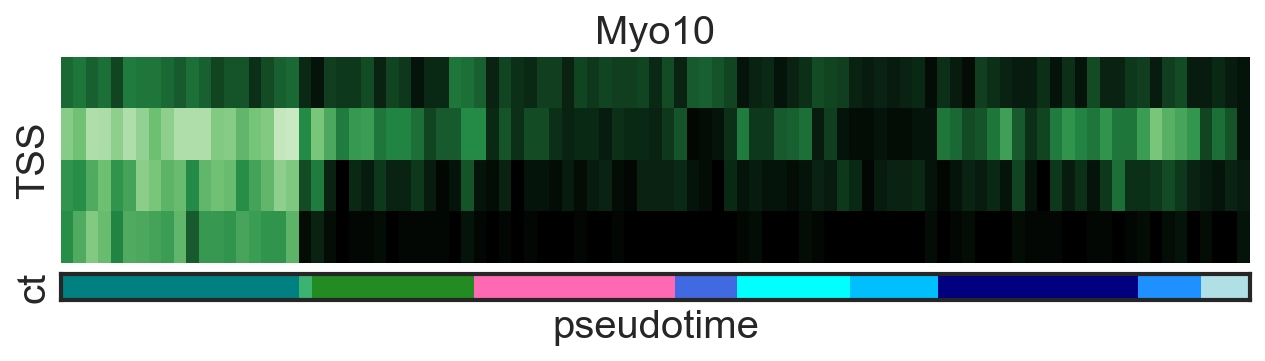

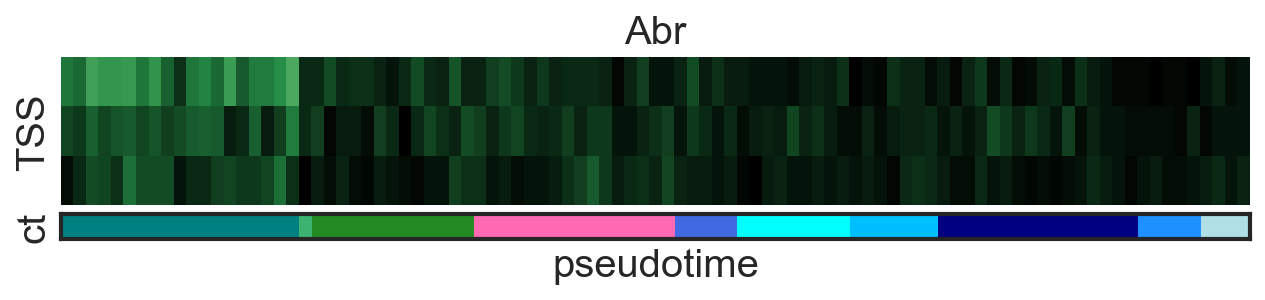

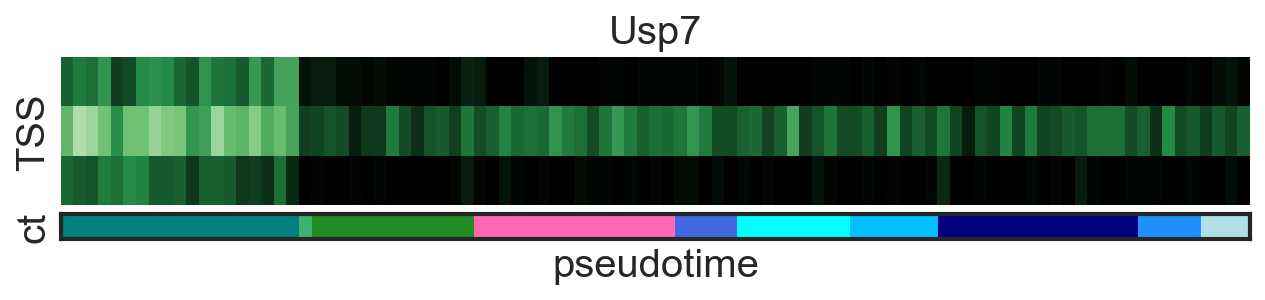

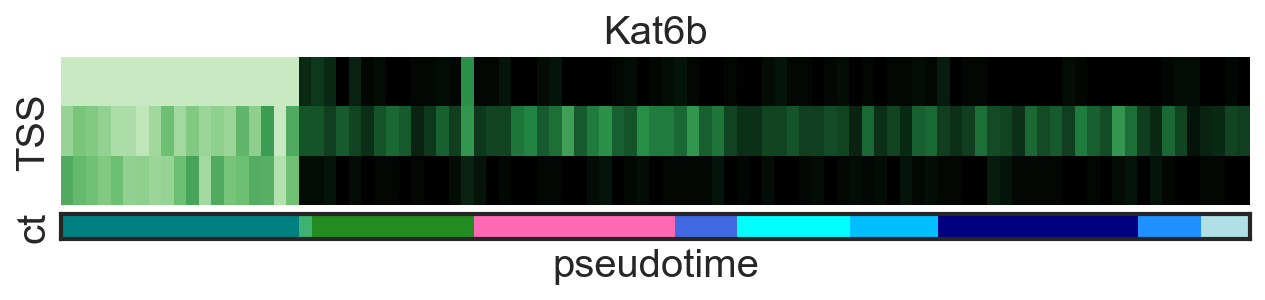

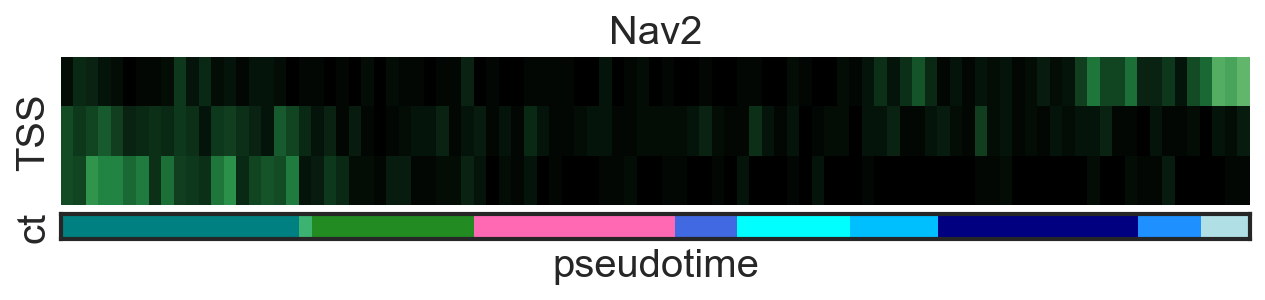

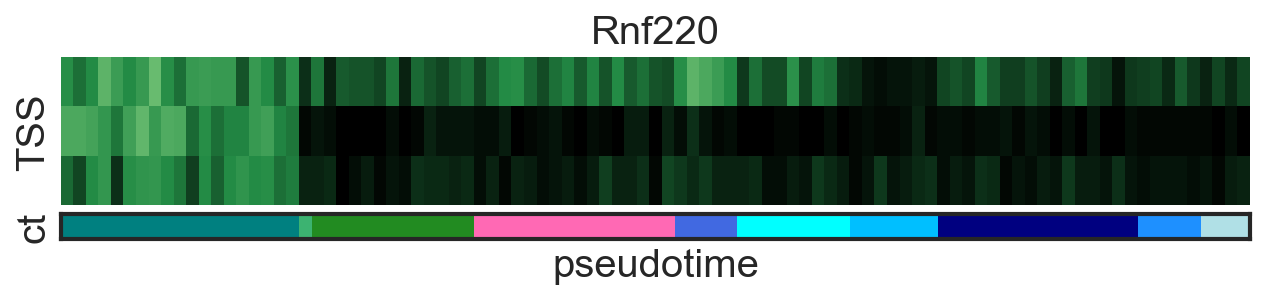

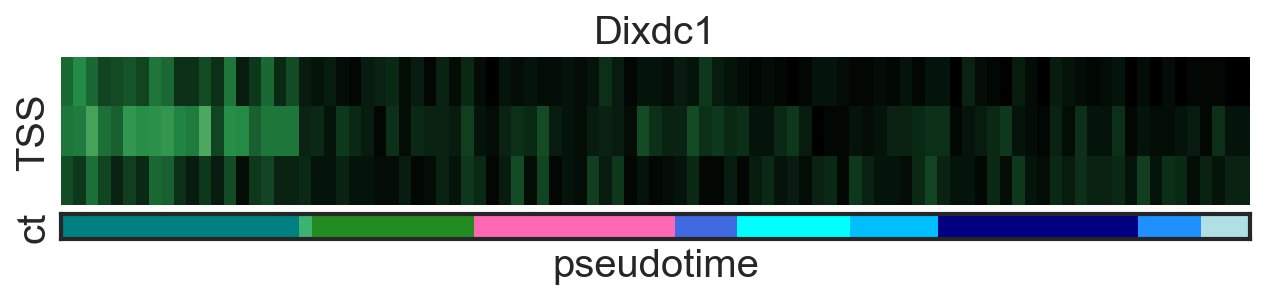

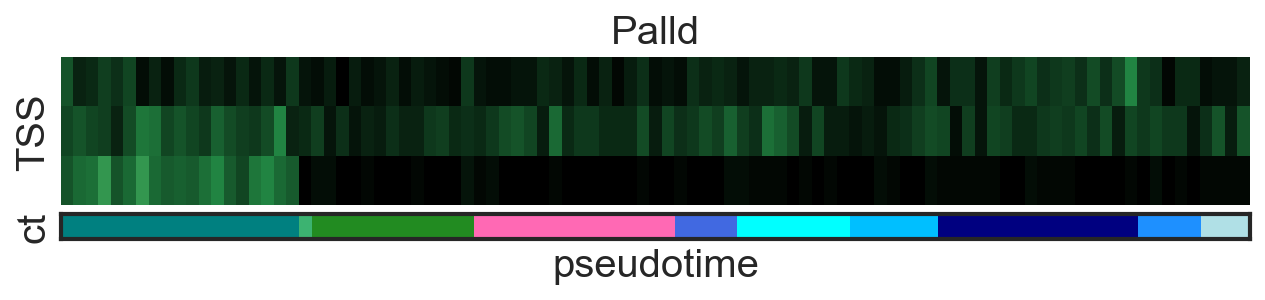

In [44]:
makeHeatmap(df_k4, 'Ectoderm', vmax = 0.6)

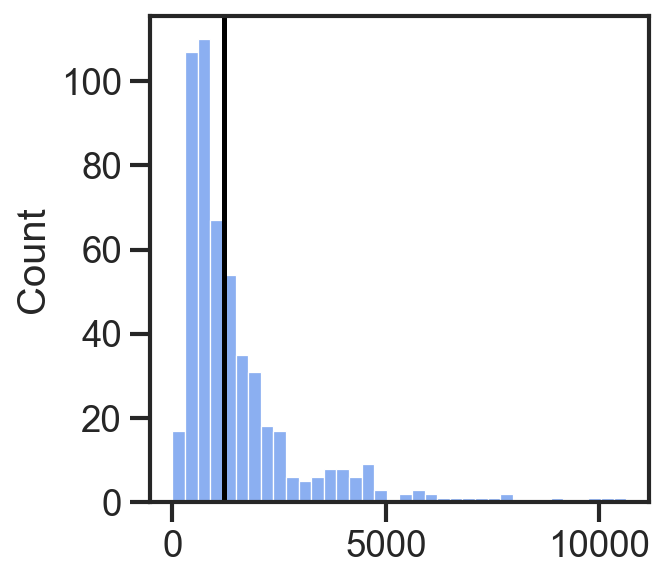

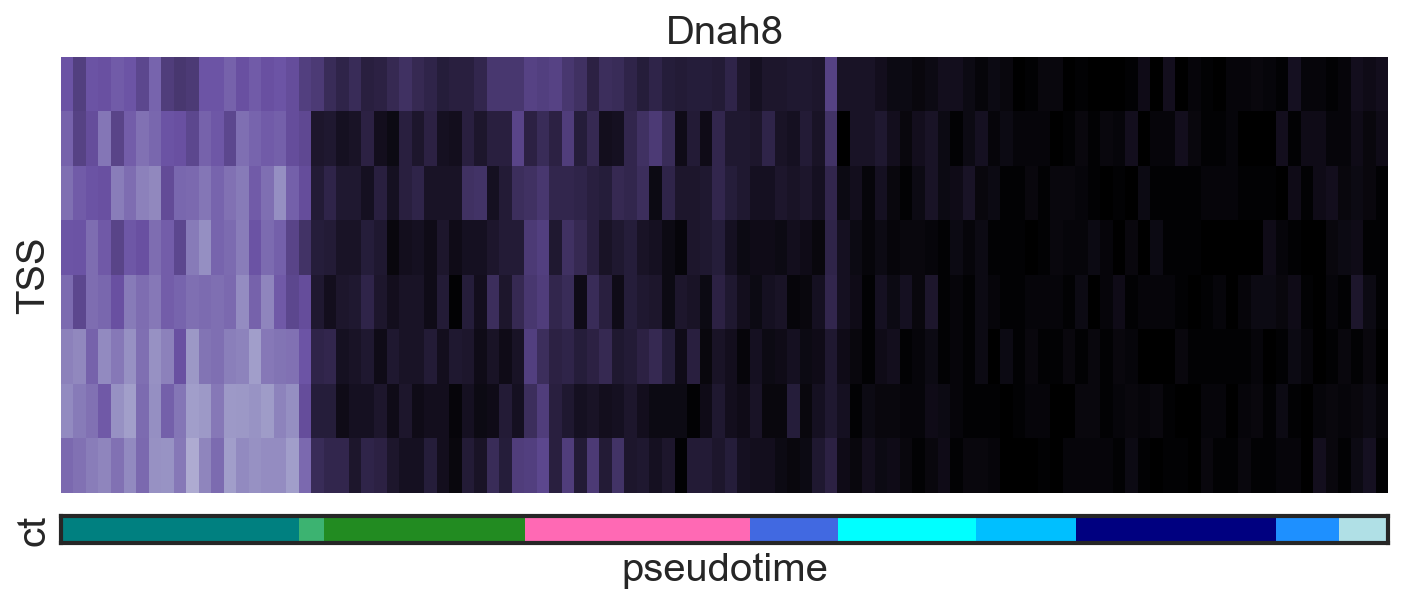

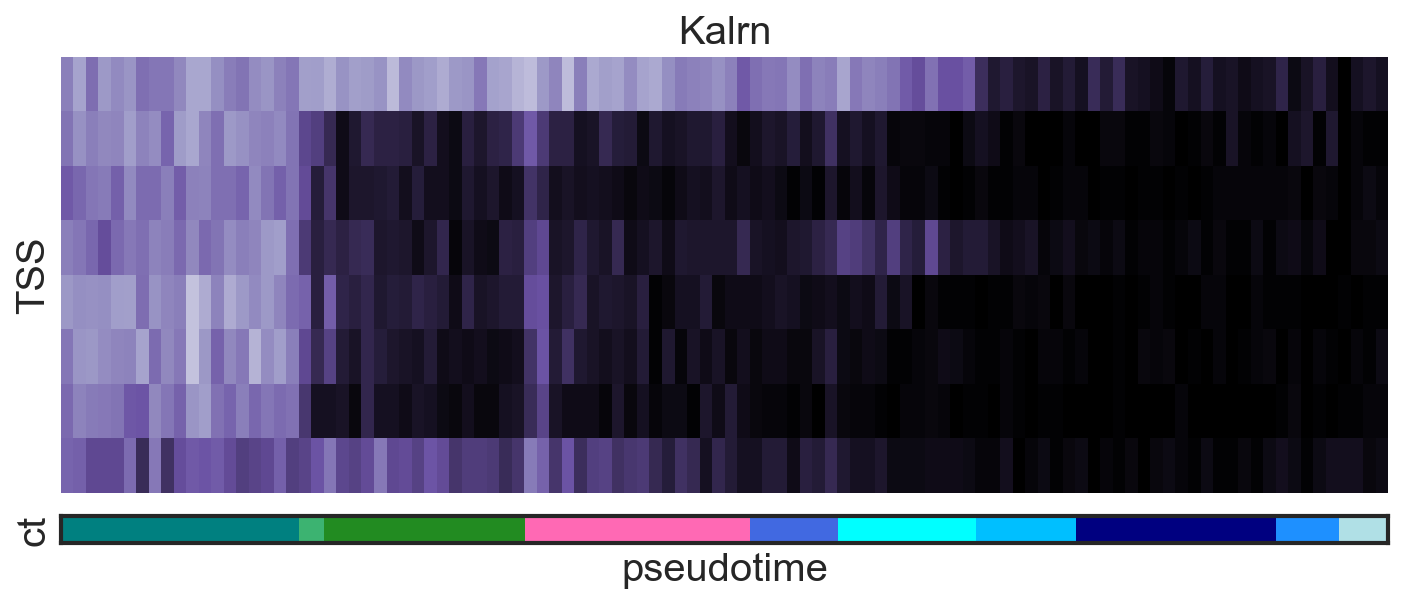

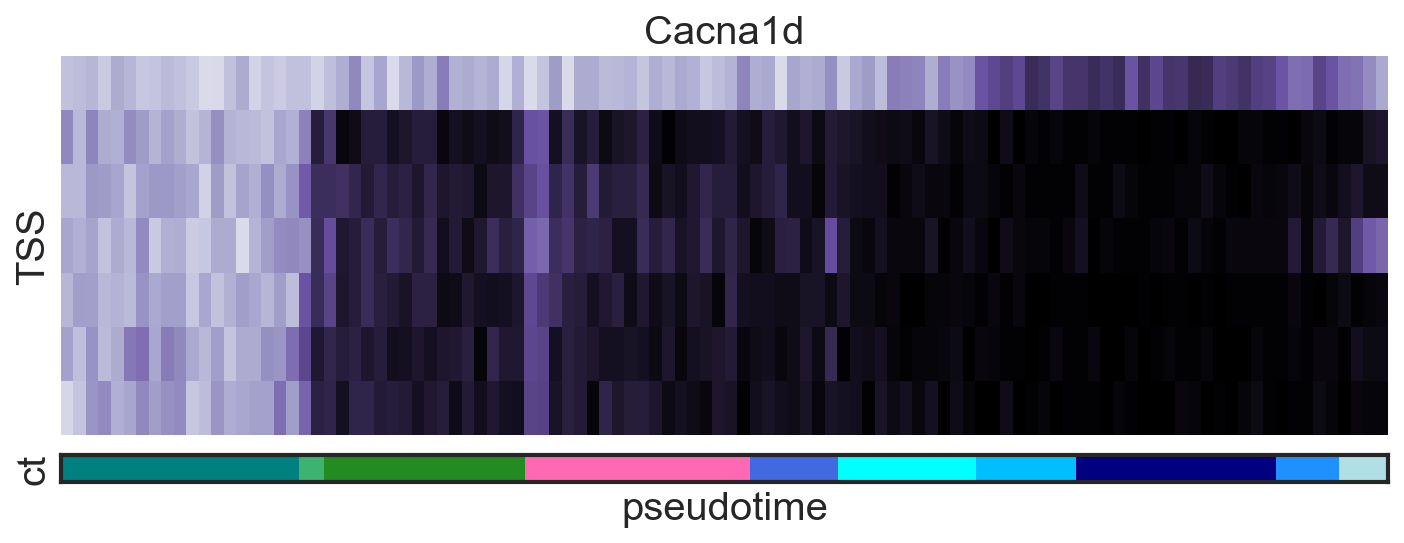

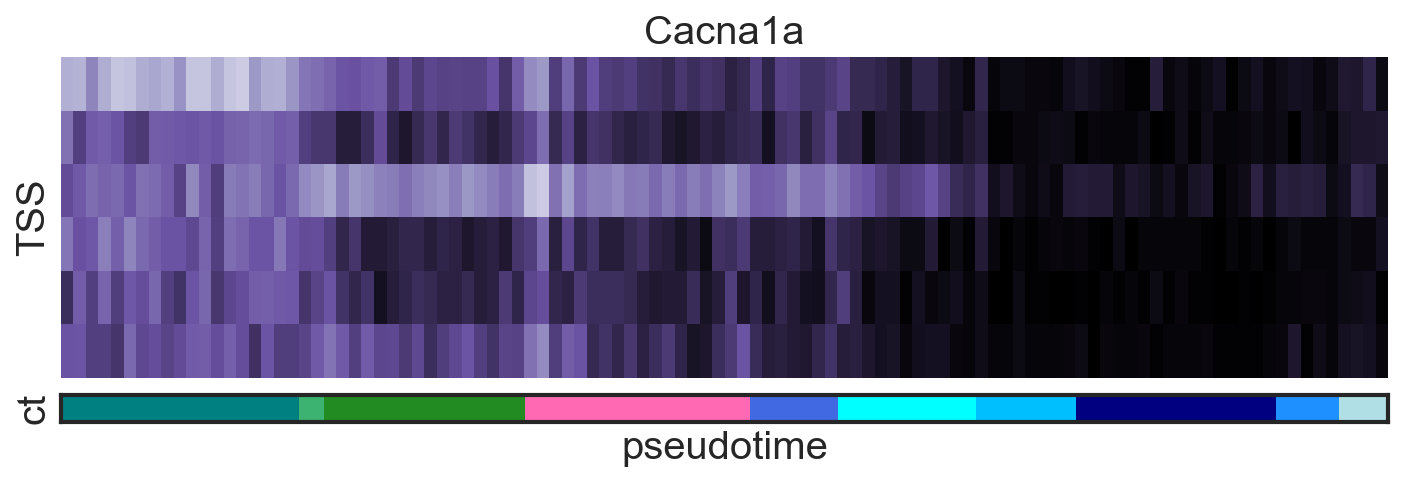

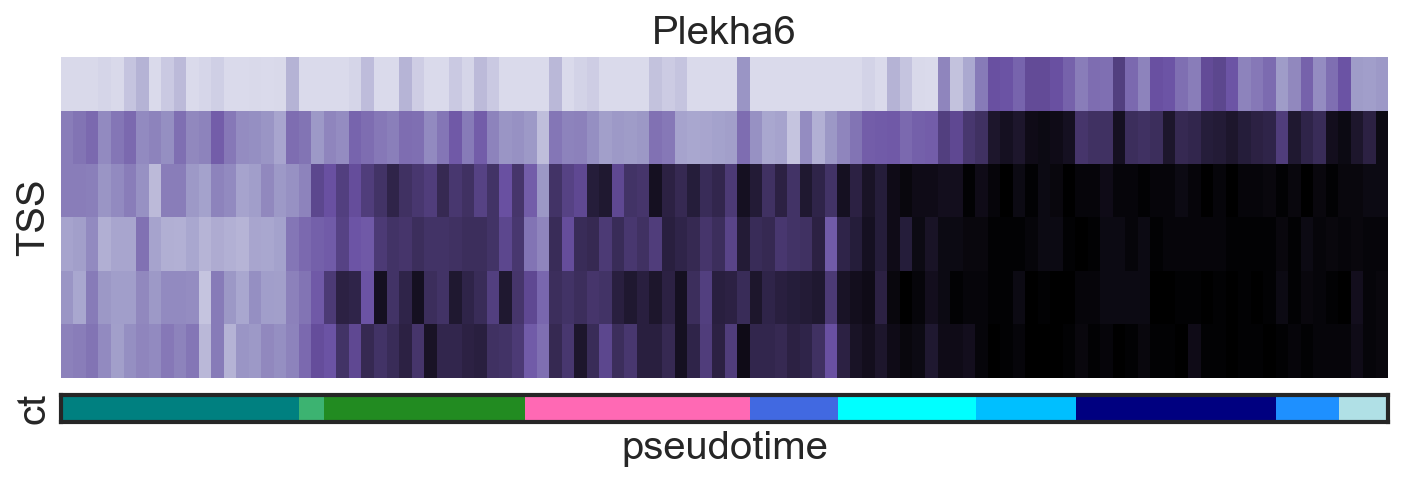

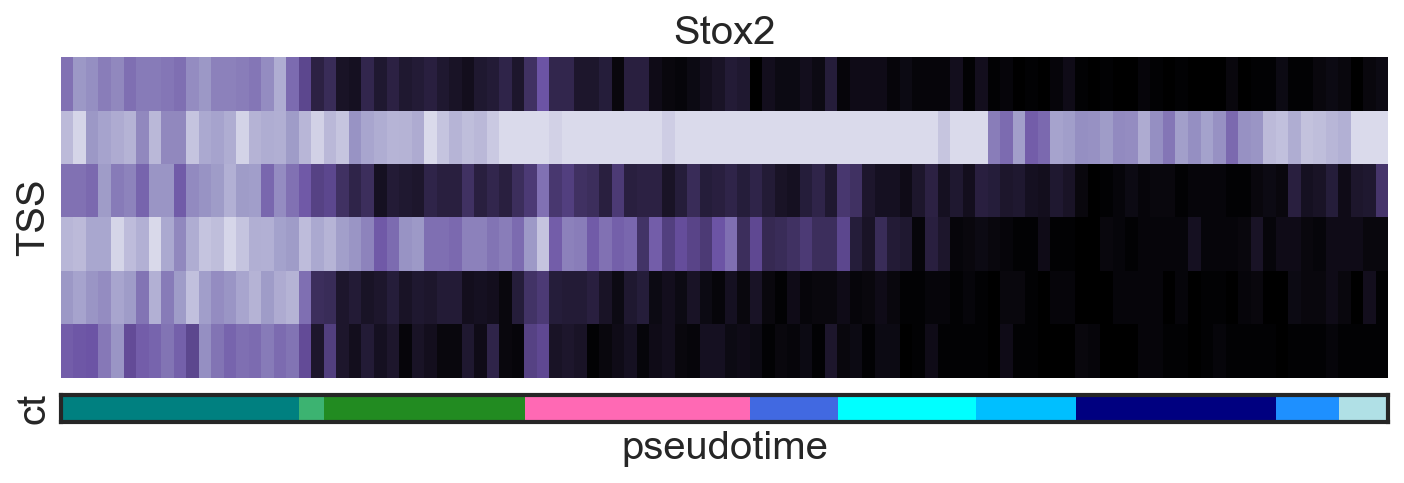

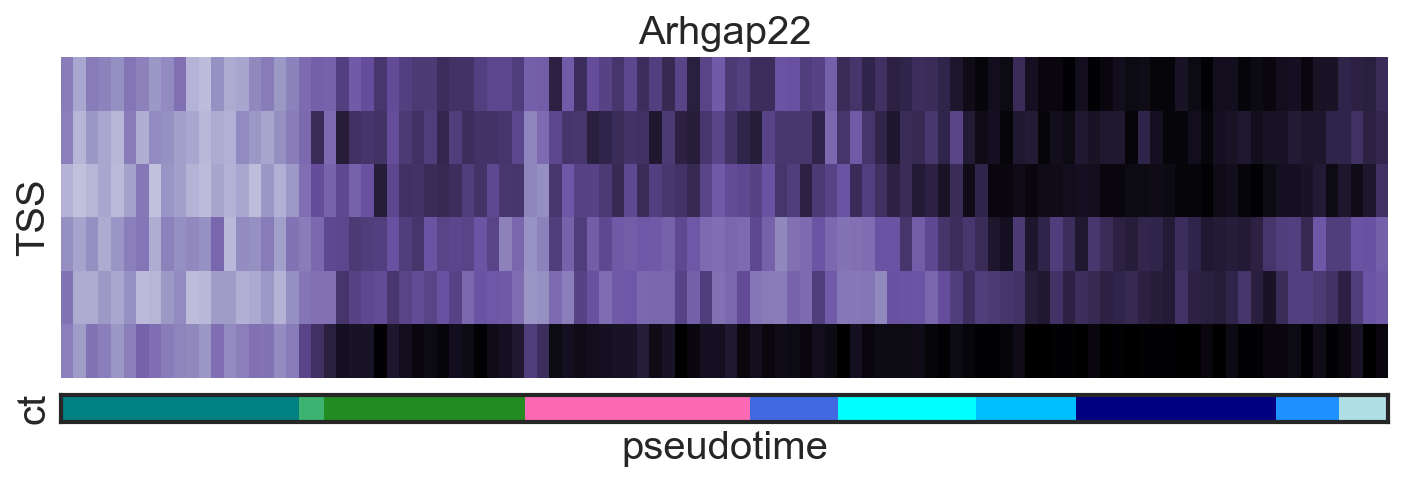

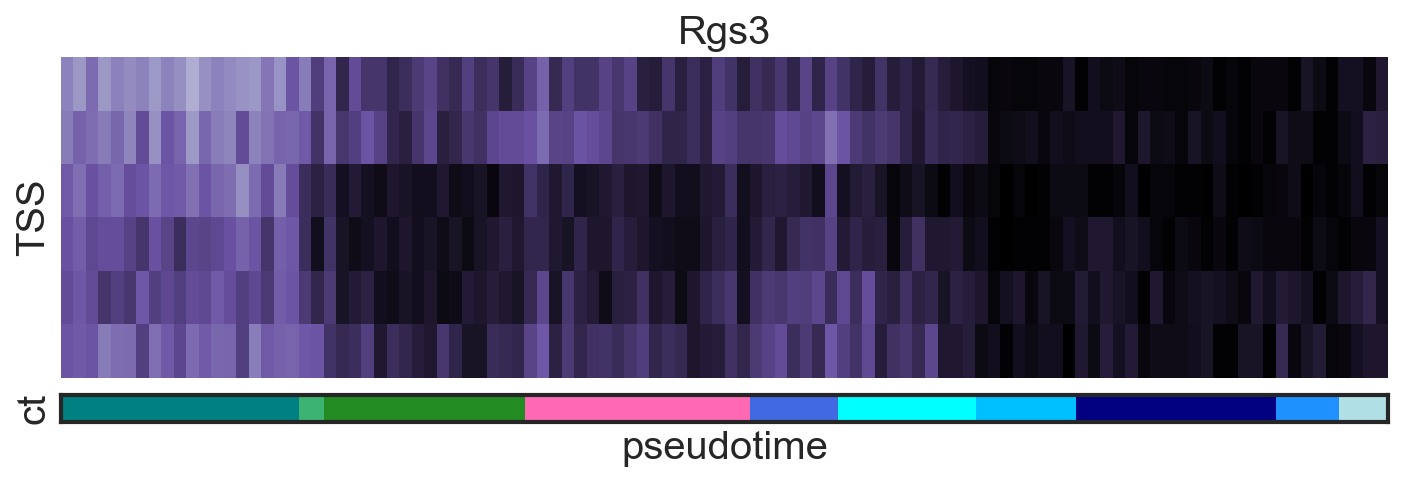

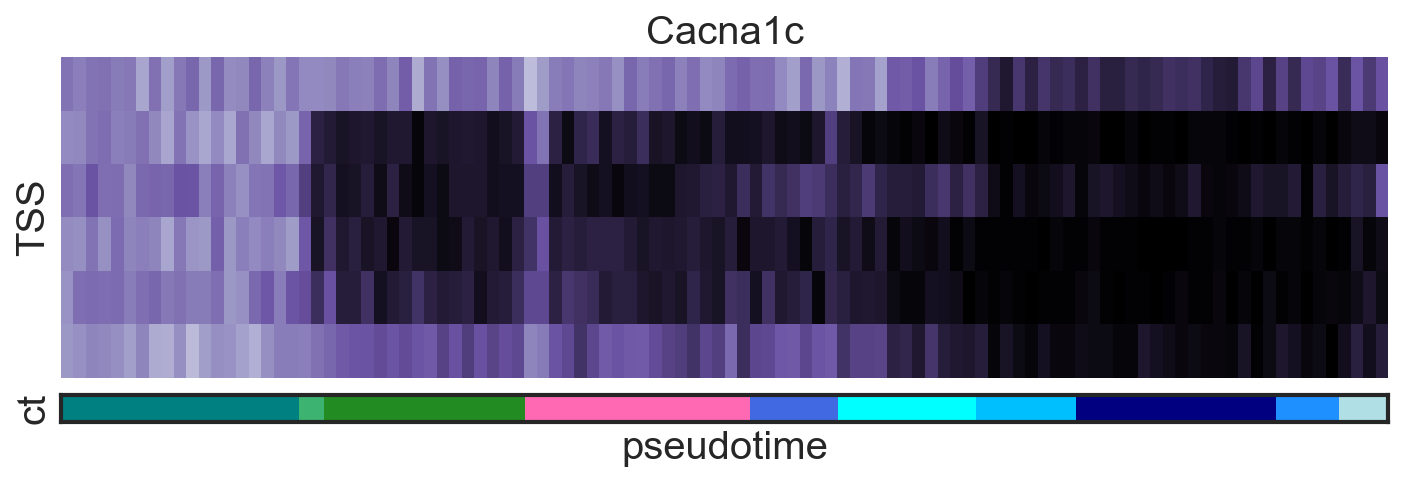

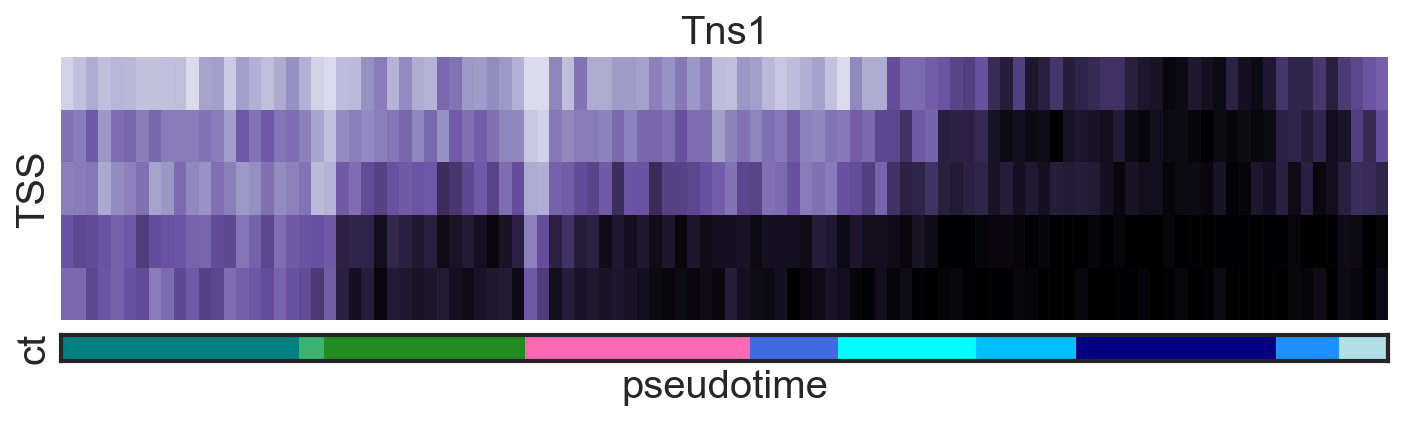

In [45]:
makeHeatmap(df_k27, 'Ectoderm', palette = purples_r, threshold = 1200, vmax = 1)

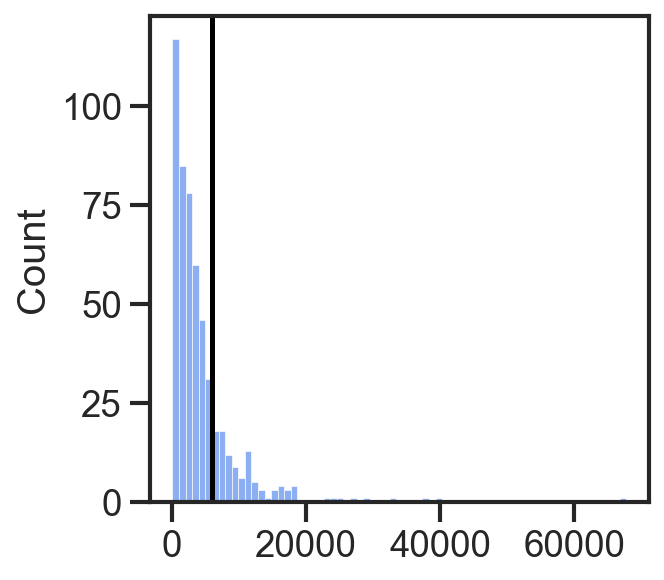

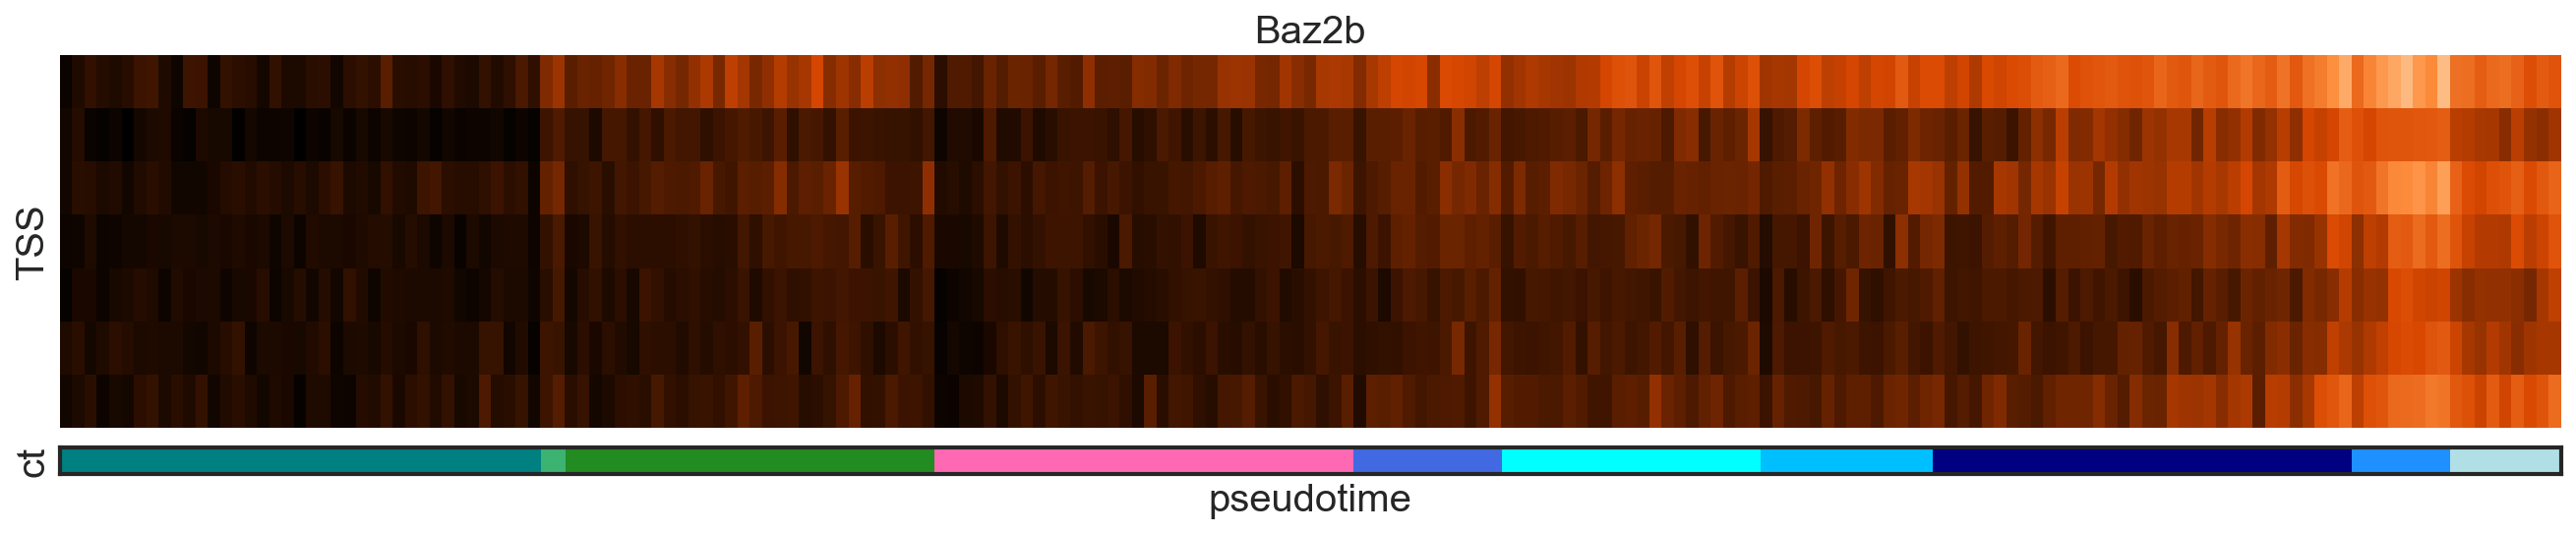

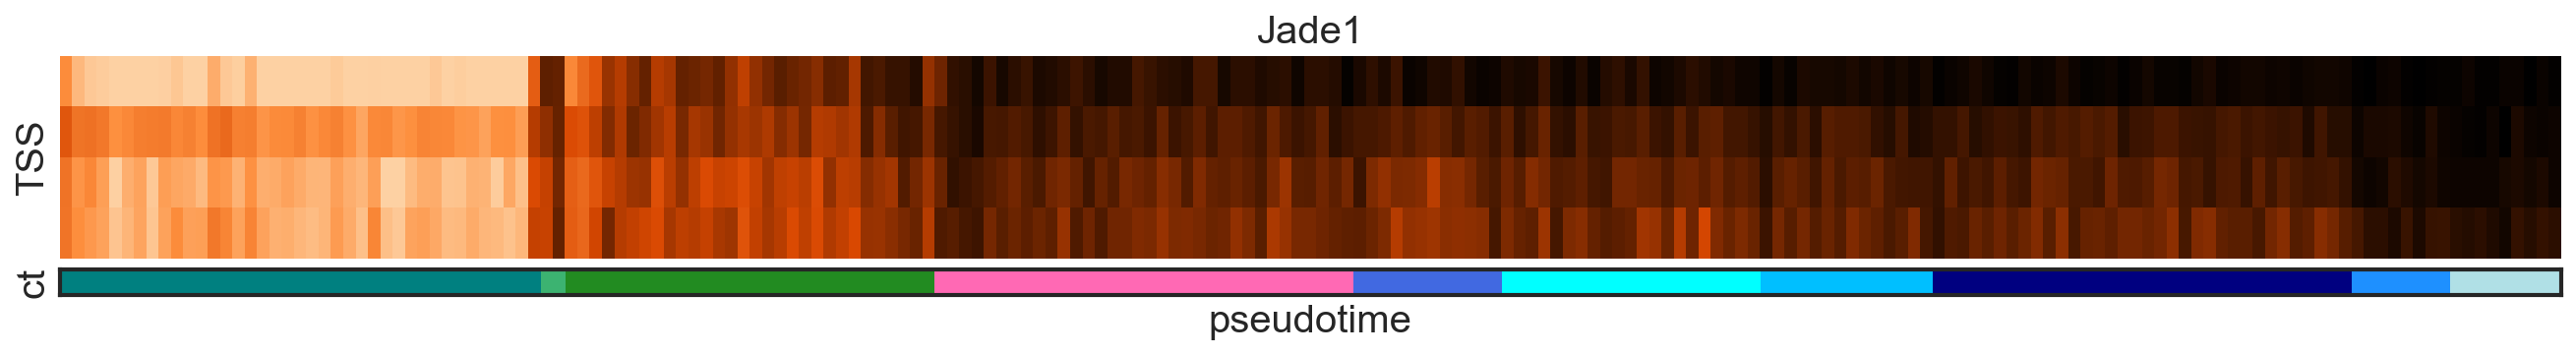

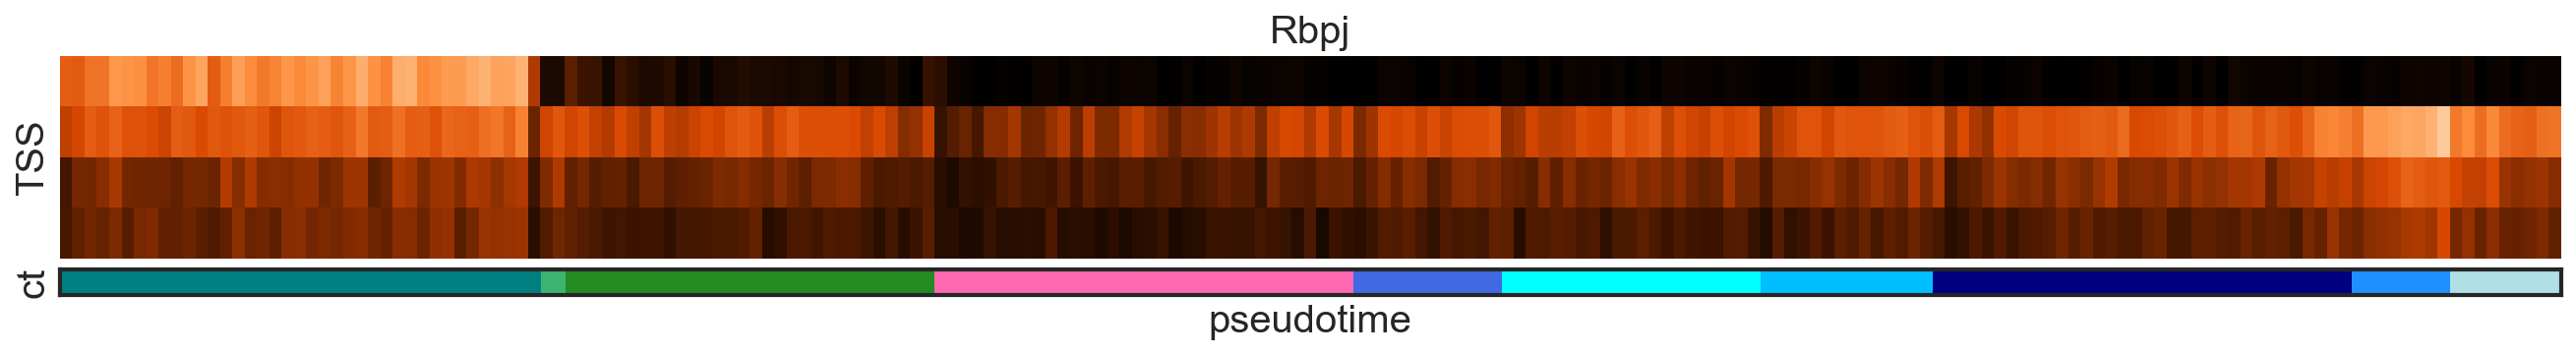

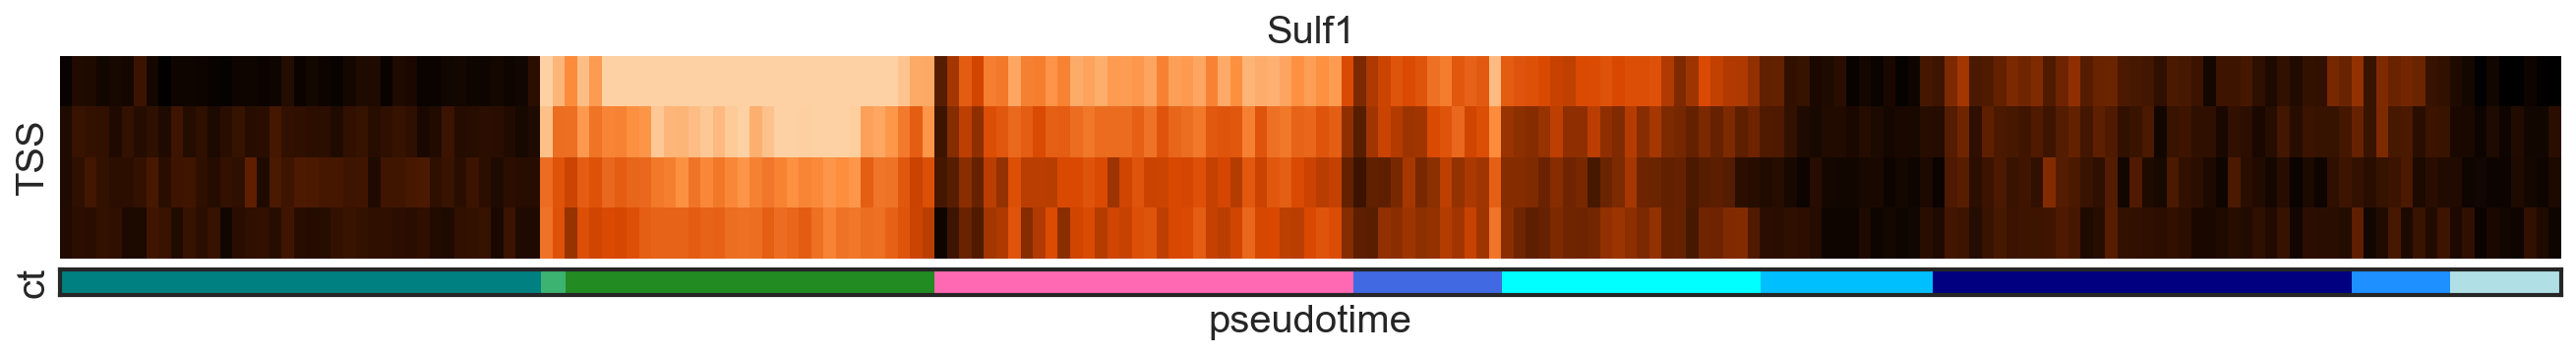

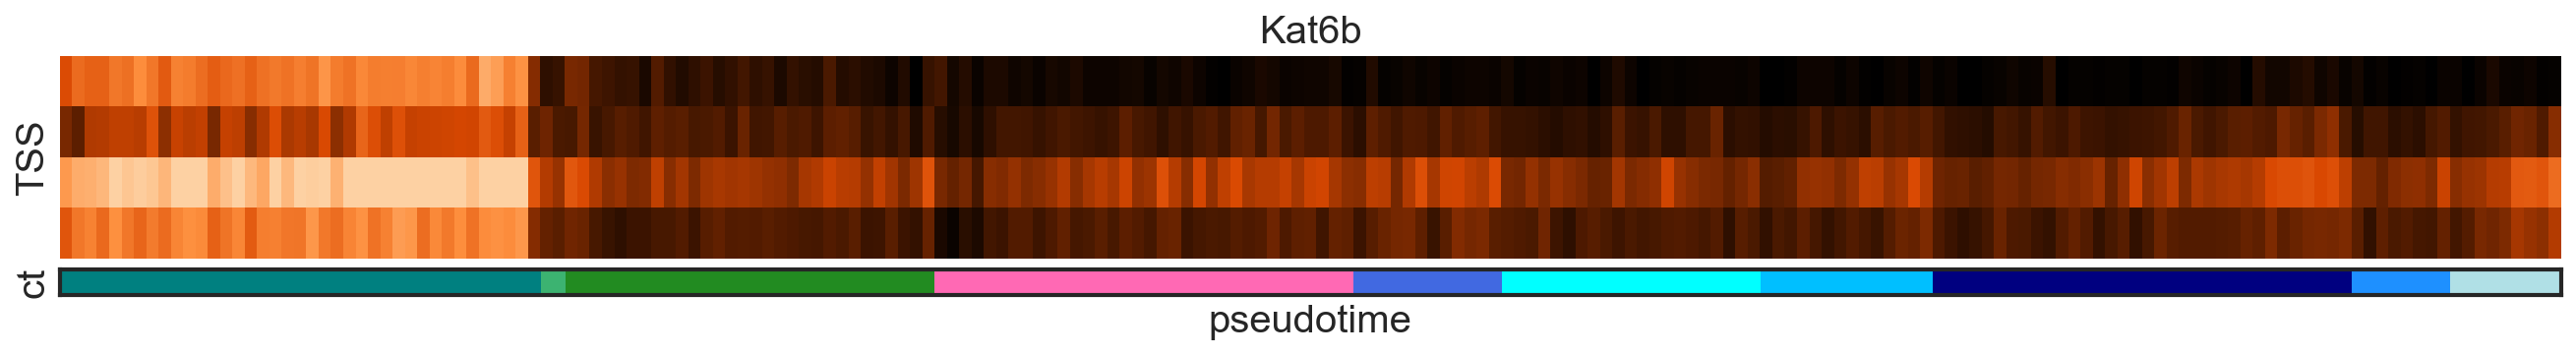

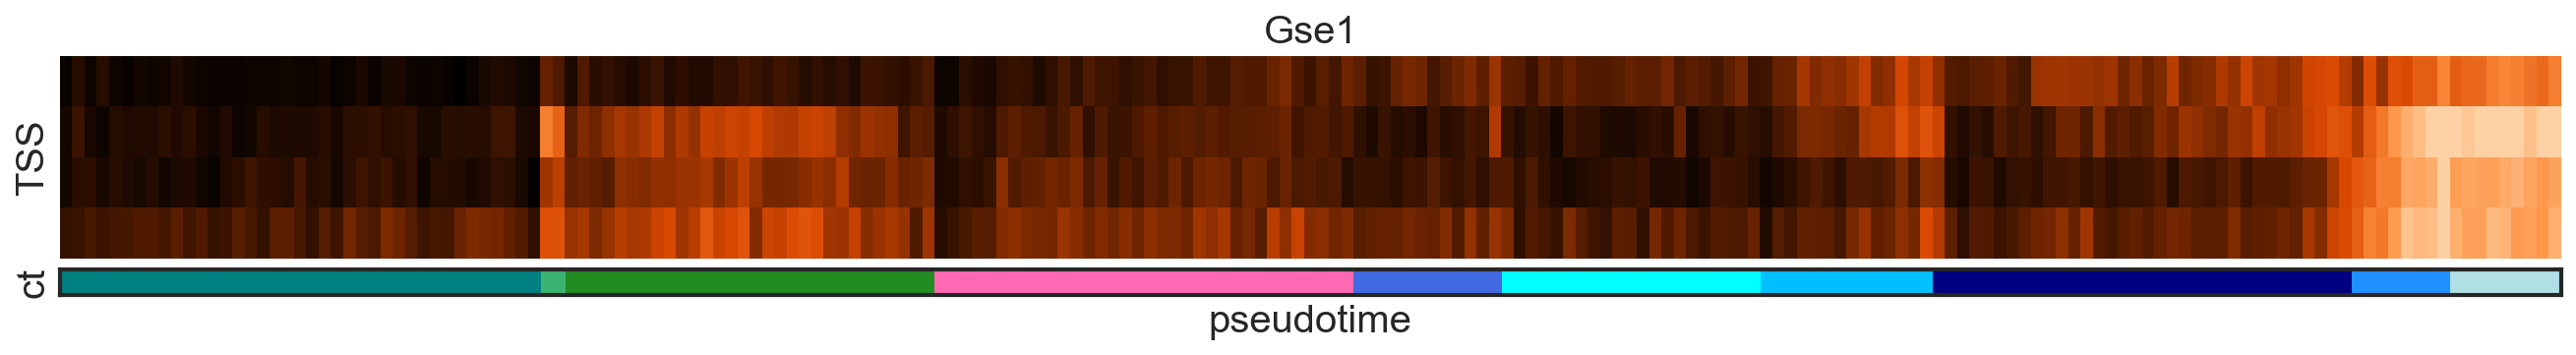

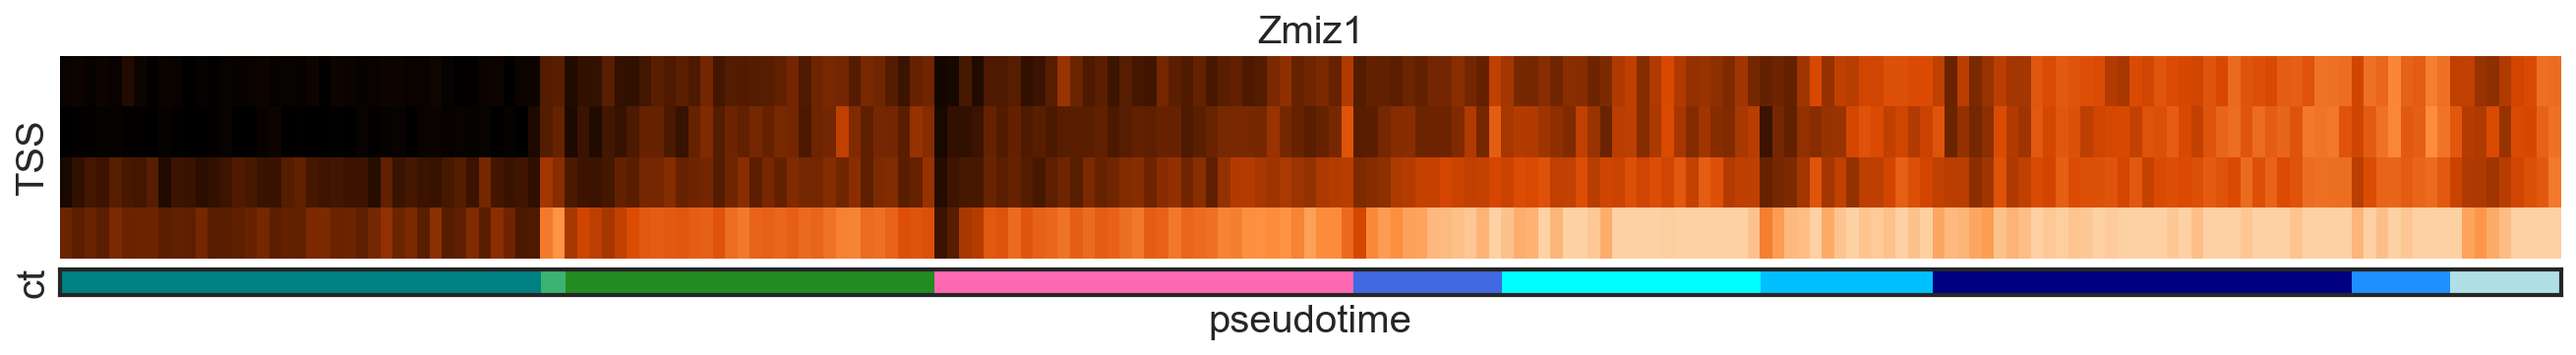

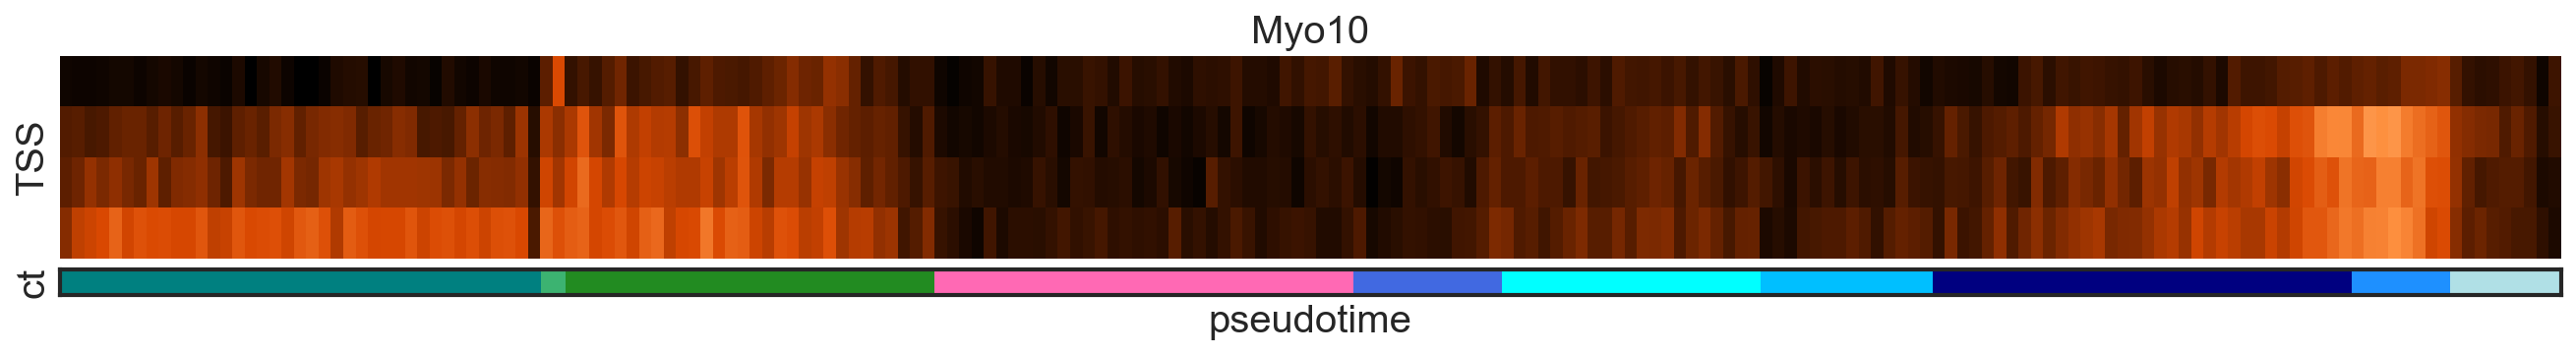

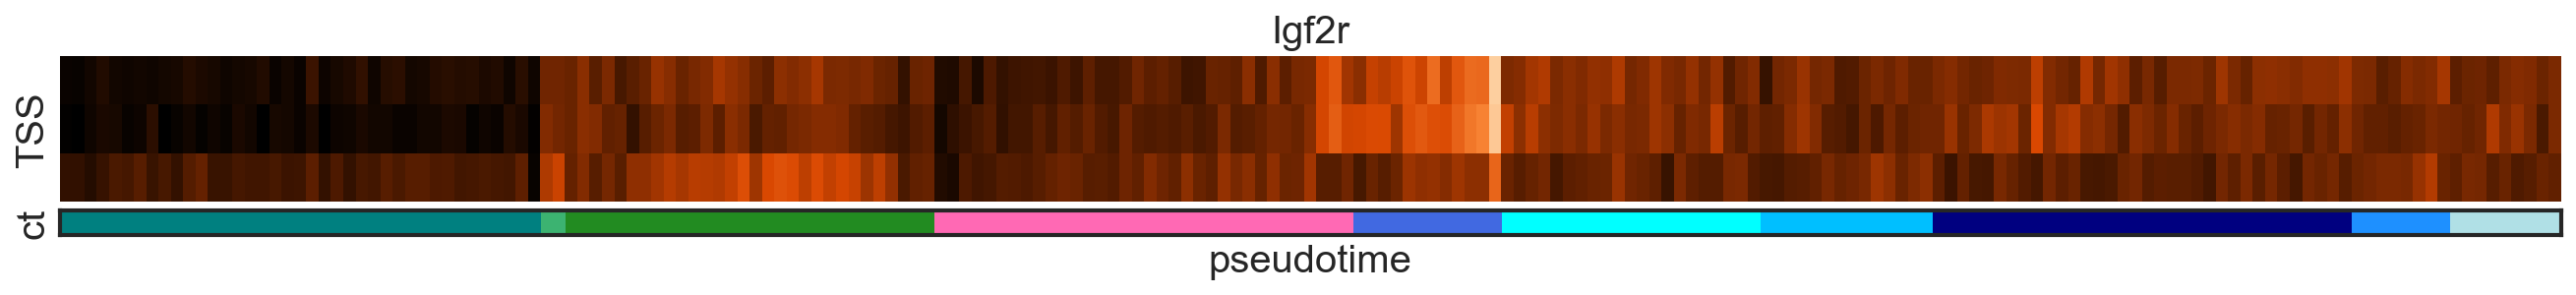

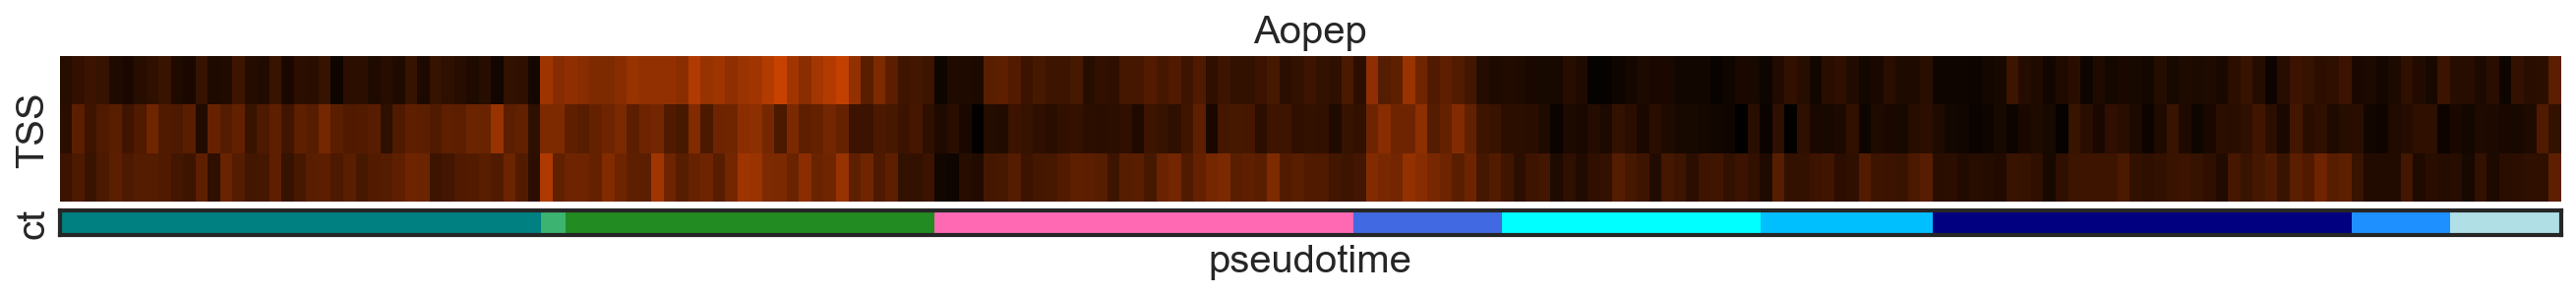

In [46]:
makeHeatmap(df_rna, 'Ectoderm',  palette = oranges_r, threshold = 6000, vmax = 3)

In [47]:
def makeHeatmap(df, lineage, genelist, filtering = True, threshold = 300, steps = 100, 
                aspect_ratio=2, palette = greens_r, vmax = 1):
    df_p = df[(df['lineage'] == 'Pluripotent') | (df['lineage'] == lineage)]
    df_p = df_p.drop(['pseudo','lineage'],axis=1)
    
    if filtering == True:
        sns.histplot(df_p.sum(axis=0), color = 'cornflowerblue')
        plt.axvline(threshold, color = 'black')
        plt.show()
    
    if filtering == True:
        df_p = df_p.loc[:,df_p.sum(axis=0) > threshold]
        
    df_p[['hour','pseudotime']] = adata.obs[['celltype','pseudotime']]
    b_pseudo, b, b_sum = bintable(df_p, steps)
    
    for gene in genelist:
        
        fig,axes = plt.subplots(2,1,figsize = (9,#b[gene].shape[0]*0.05*aspect_ratio,
                                               b[gene].shape[1]/aspect_ratio), 
                                gridspec_kw={'hspace': 0.1, 'height_ratios':[4*b[gene].shape[1], 2]})
        
        axes = axes.flatten()
        ax = sns.heatmap(b[gene].T,ax=axes[0], cmap = palette,cbar = False, vmax=vmax)
        
        lineage_cols = str('celltype') + '_colors'
        lin_dict = dict(zip(list(adata.obs['celltype'].cat.categories),
                            adata.uns[lineage_cols]))

        axes[1].imshow(pd.DataFrame(pd.factorize(b_pseudo['celltype'])[0]).T, interpolation='none', aspect='auto', 
                               cmap=LinearSegmentedColormap.from_list('cmap_celltypes', 
                                                              list( map(lin_dict.get, list(b_pseudo['celltype'].unique()))), 
                                                              N=len(list( map(lin_dict.get, list(b_pseudo['celltype'].unique()))))))

        axes[0].tick_params(labelbottom=False, bottom=False)
        #axes[0].tick_params(labelleft=False, left=False)
        axes[0].set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right')
        axes[0].set(title=gene)
        axes[1].tick_params(labelbottom=False, bottom=False)
        axes[1].tick_params(labelleft=False, left=False)
        axes[1].set(xlabel='',
               ylabel='ct',
               title='')
        
        plt.xlabel('pseudotime')
        plt.show()

    

<AxesSubplot:ylabel='Count'>

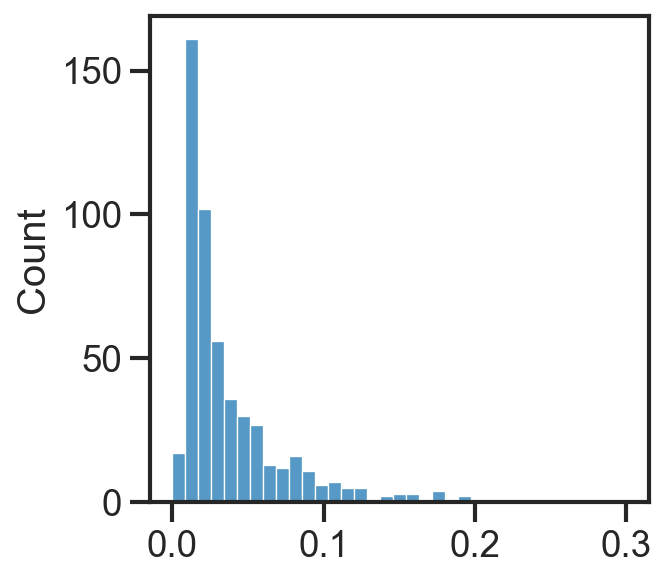

In [48]:
sns.histplot(tss_k4.mean())

In [49]:
tss_k4.loc[:,tss_k4.mean() > 0.1].columns

MultiIndex([(    'Ank3', '7'),
            (   'Aopep', '8'),
            ( 'Tsc22d1', '1'),
            (   'Robo1', '3'),
            (    'Rbpj', '3'),
            (    'Aff1', '1'),
            (    'Aff1', '2'),
            (   'Tenm4', '2'),
            (    'Gse1', '2'),
            (    'Gse1', '3'),
            (     'Emb', '2'),
            (   'Myo10', '5'),
            (   'Zmiz1', '1'),
            (    'Sgk1', '4'),
            (  'Dlgap4', '3'),
            (   'Kat6b', '1'),
            (   'Kat6b', '2'),
            (  'Adgra2', '1'),
            ( 'Syngap1', '1'),
            (    'Sgk3', '2'),
            (   'Sulf1', '1'),
            (   'Baz2b', '2'),
            (    'Ntn1', '2'),
            (  'Arid5b', '1'),
            (   'Stox2', '4'),
            (  'Phldb2', '3'),
            (  'Bicral', '1'),
            (  'Csnk1e', '2'),
            (    'Gab1', '1'),
            (    'Tjp2', '1'),
            (    'Usp7', '2'),
            (      'C2', '1'),
        

In [50]:
tss_k4.columns.levels[0]

Index(['Abr', 'Adgra2', 'Adgrb1', 'Adipor2', 'Aff1', 'Agtpbp1', 'Ahnak',
       'Aim2', 'Ank2', 'Ank3',
       ...
       'Tns1', 'Trim2', 'Trpm4', 'Tsc22d1', 'Usp7', 'Vgll4', 'Wdtc1', 'Wscd2',
       'Zfp217', 'Zmiz1'],
      dtype='object', name='gene', length=112)

In [51]:
tss_k27.columns.levels[0]

Index(['Abr', 'Adgra2', 'Adgrb1', 'Adipor2', 'Aff1', 'Agtpbp1', 'Ahnak',
       'Aim2', 'Ank2', 'Ank3',
       ...
       'Tns1', 'Trim2', 'Trpm4', 'Tsc22d1', 'Usp7', 'Vgll4', 'Wdtc1', 'Wscd2',
       'Zfp217', 'Zmiz1'],
      dtype='object', name='gene', length=112)

In [52]:
tss_rna.columns.levels[0]

Index(['Abr', 'Adgra2', 'Adgrb1', 'Adipor2', 'Aff1', 'Agtpbp1', 'Ahnak',
       'Aim2', 'Ank2', 'Ank3',
       ...
       'Tns1', 'Trim2', 'Trpm4', 'Tsc22d1', 'Usp7', 'Vgll4', 'Wdtc1', 'Wscd2',
       'Zfp217', 'Zmiz1'],
      dtype='object', name='gene', length=112)

Mesoderm


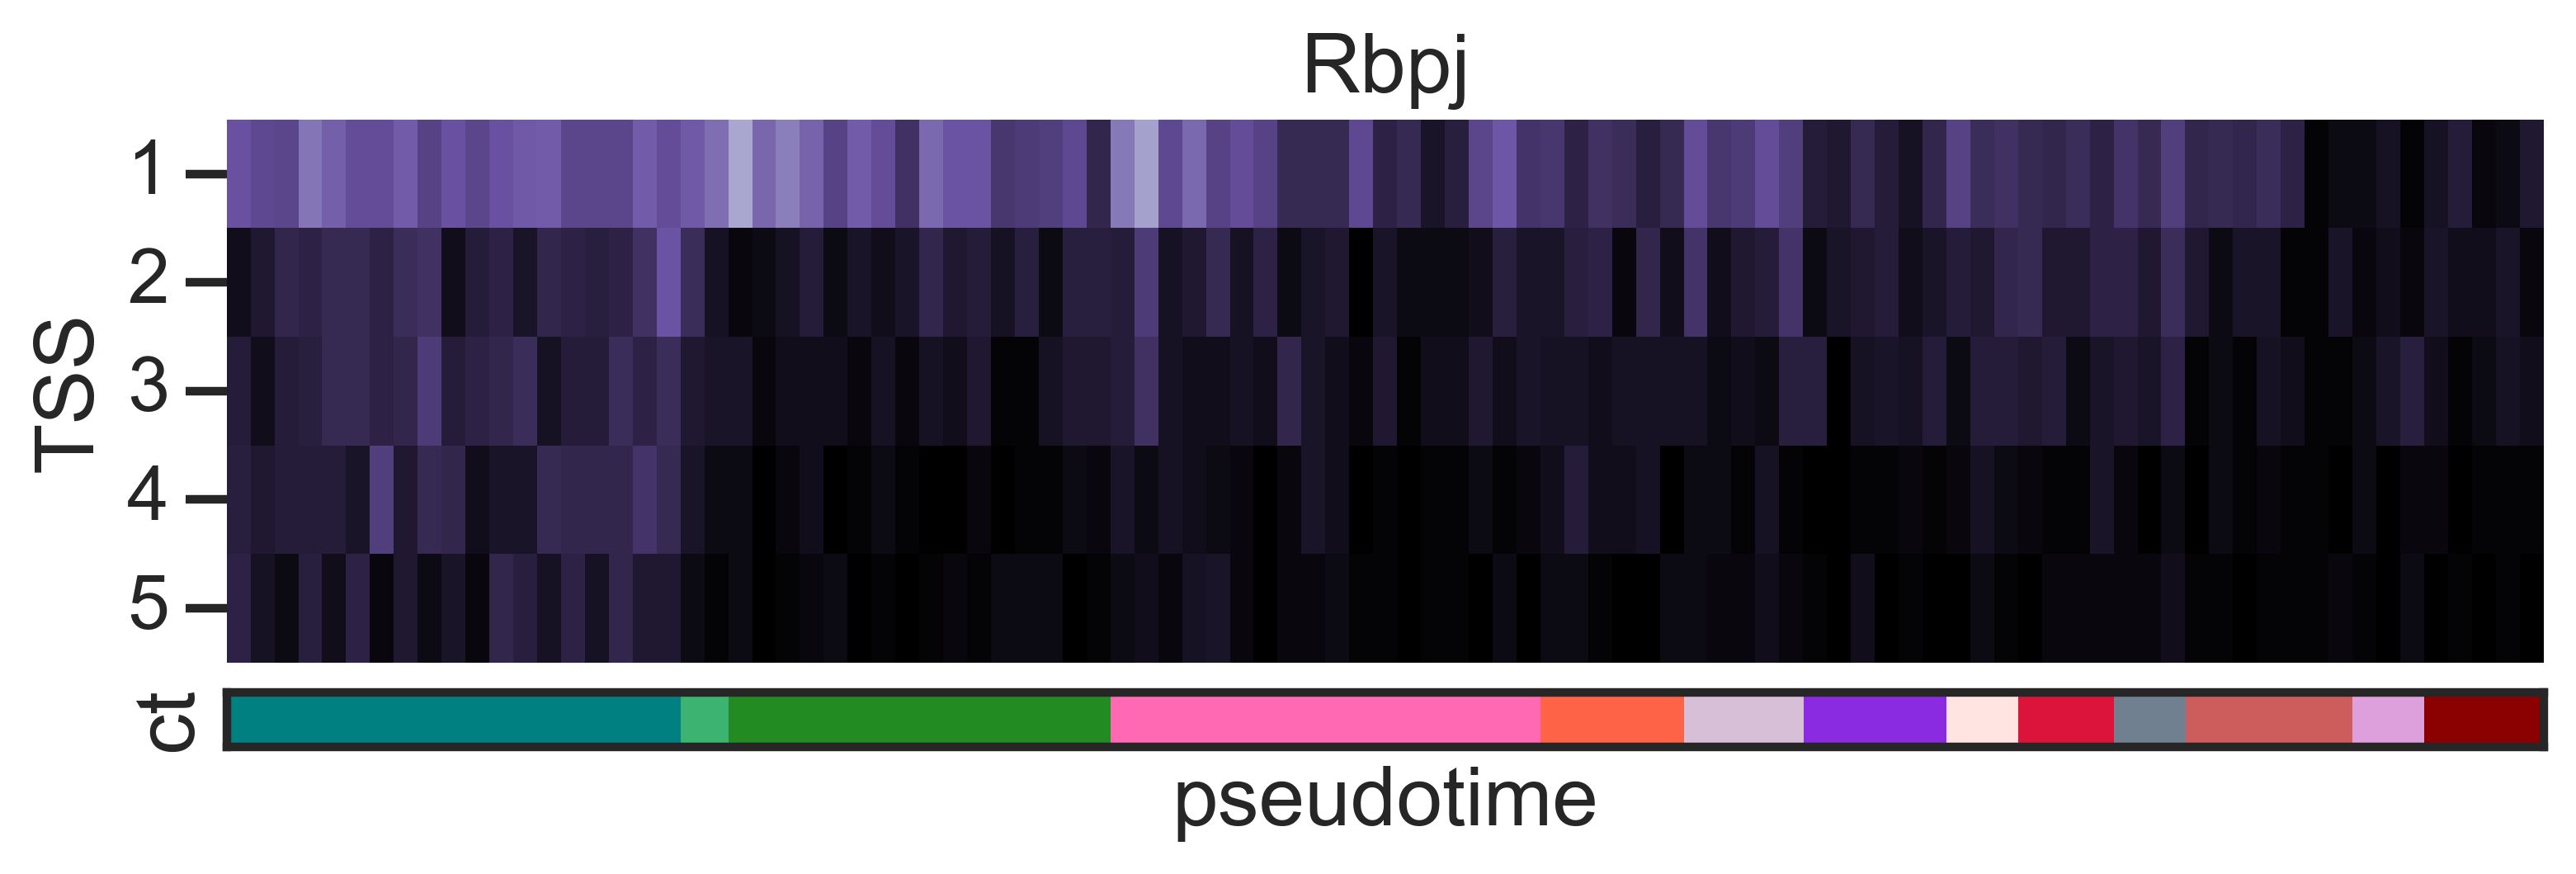

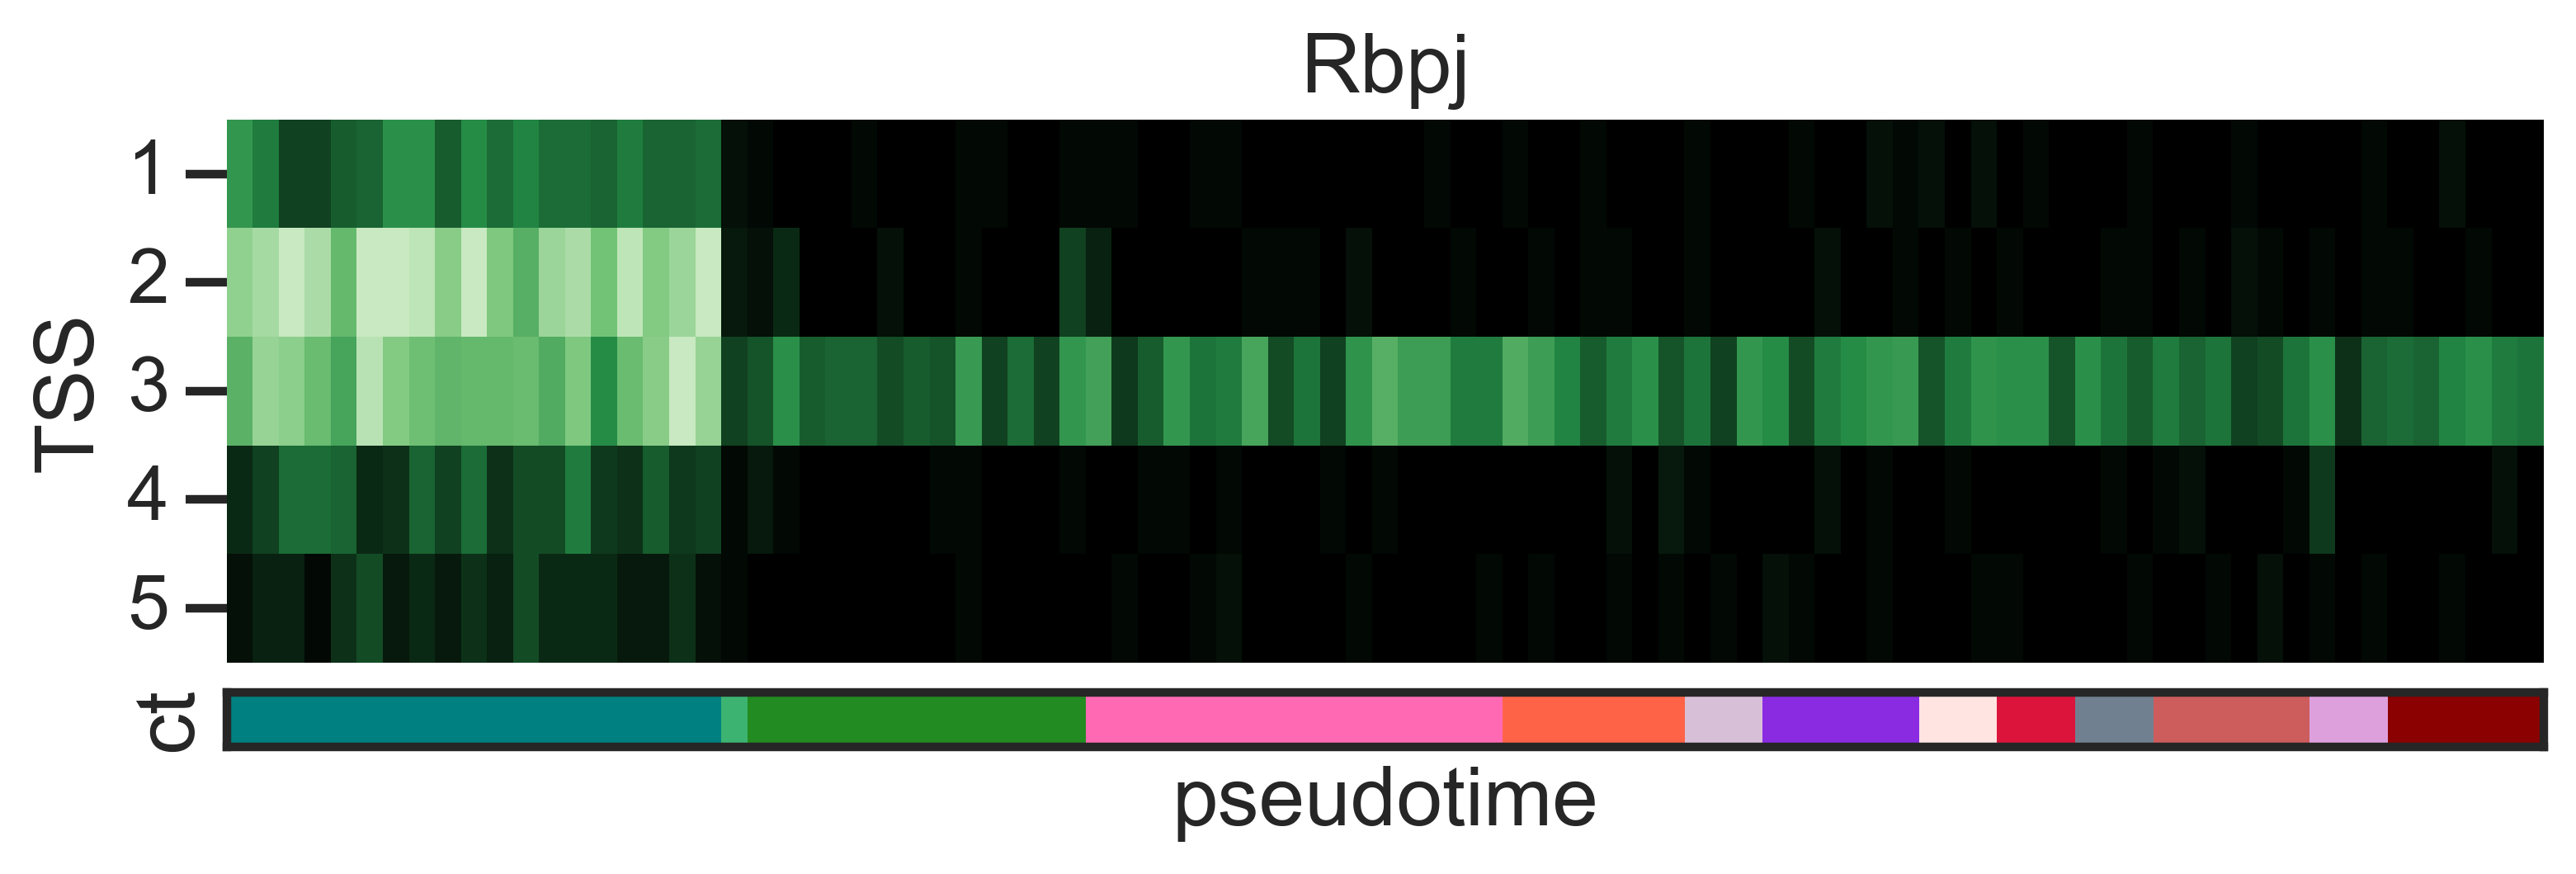

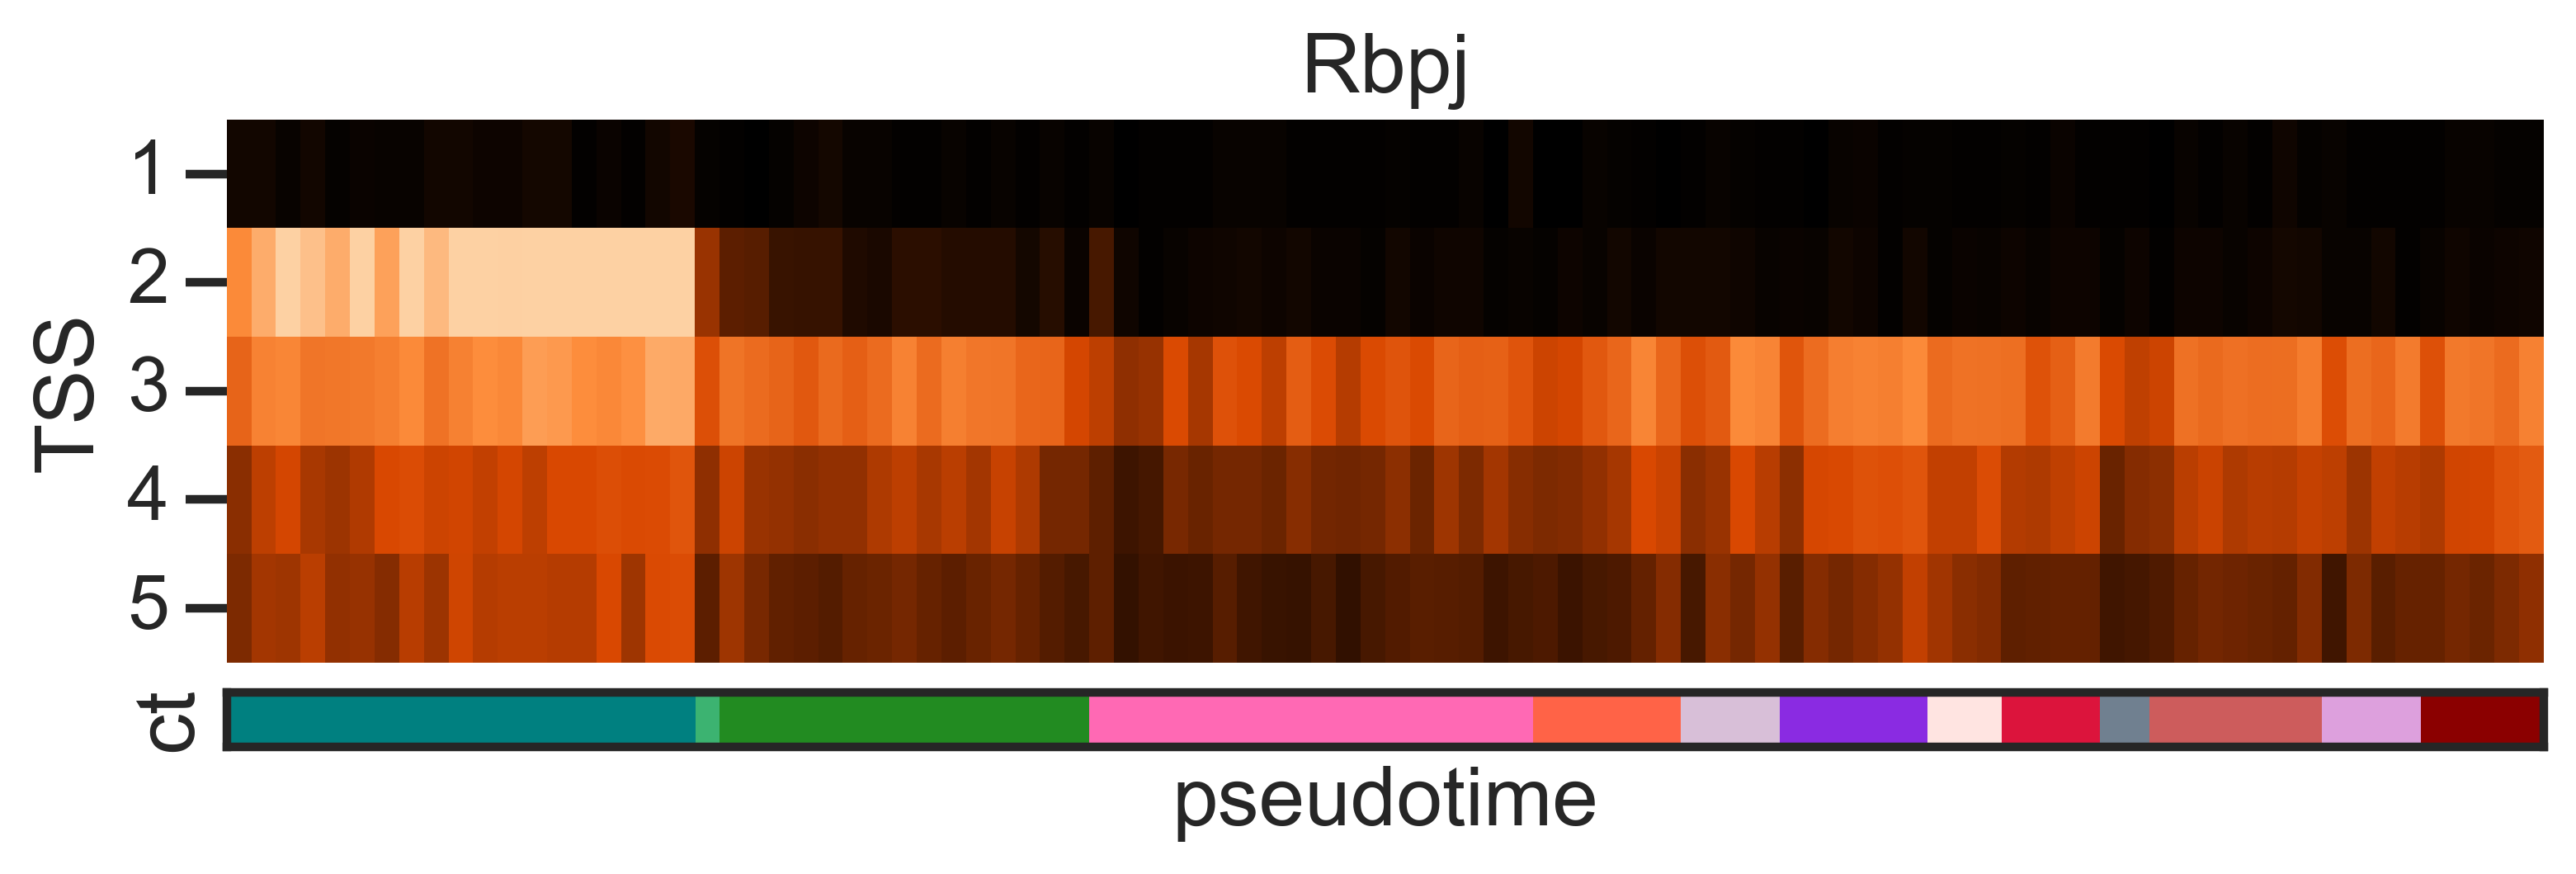

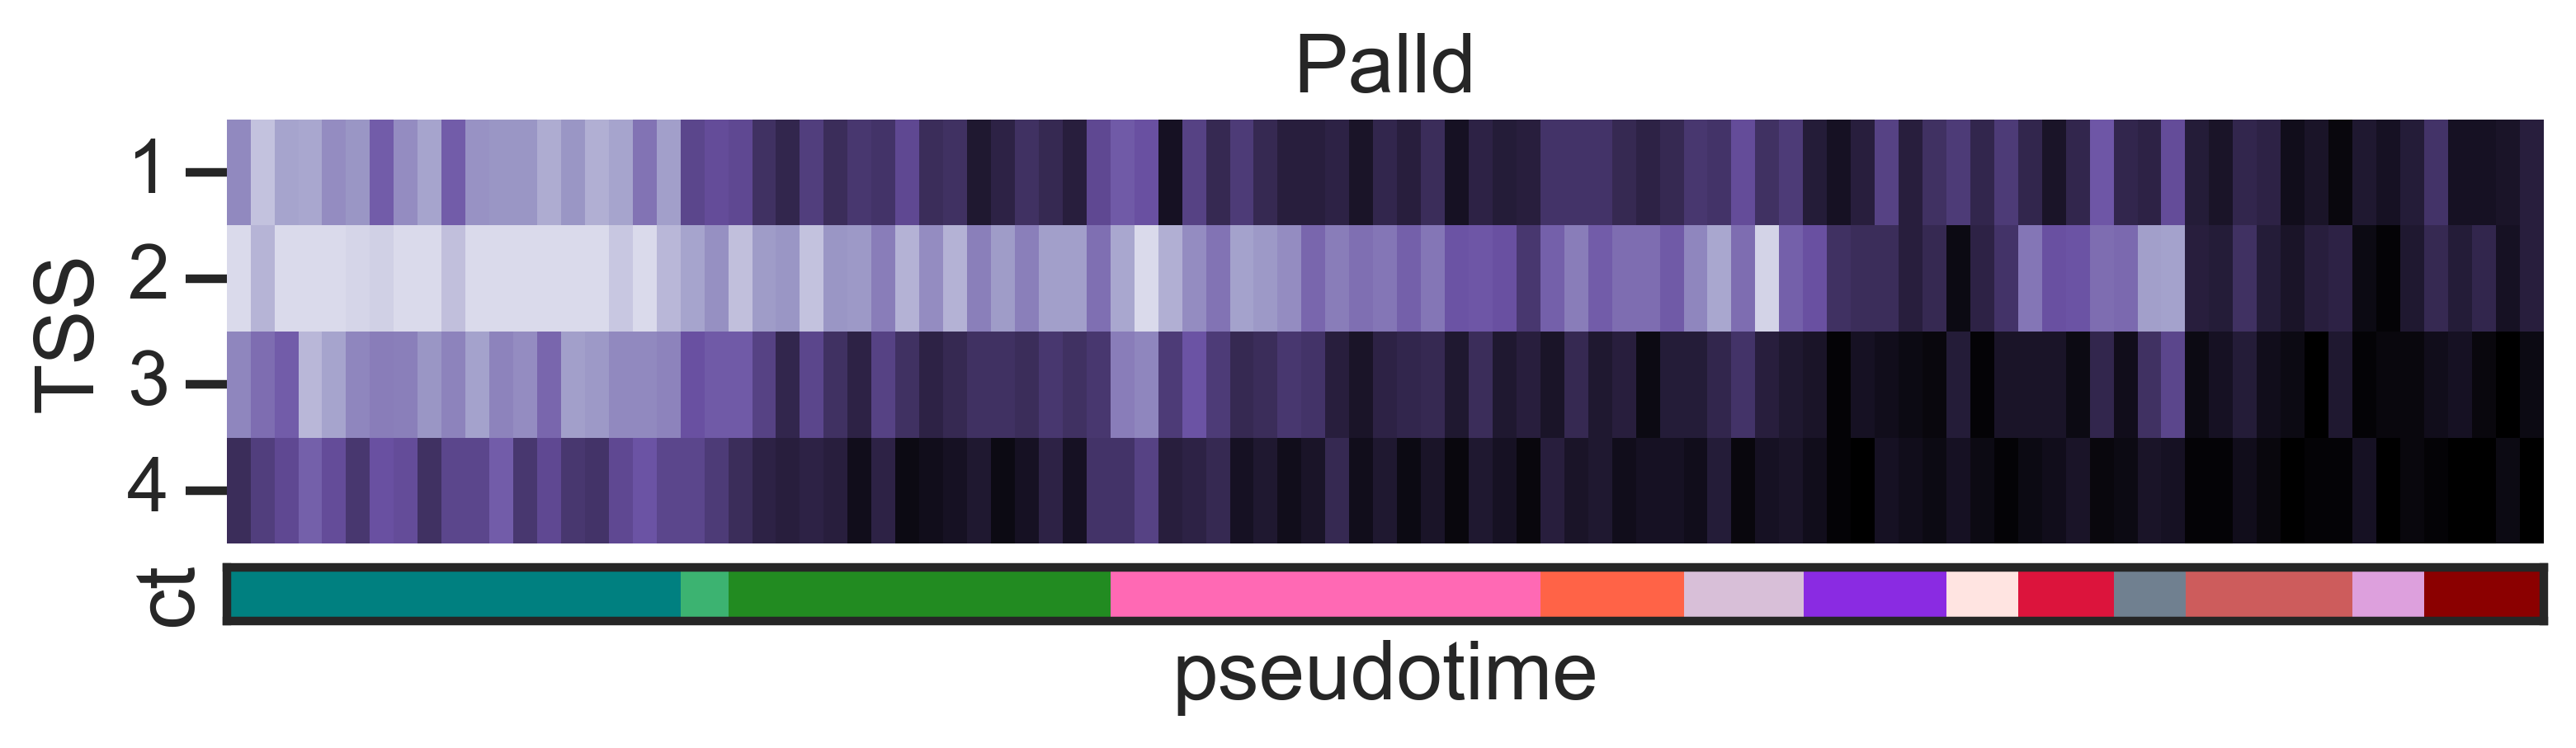

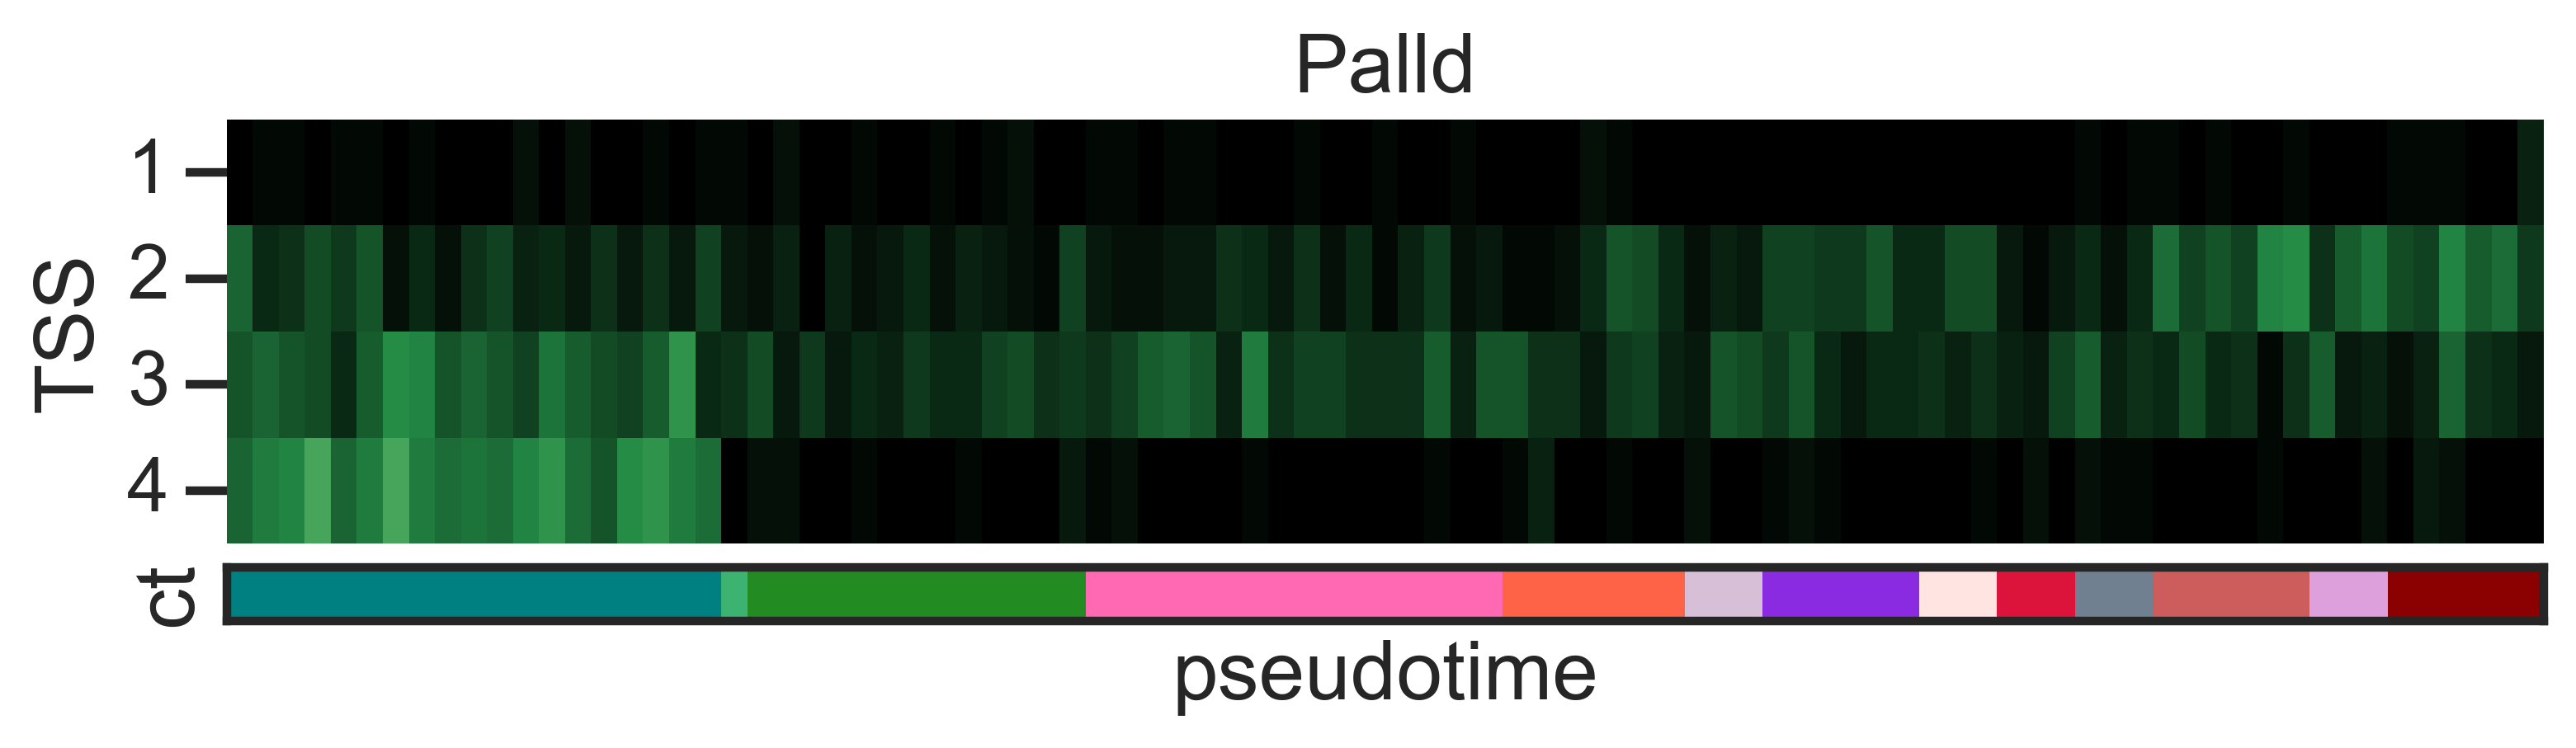

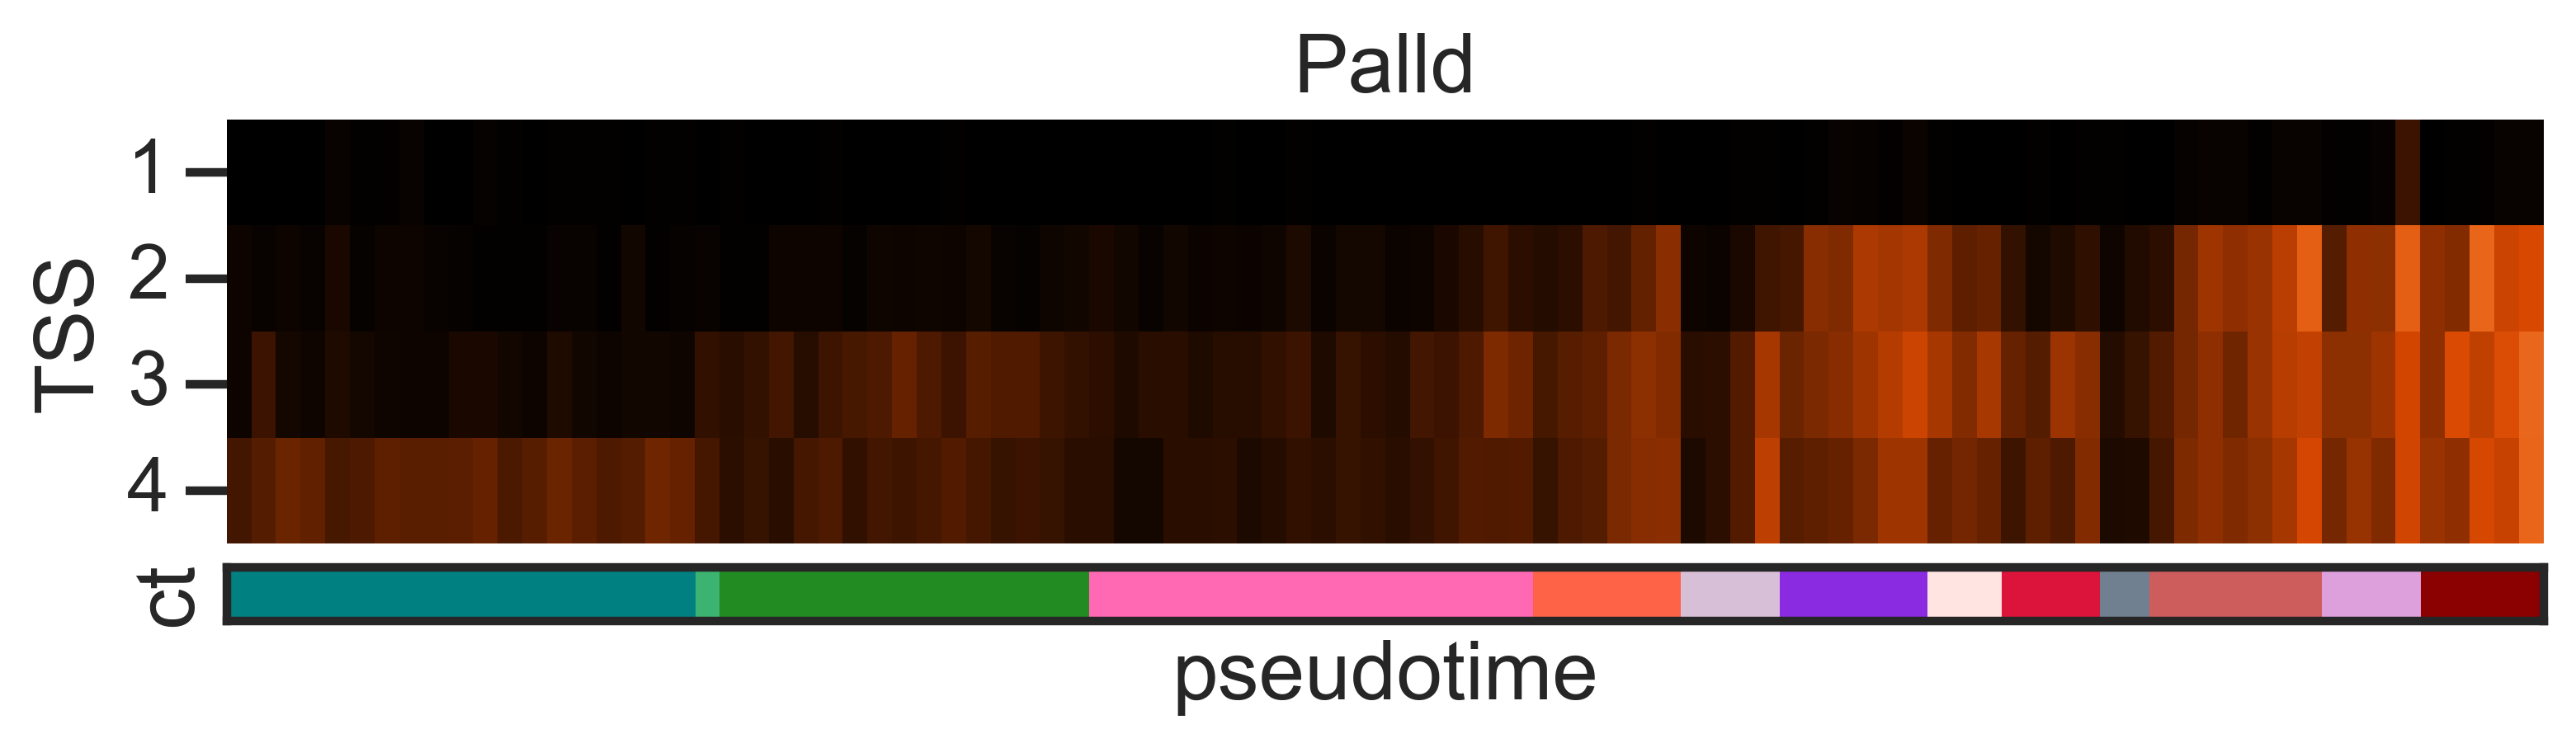

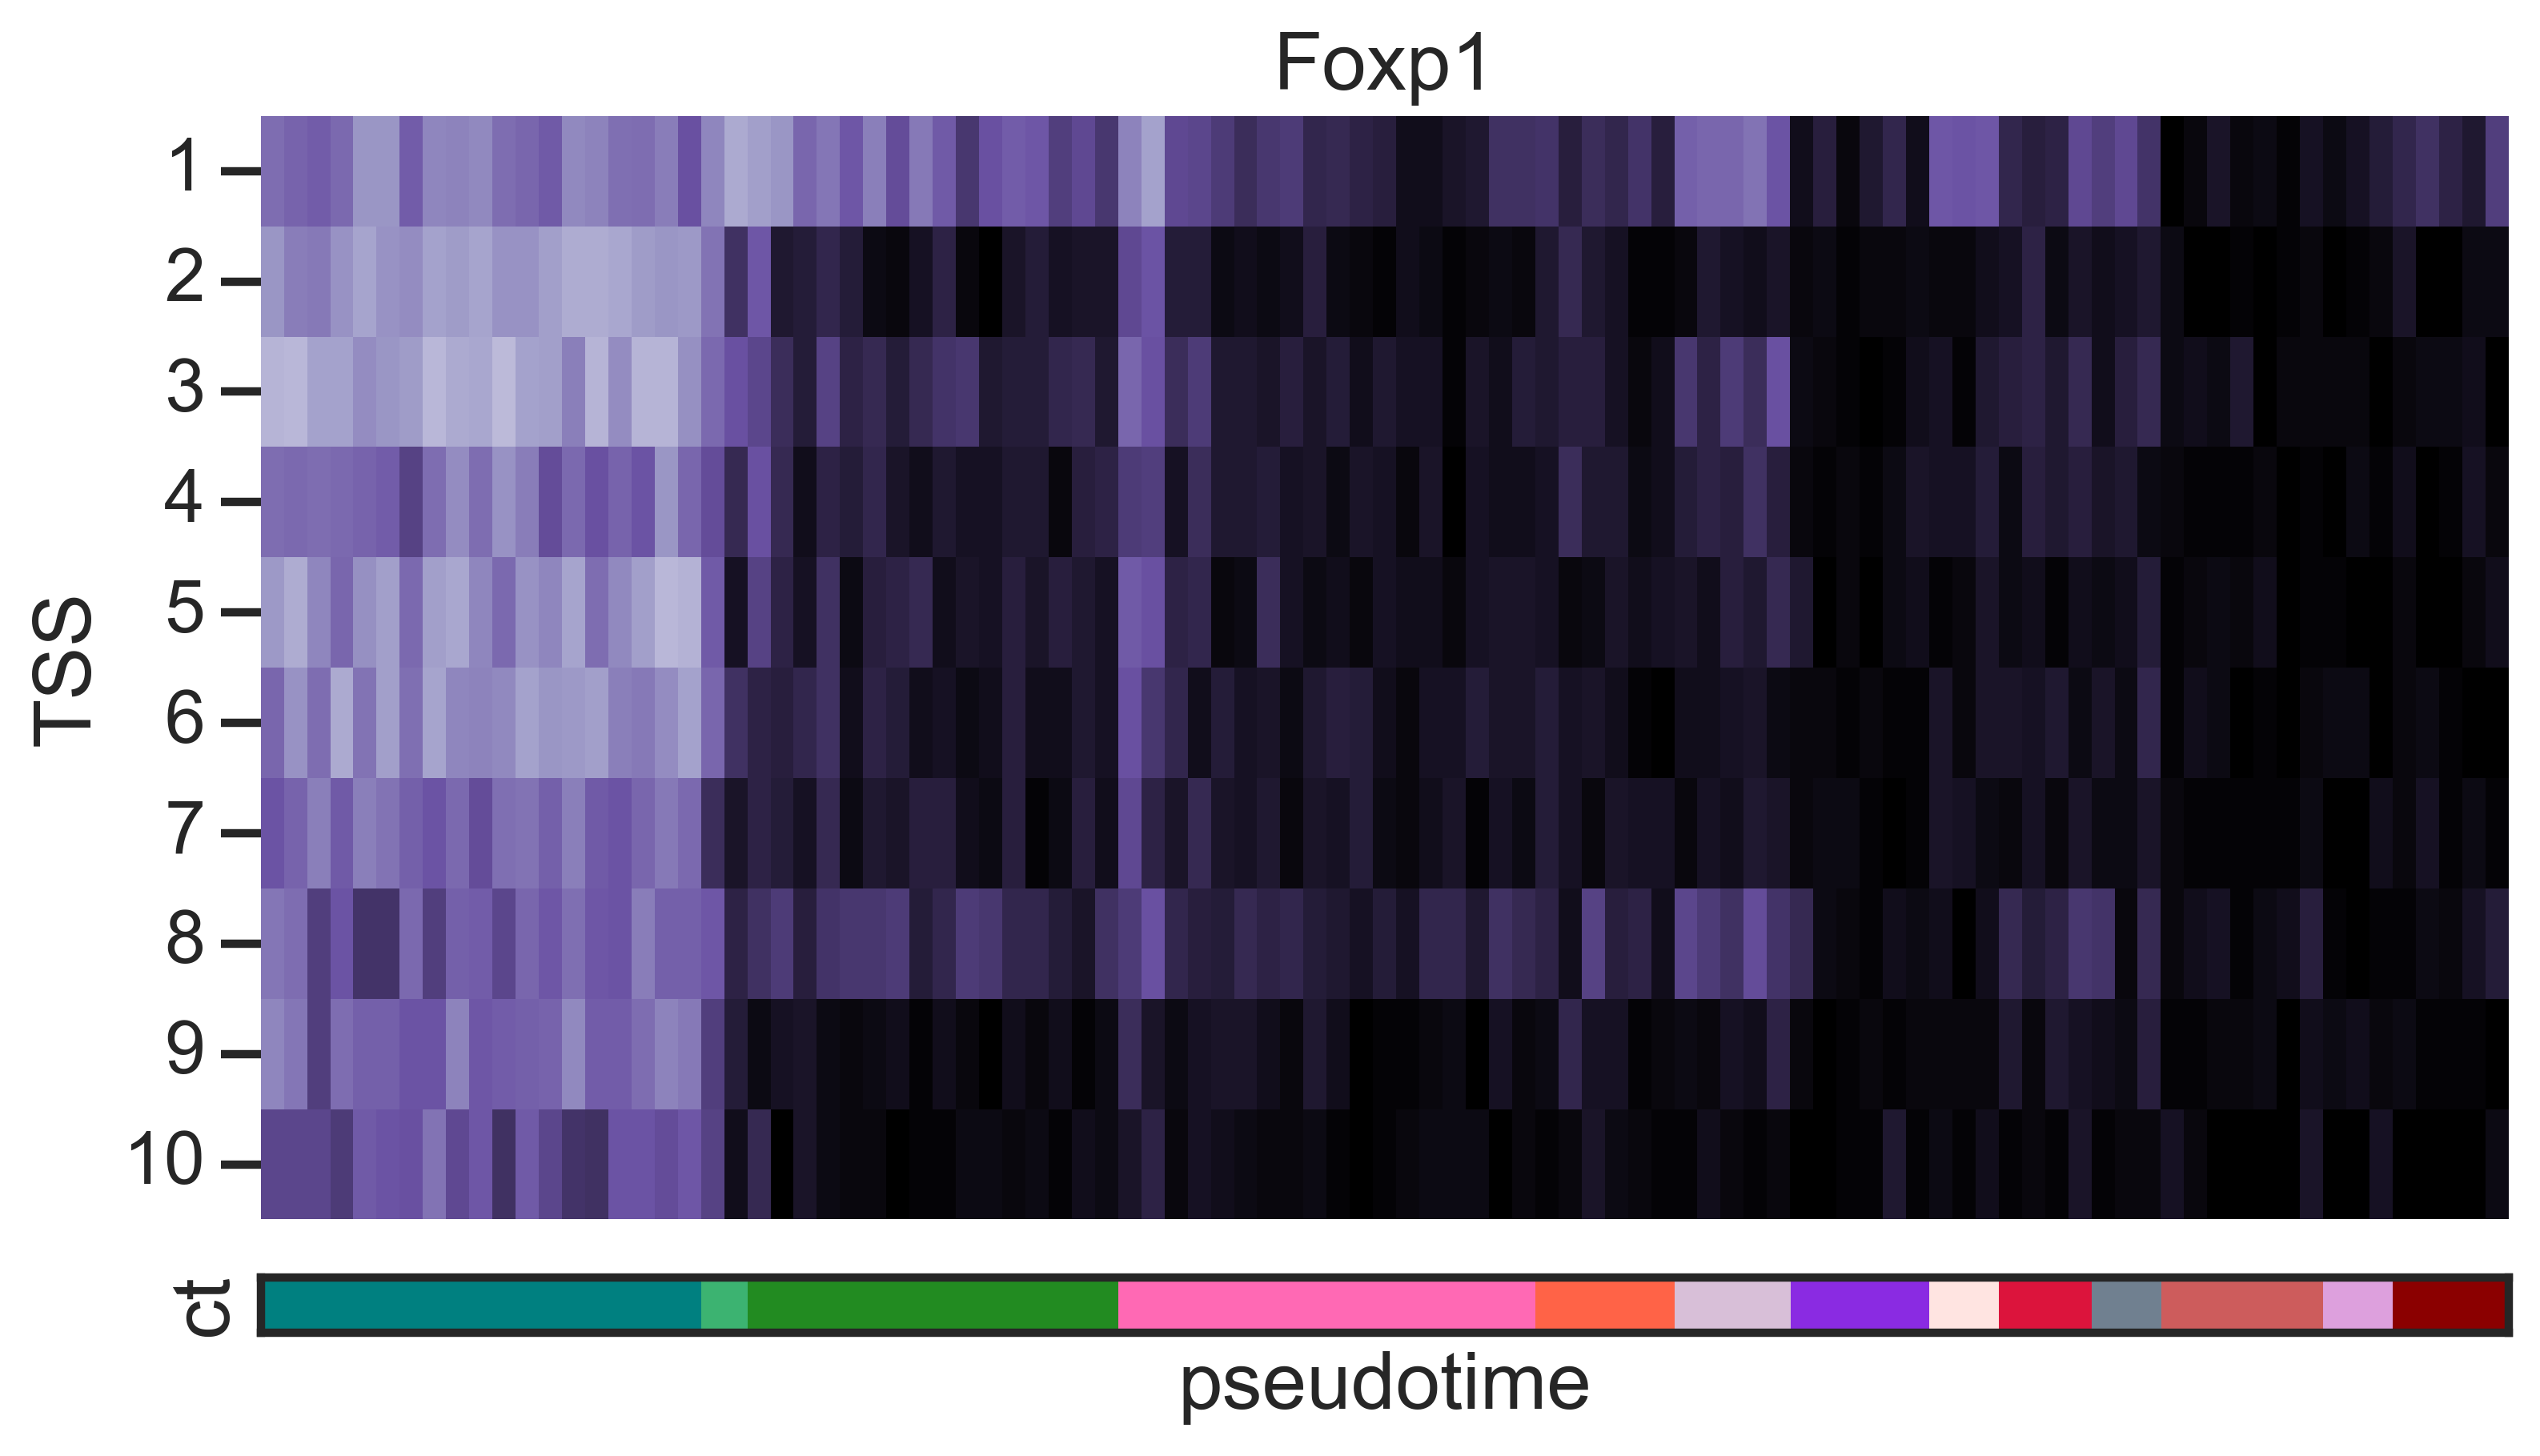

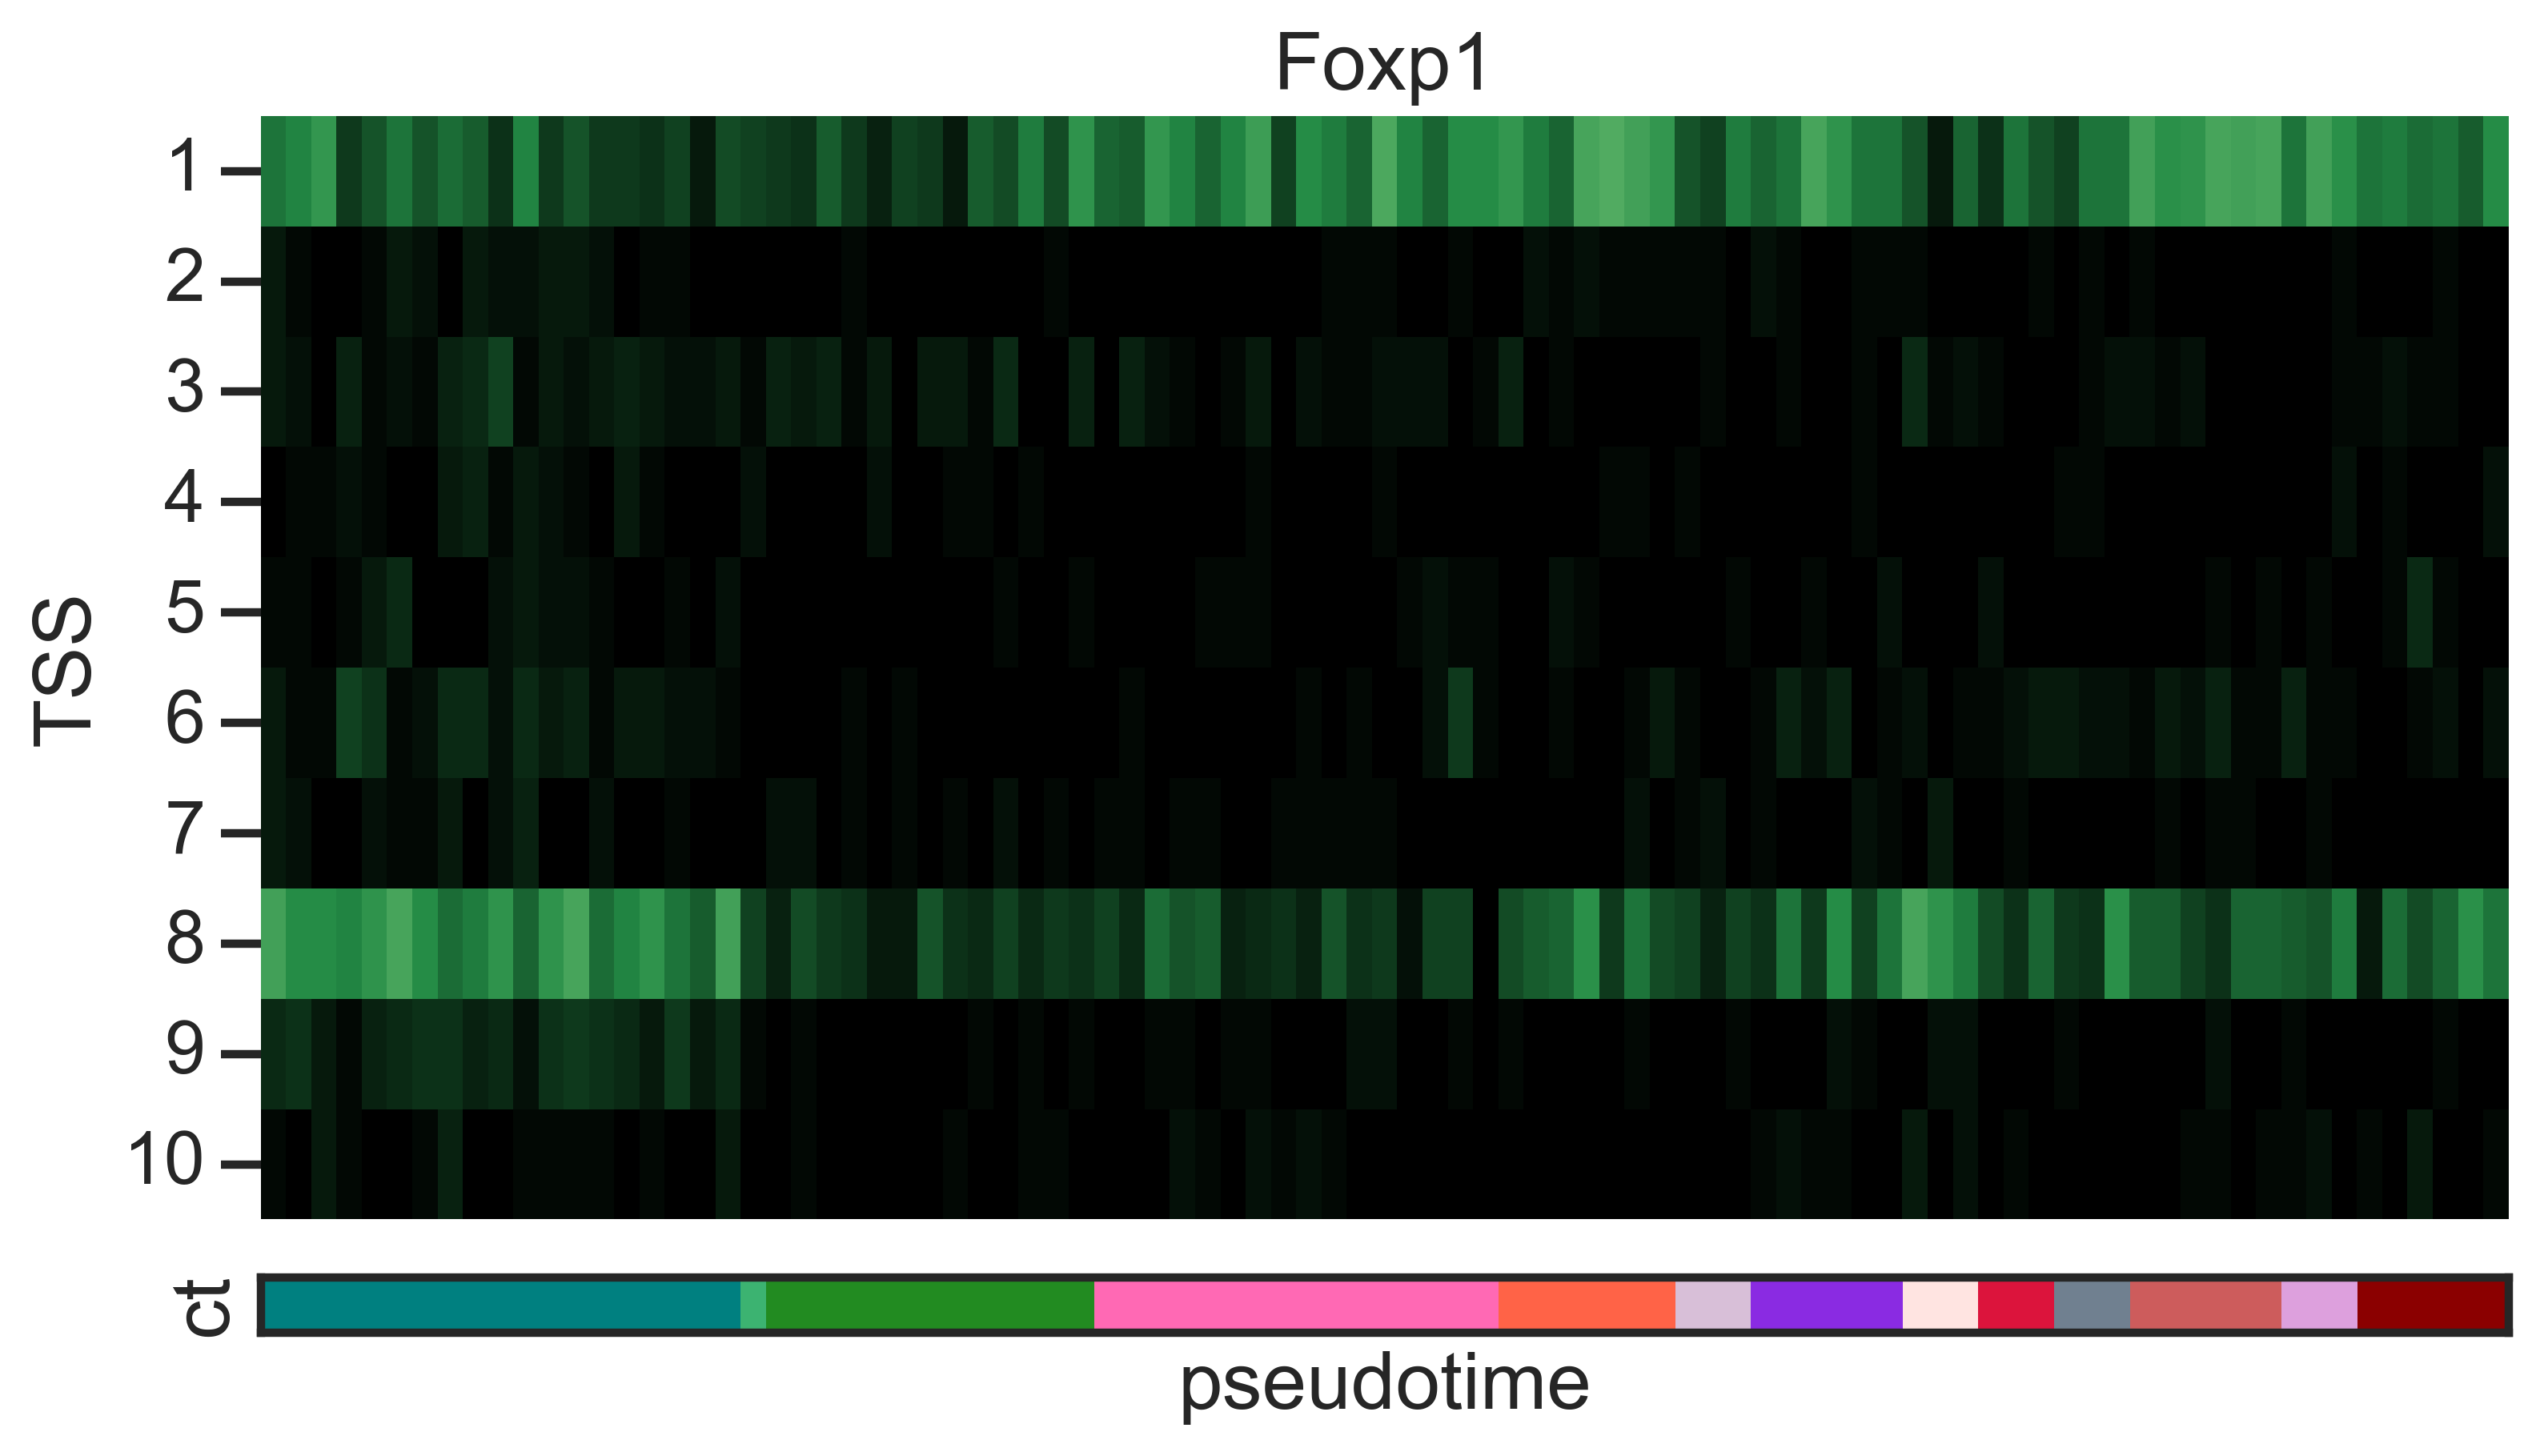

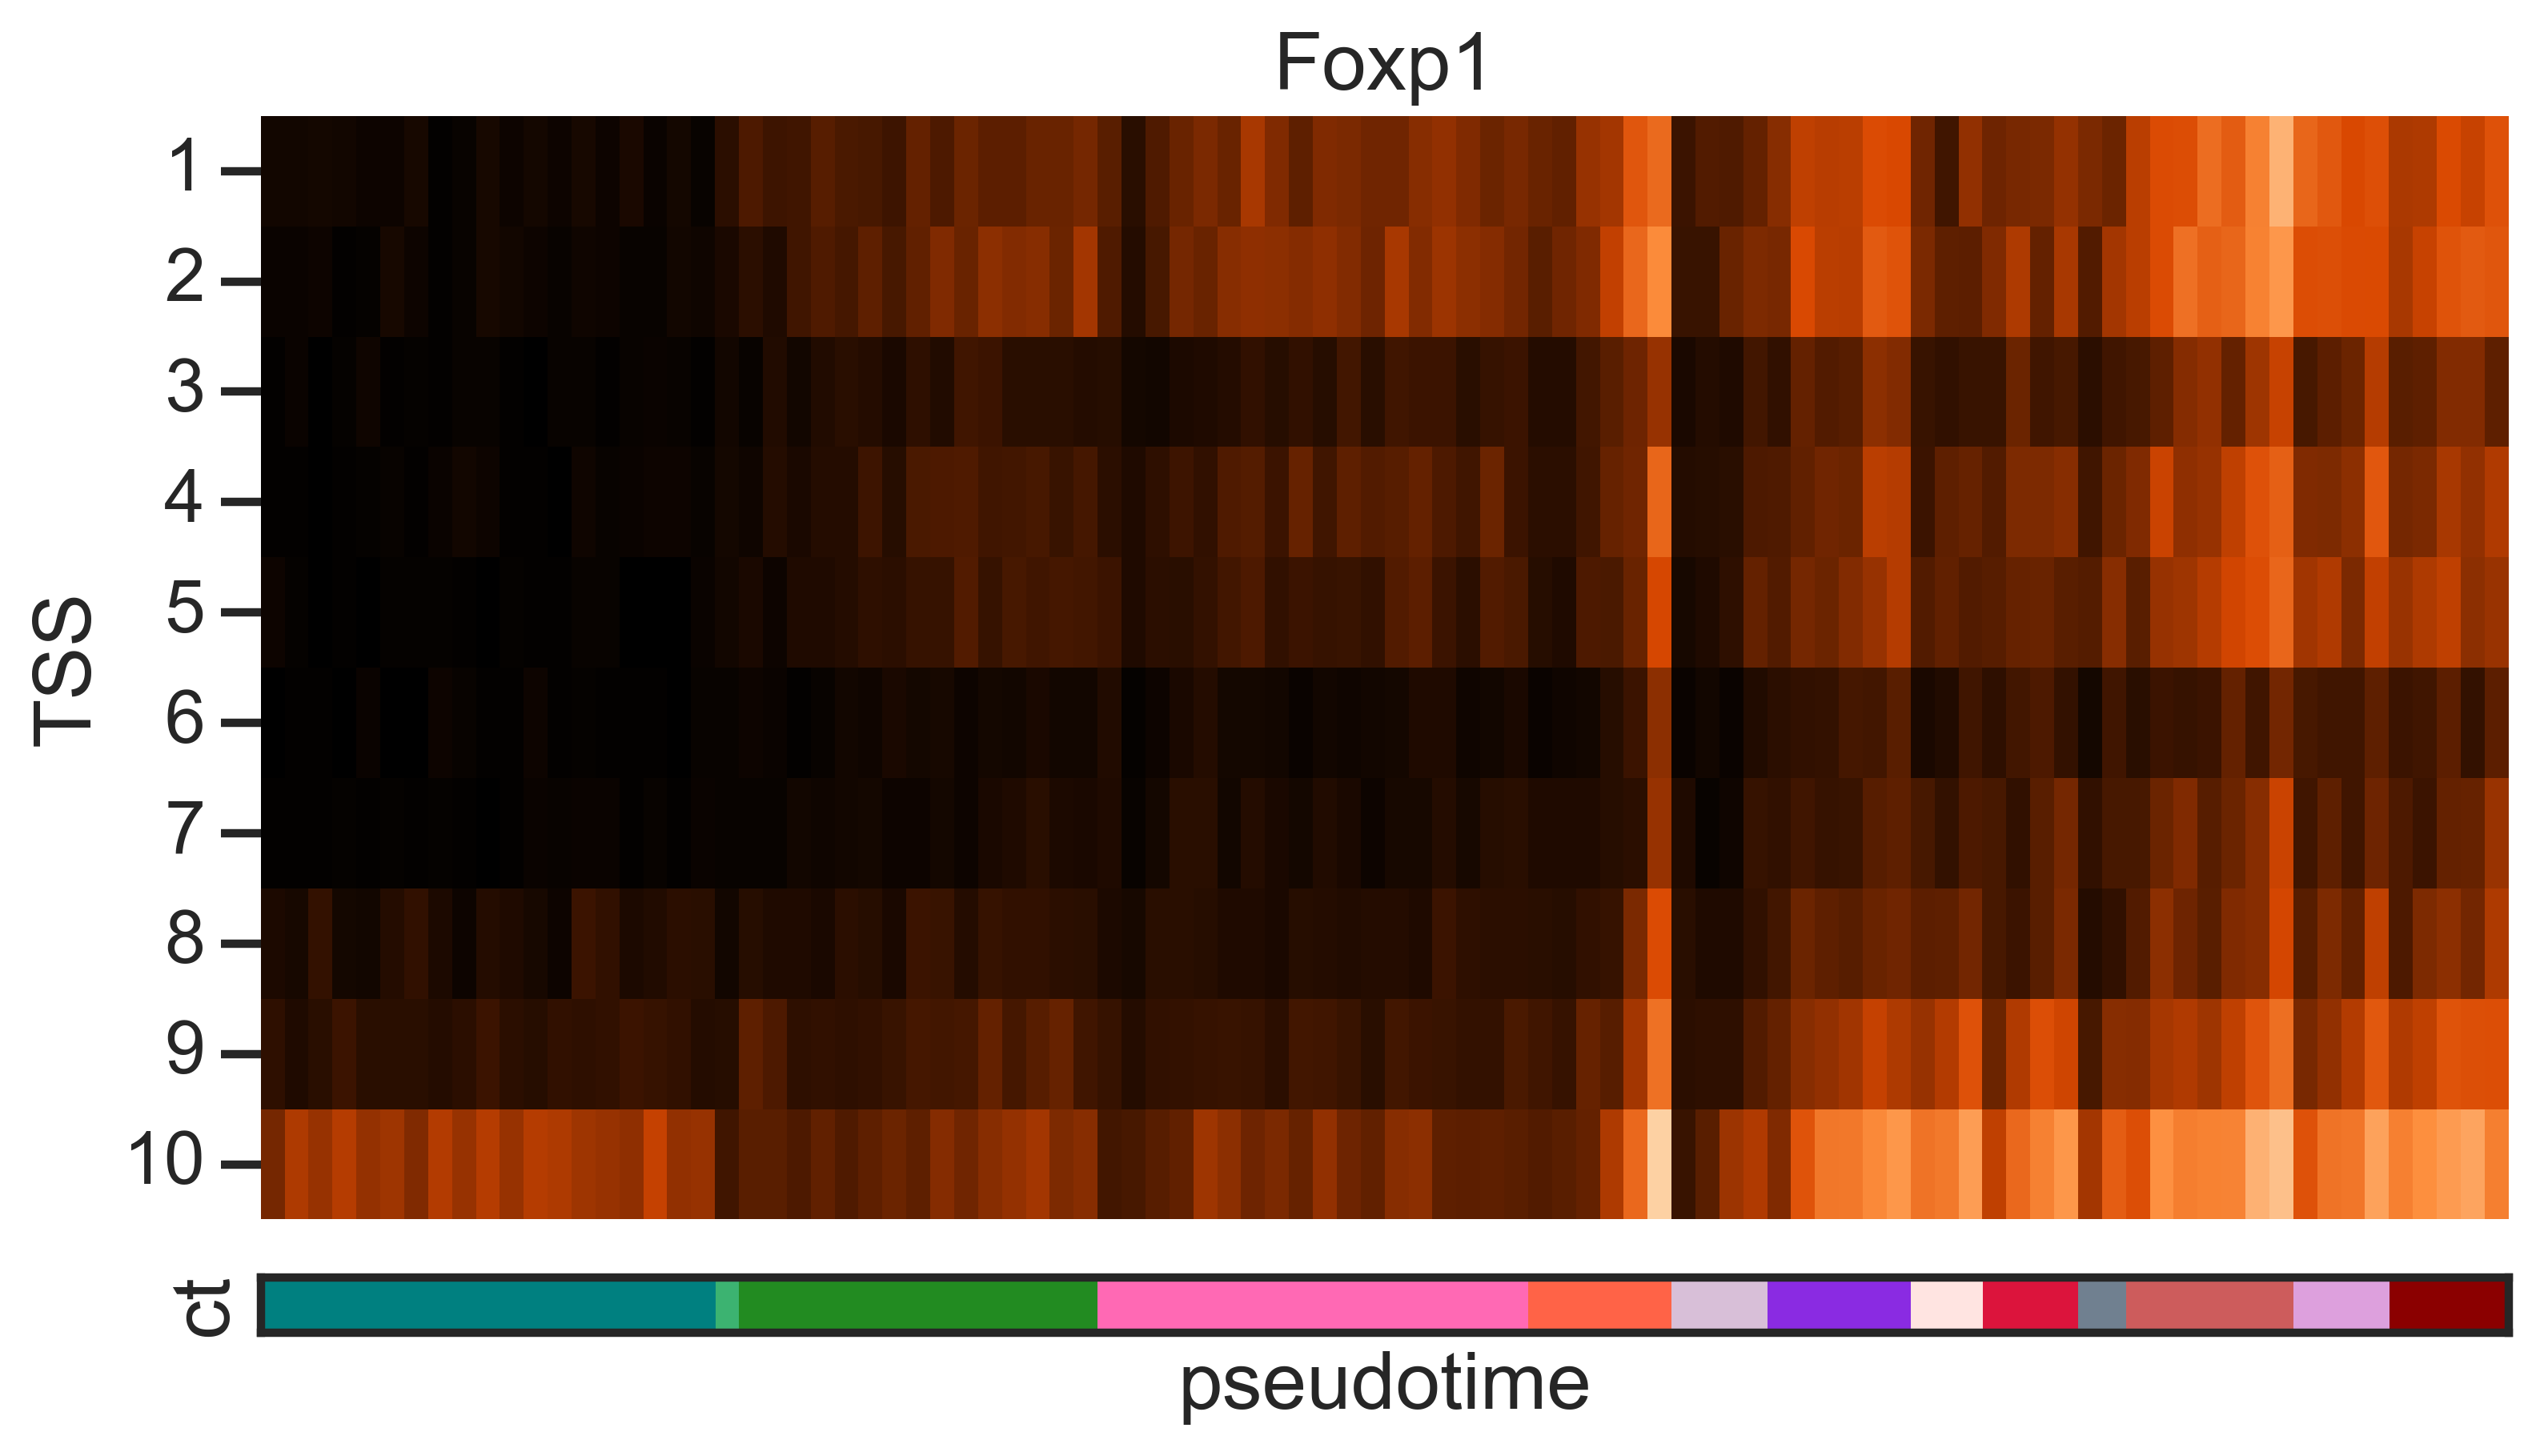

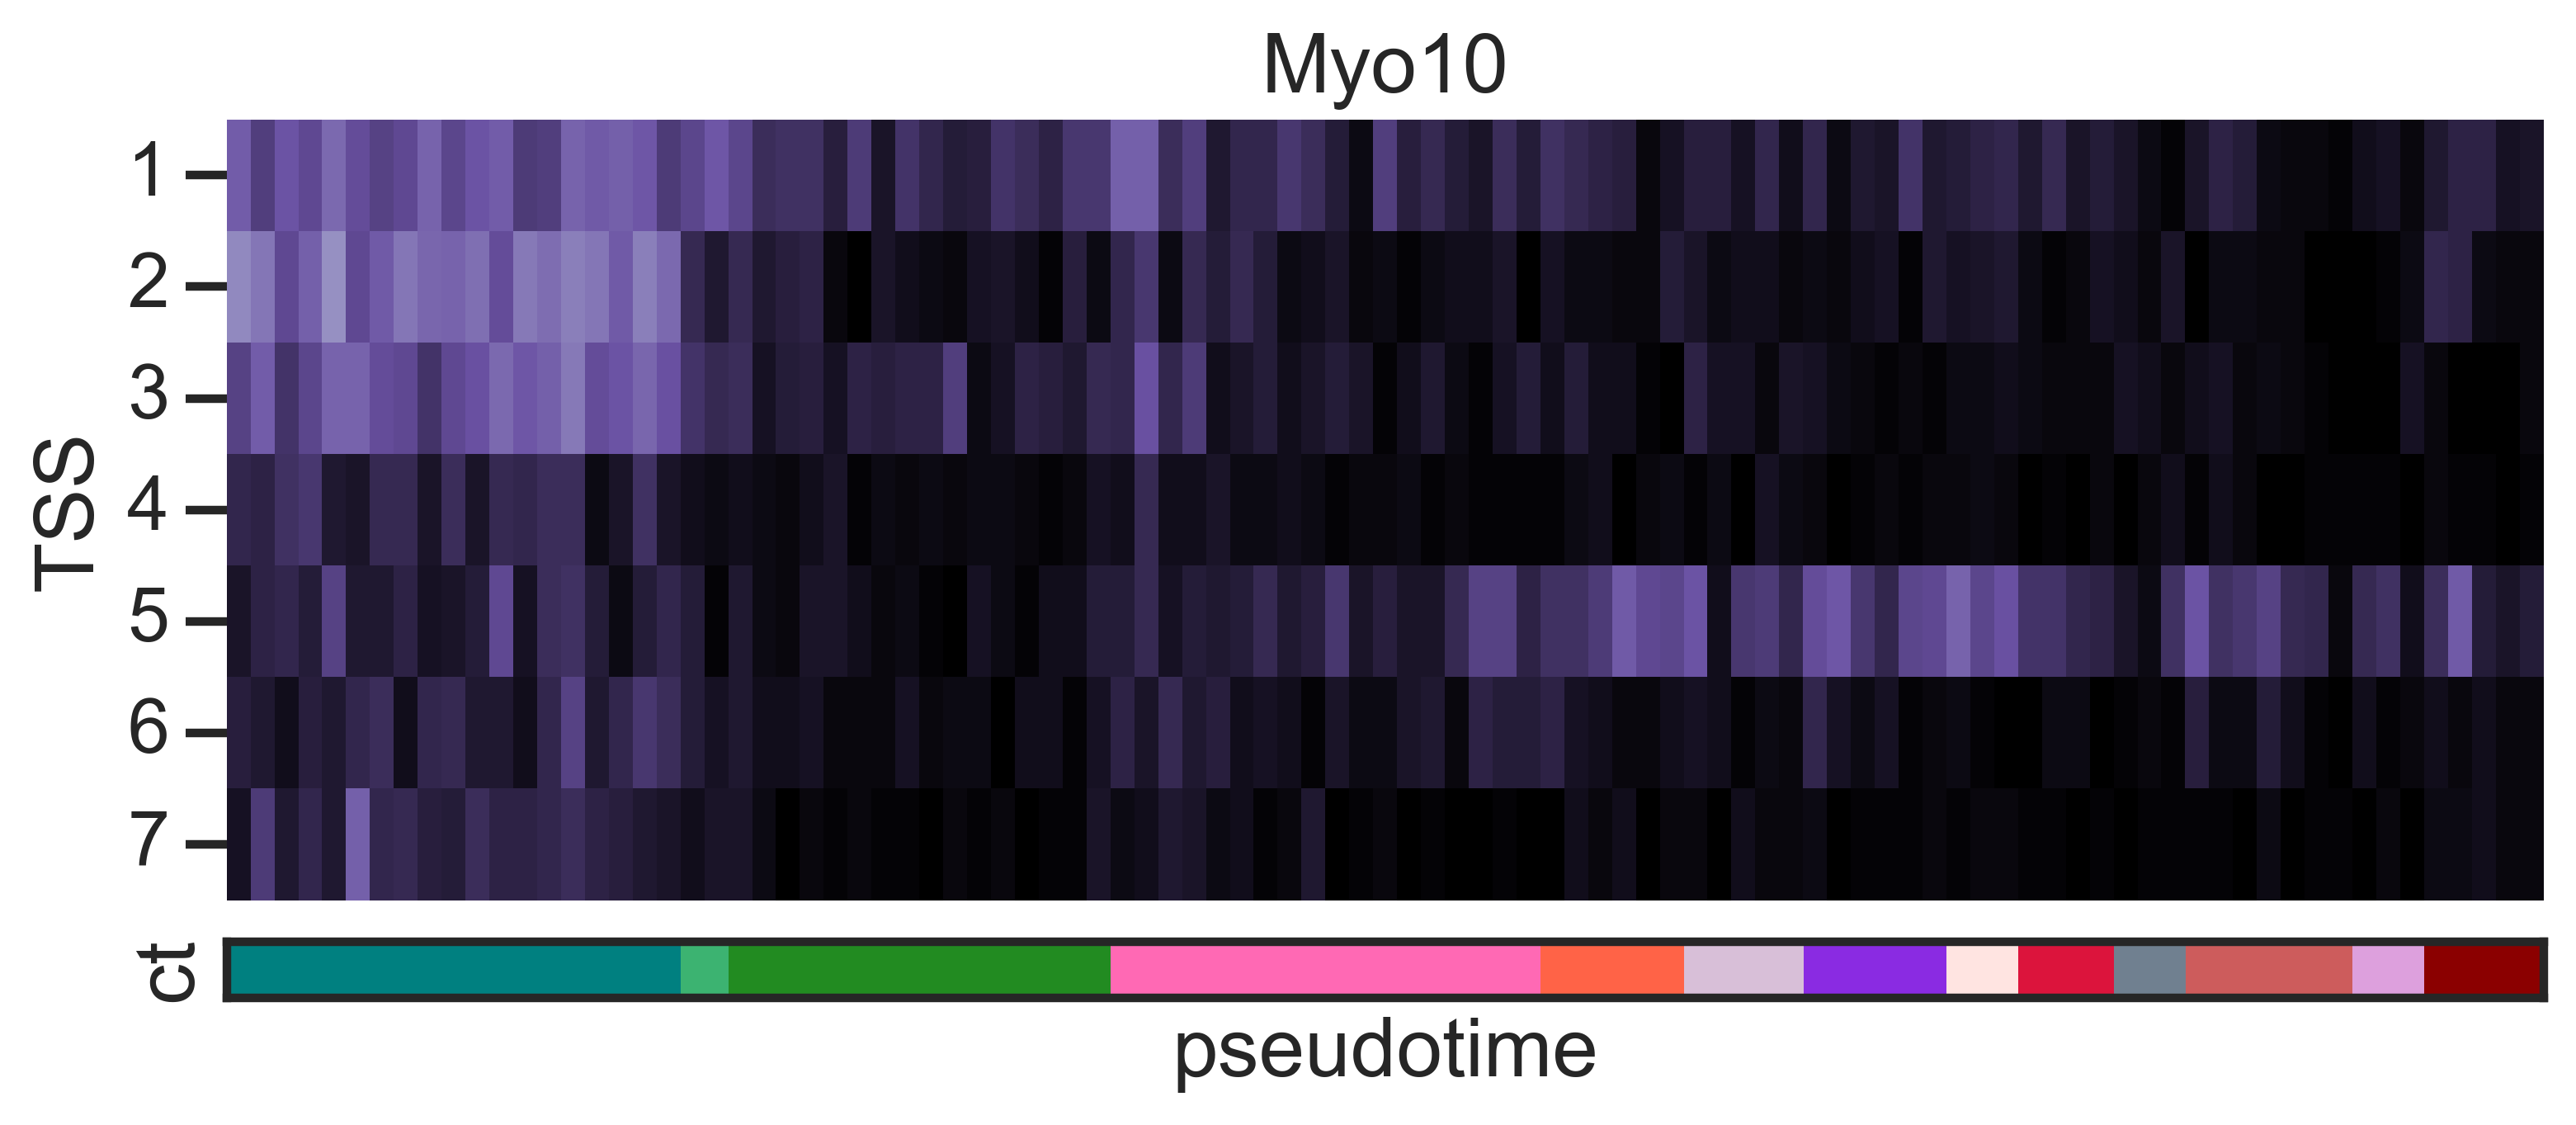

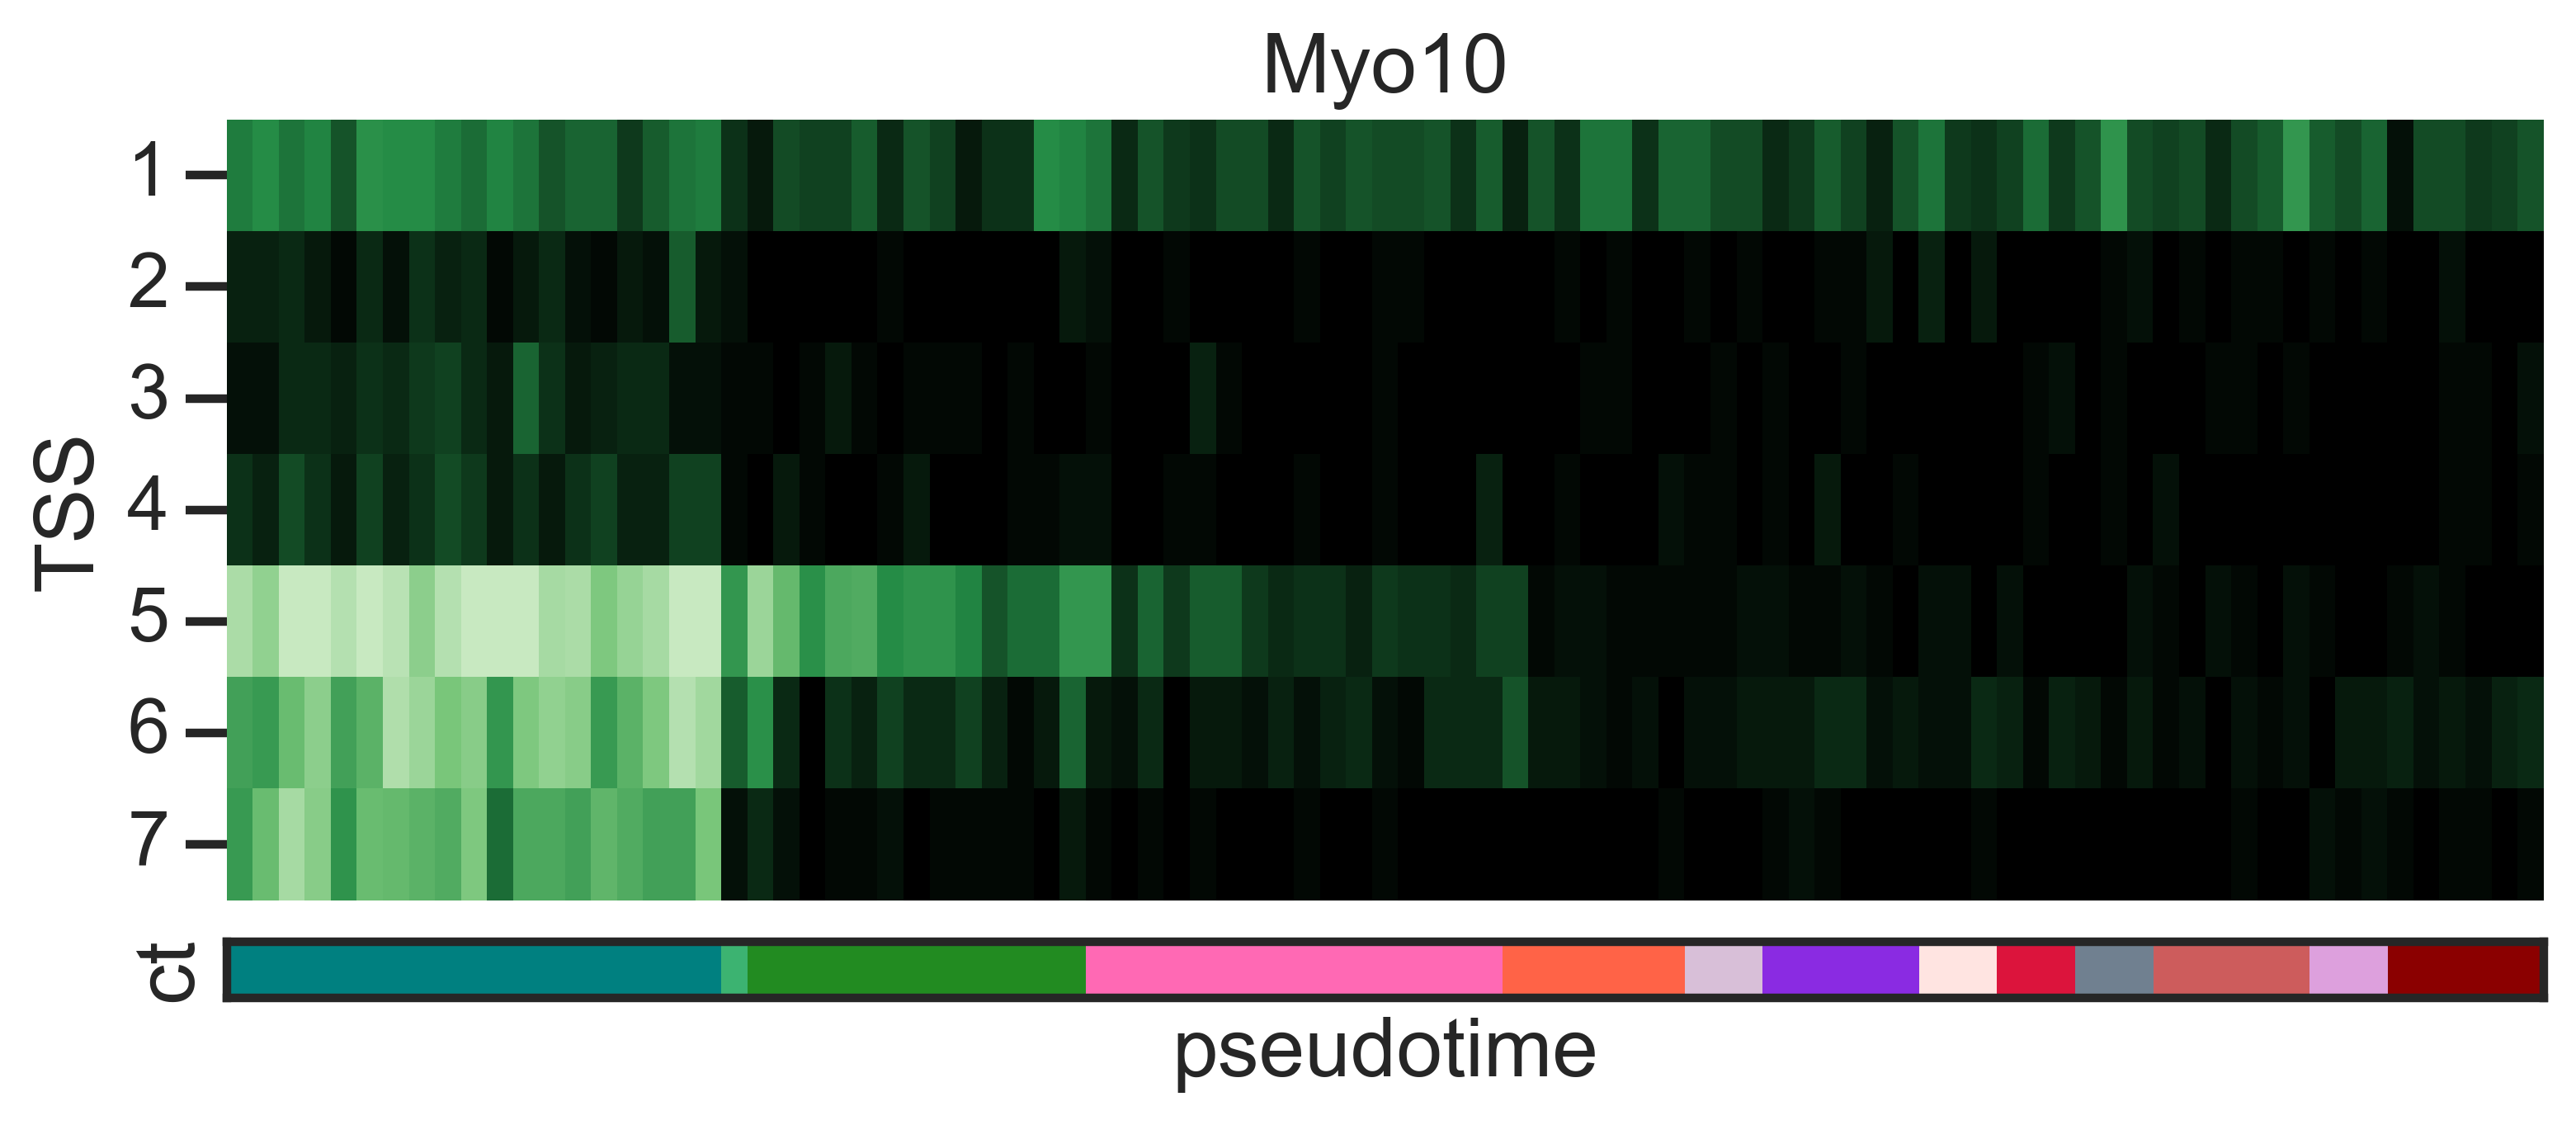

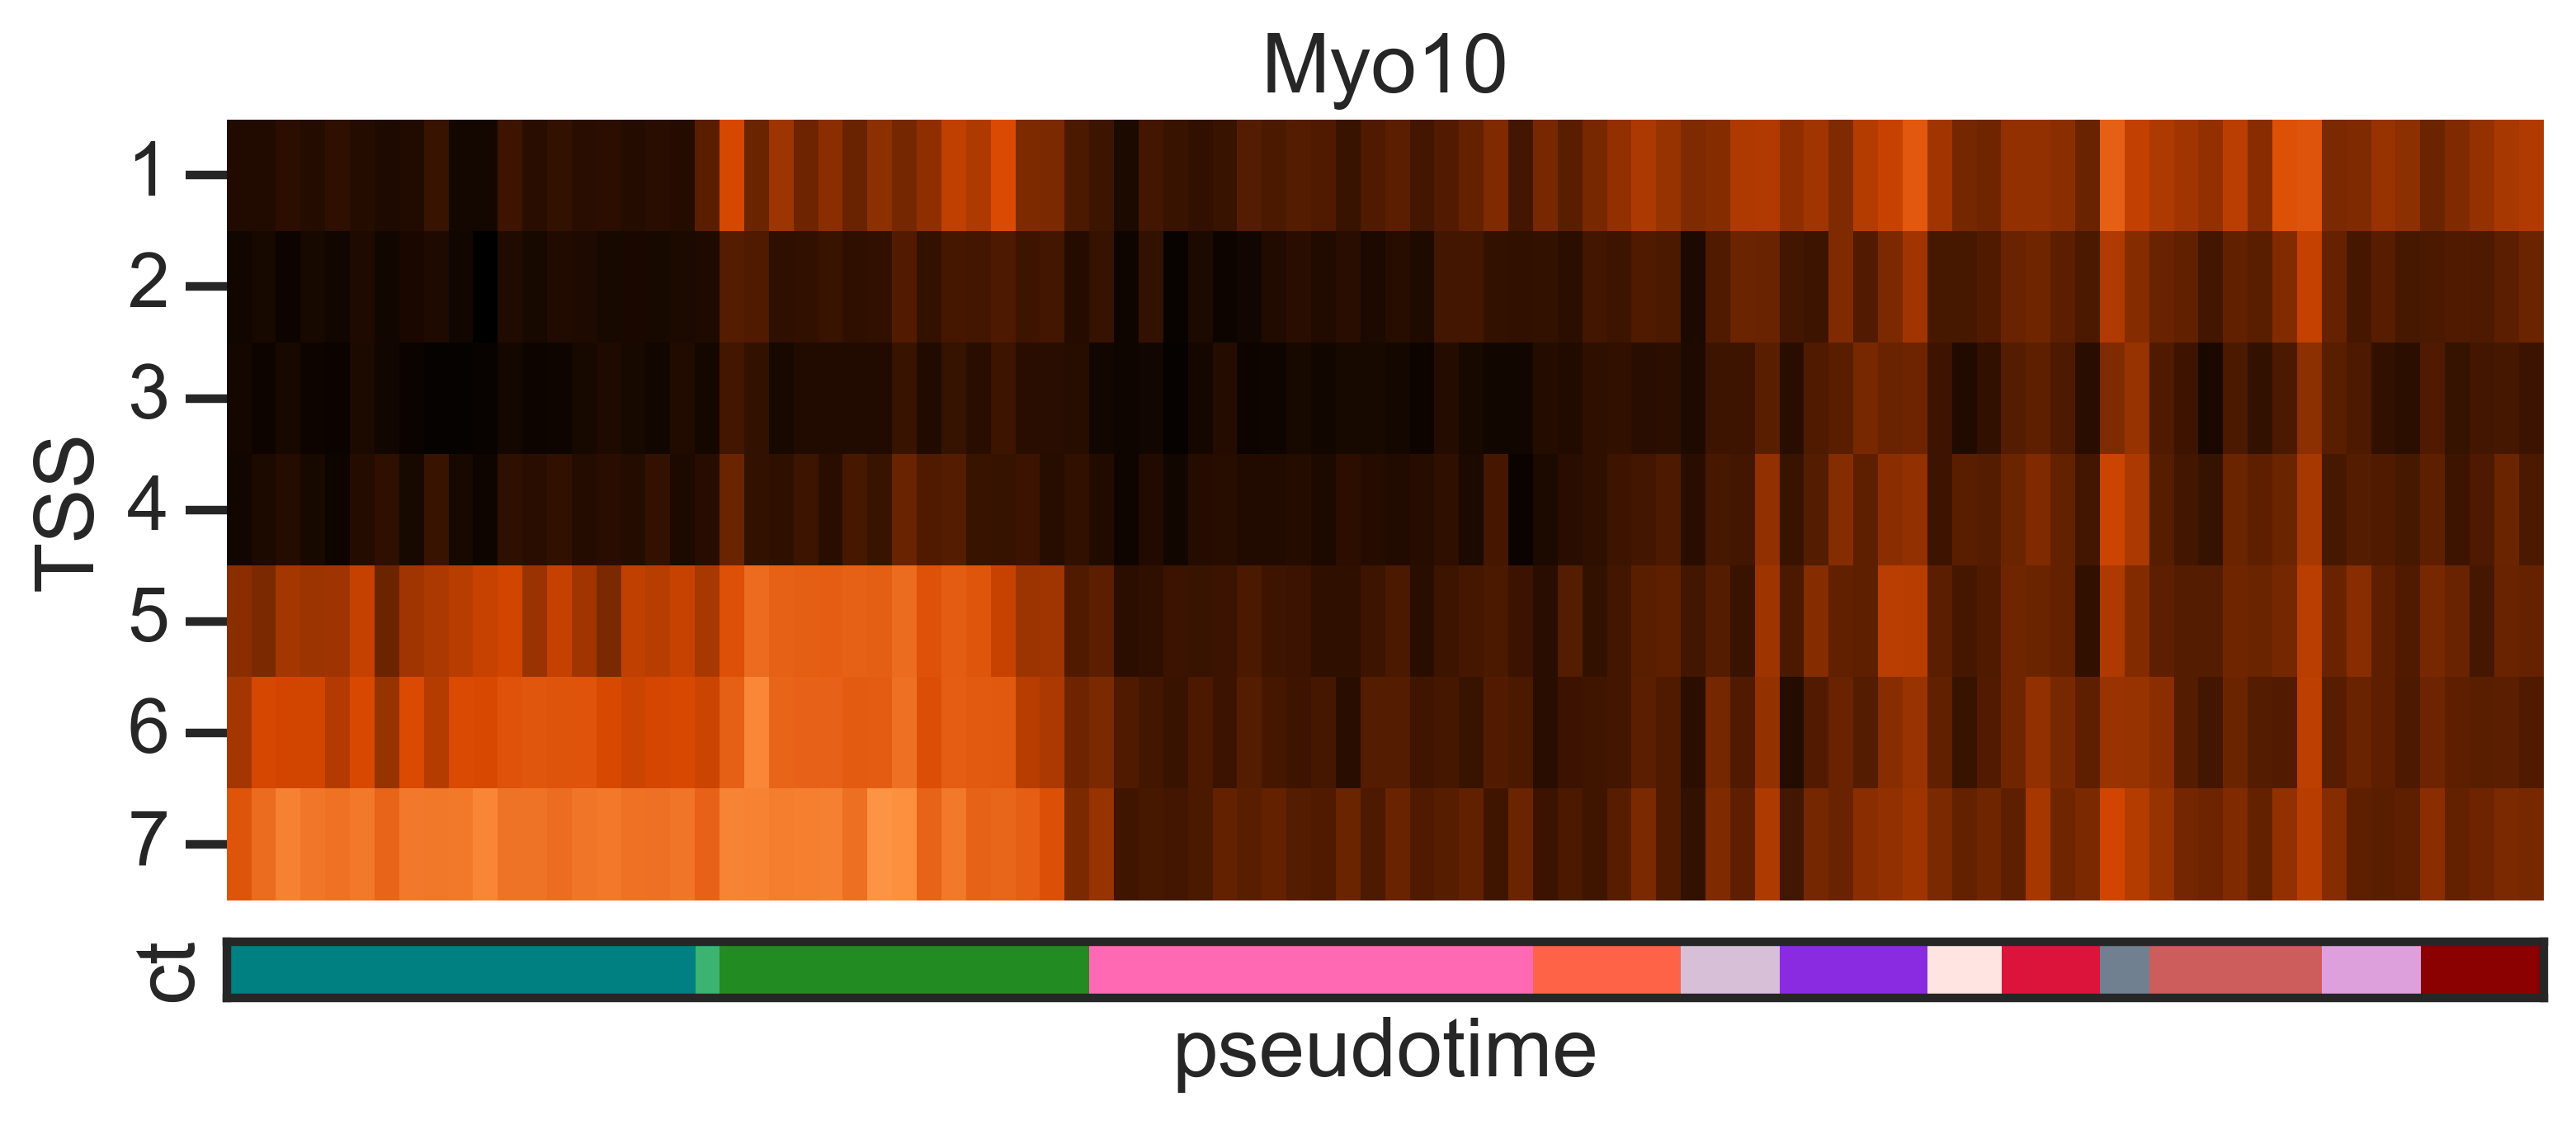

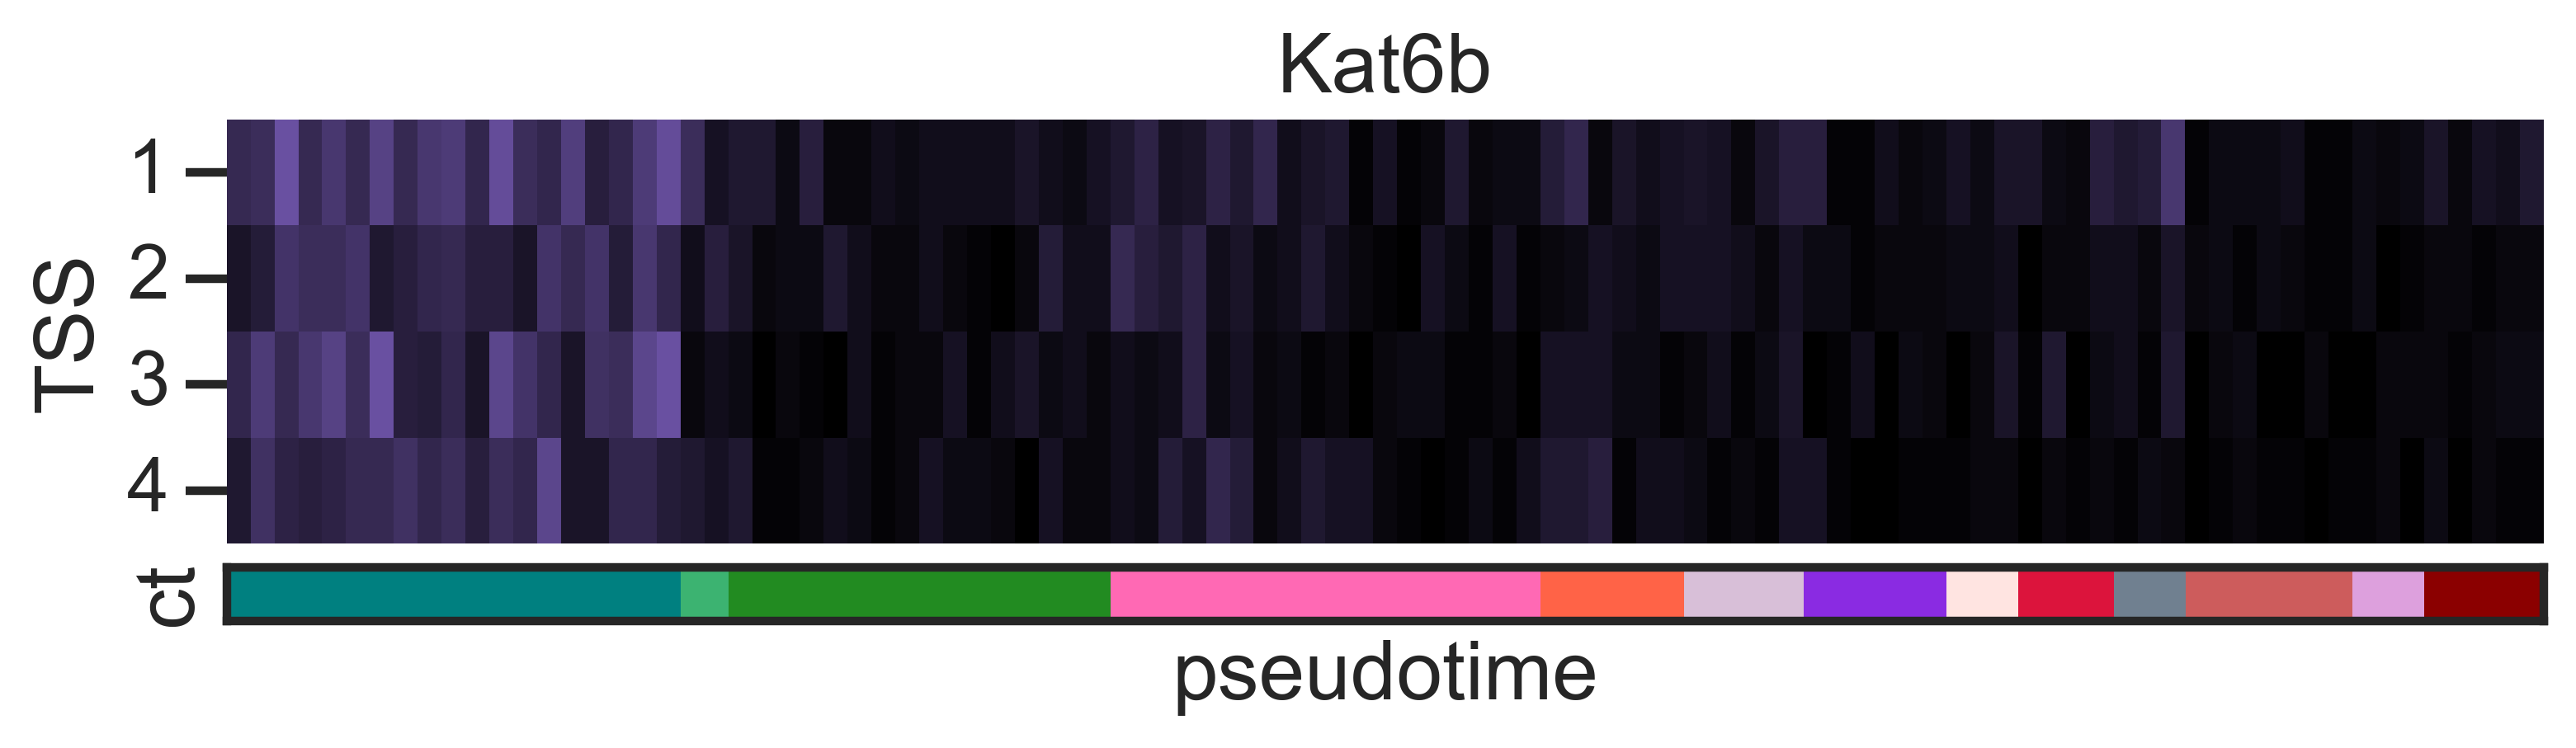

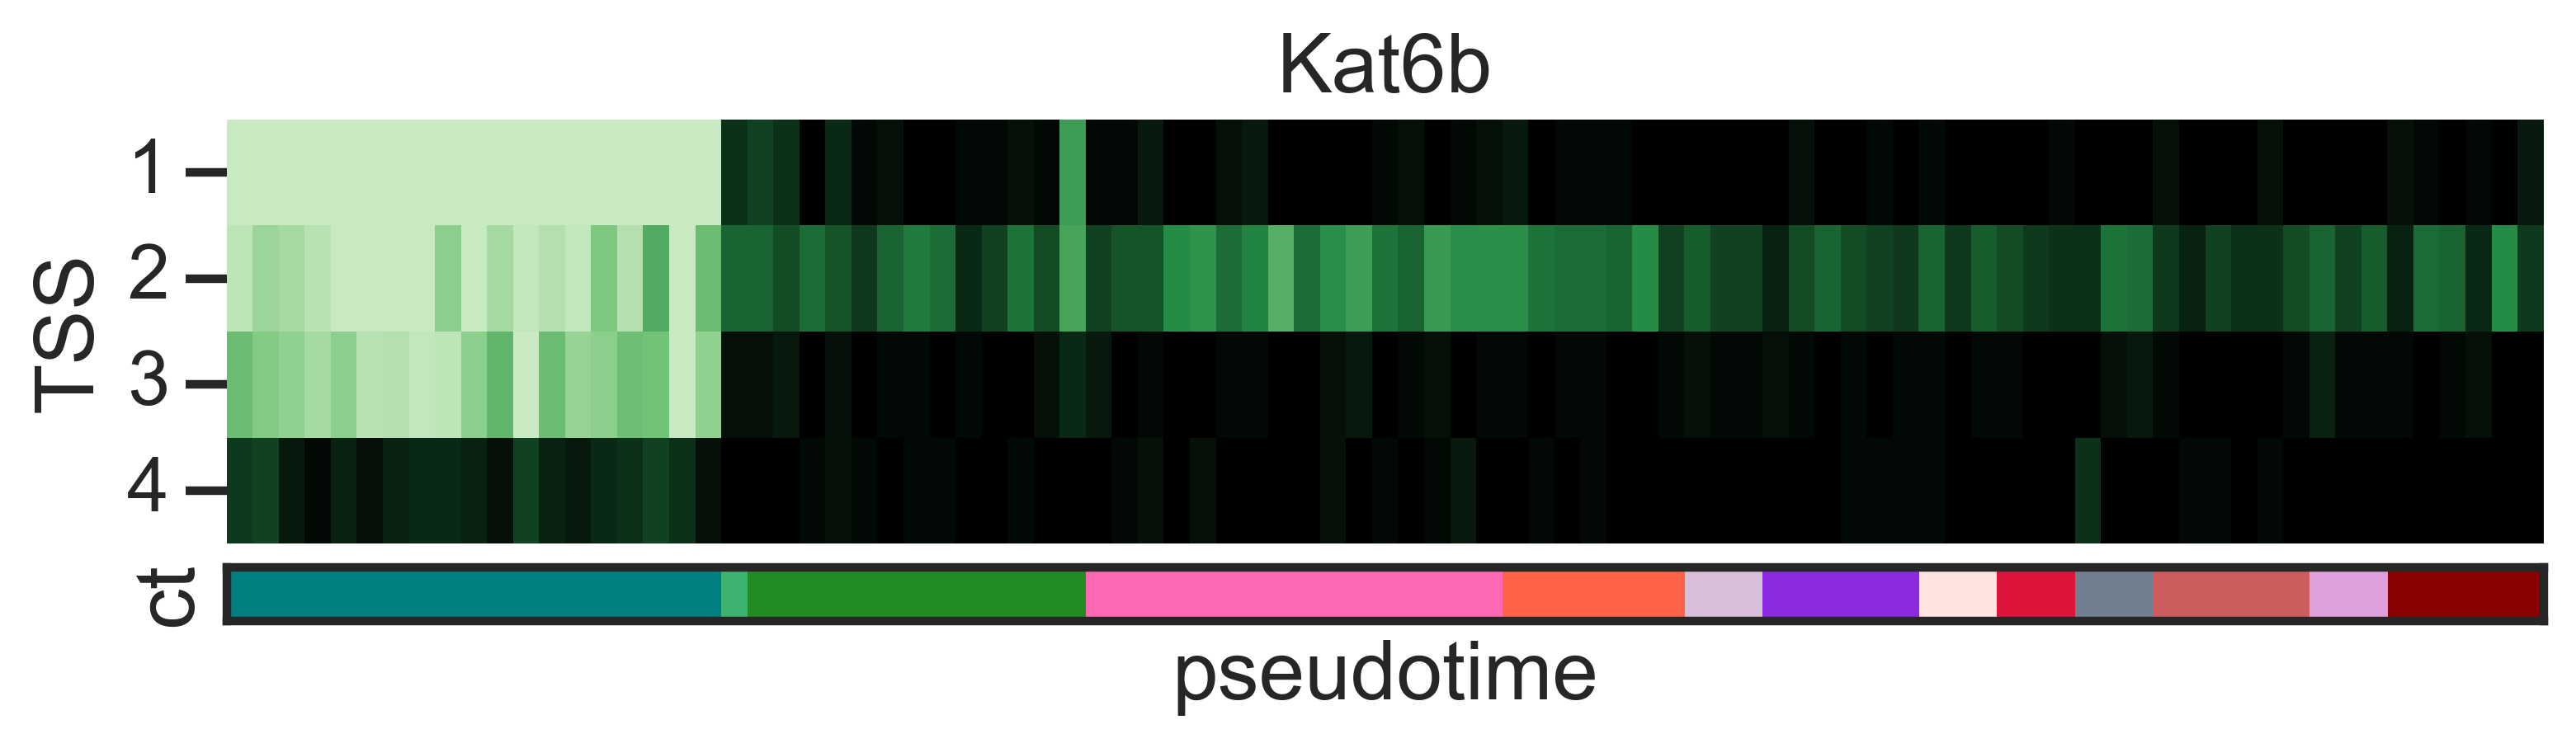

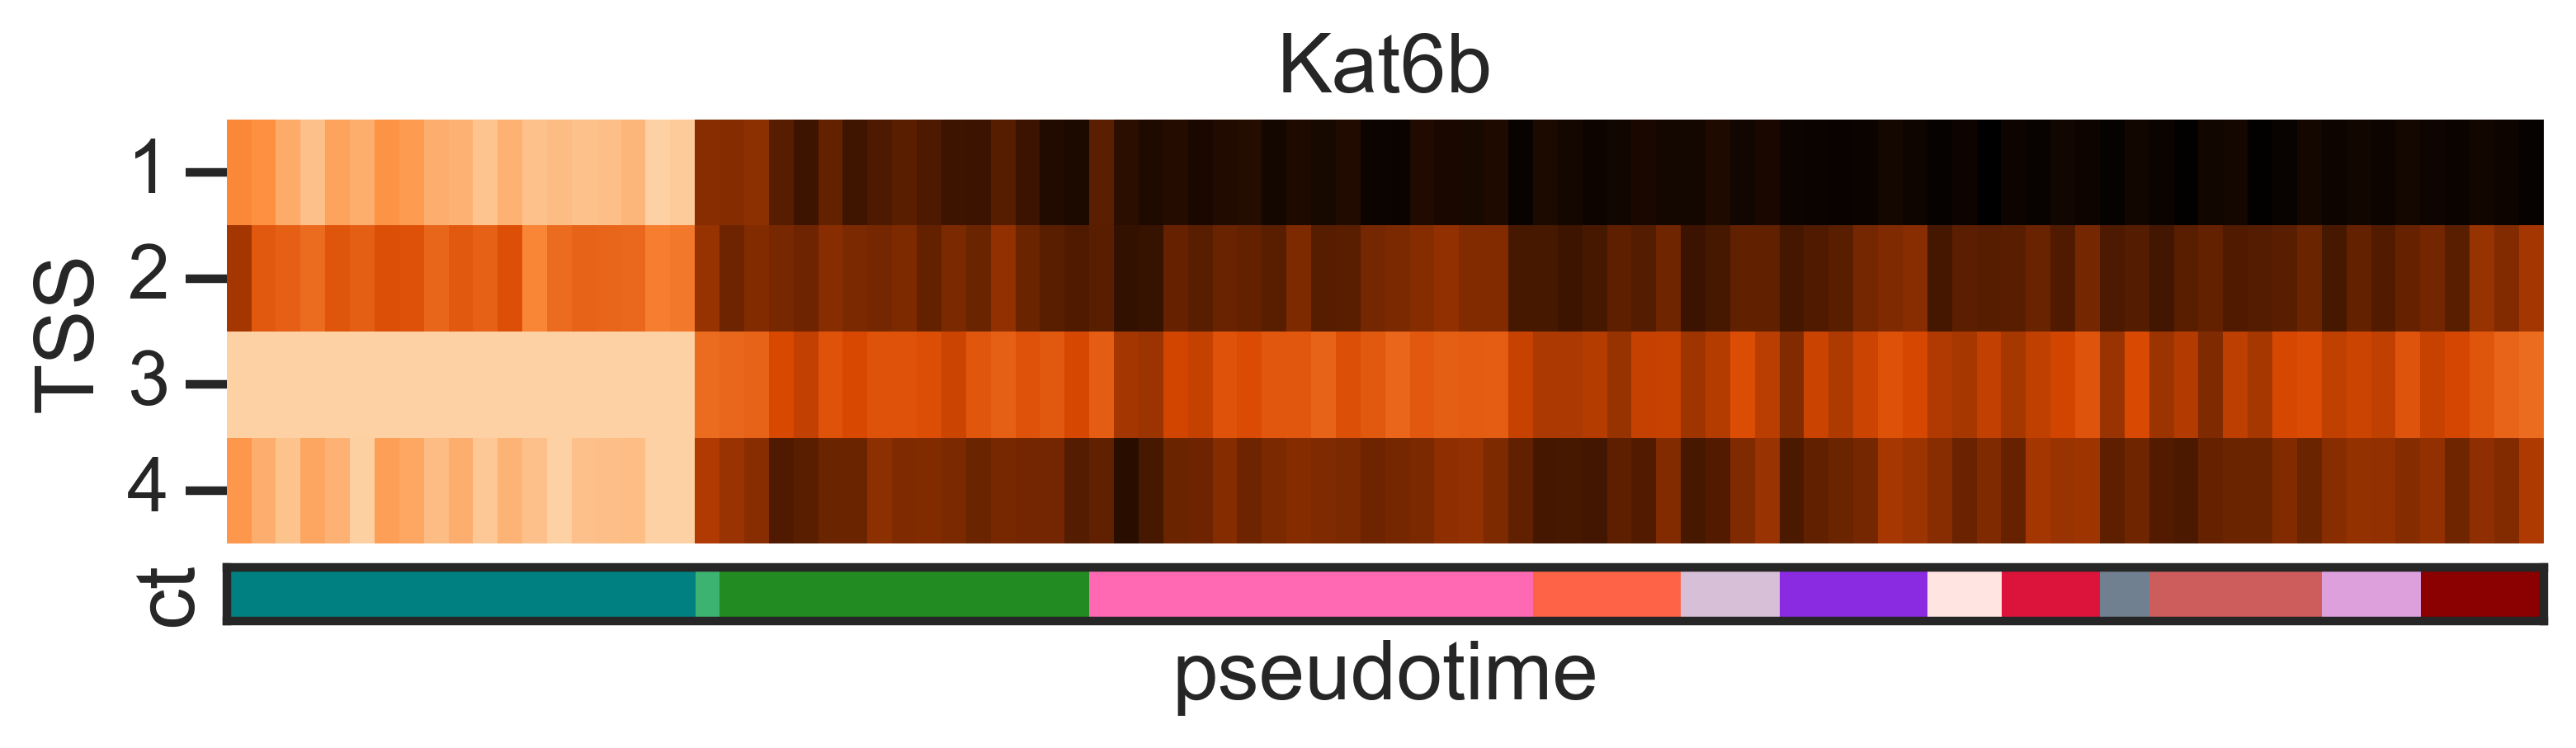

In [64]:
sc.set_figure_params(dpi=200)
sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

genes = ['Rbpj','Palld', 'Foxp1', 'Myo10','Kat6b']
lineages = ['Mesoderm']# 'Endoderm','Ectoderm']

for lin in lineages:
    print(lin)
    for gene in genes:
        makeHeatmap(df_k27, 
                    lin, [gene], filtering = False, palette = purples_r, vmax = 0.7)

        makeHeatmap(df_k4, 
                    lin, [gene], filtering = False, palette = greens_r, vmax = 0.5)

        makeHeatmap(df_rna, 
                    lin, [gene], filtering = False, palette = oranges_r, vmax = 2, steps = 200)


In [55]:
df_test = df_k4.copy()
df_test.index = df_test['lineage']
df_test = df_test.drop(columns=['pseudo','lineage'])

In [56]:
df_test = df_test.groupby('lineage').mean()
df_test.head(2)

gene        Dlgap1                                              Ank3  \
TSS              1         2         3         4         5         1   
lineage                                                                
Ectoderm  0.016768  0.005444  0.002395  0.000653  0.004573  0.027221   
Endoderm  0.004824  0.007581  0.005513  0.002757  0.004824  0.048932   

gene                                              ...     C2cd2            \
TSS              2         3         4         5  ...         1         2   
lineage                                           ...                       
Ectoderm  0.017204  0.004791  0.002613  0.004355  ...  0.040941  0.039852   
Endoderm  0.013094  0.003446  0.000689  0.002757  ...  0.051688  0.064783   

gene                                       Rcan1                      \
TSS              3         4         5         1         2         3   
lineage                                                                
Ectoderm  0.002178  0.002395  0.003049  0.030706  0.007622  0.014591   
Endoderm  0.005513  0.001378  0.006892  0.039283  0.006892  0.086147   

gene      Prickle1            
TSS              1         2  
lineage                       
Ectoderm  0.054443  0.091246  
Endoderm  0.052378  0.140593  

[2 rows x 525 columns]

In [57]:
df_test = df_test.loc[['Pluripotent','Ectoderm','Mesoderm','Endoderm']]

In [58]:
df_test2 = df_k27.copy()
df_test2.index = df_test2['lineage']
df_test2 = df_test2.drop(columns=['pseudo','lineage'])
df_test2 = df_test2.groupby('lineage').mean()
df_test2 = df_test2.loc[['Pluripotent','Ectoderm','Mesoderm','Endoderm']]

In [59]:
df_test3 = df_rna.copy()
df_test3.index = df_test3['lineage']
df_test3 = df_test3.drop(columns=['pseudo','lineage'])
df_test3 = df_test3.groupby('lineage').mean()
df_test3 = df_test3.loc[['Pluripotent','Ectoderm','Mesoderm','Endoderm']]

In [65]:
genes = ['Rbpj','Foxp1', 'Palld','Myo10'] #'Aff1','Zfp516','Myo10','Kat6b','Baz2b',

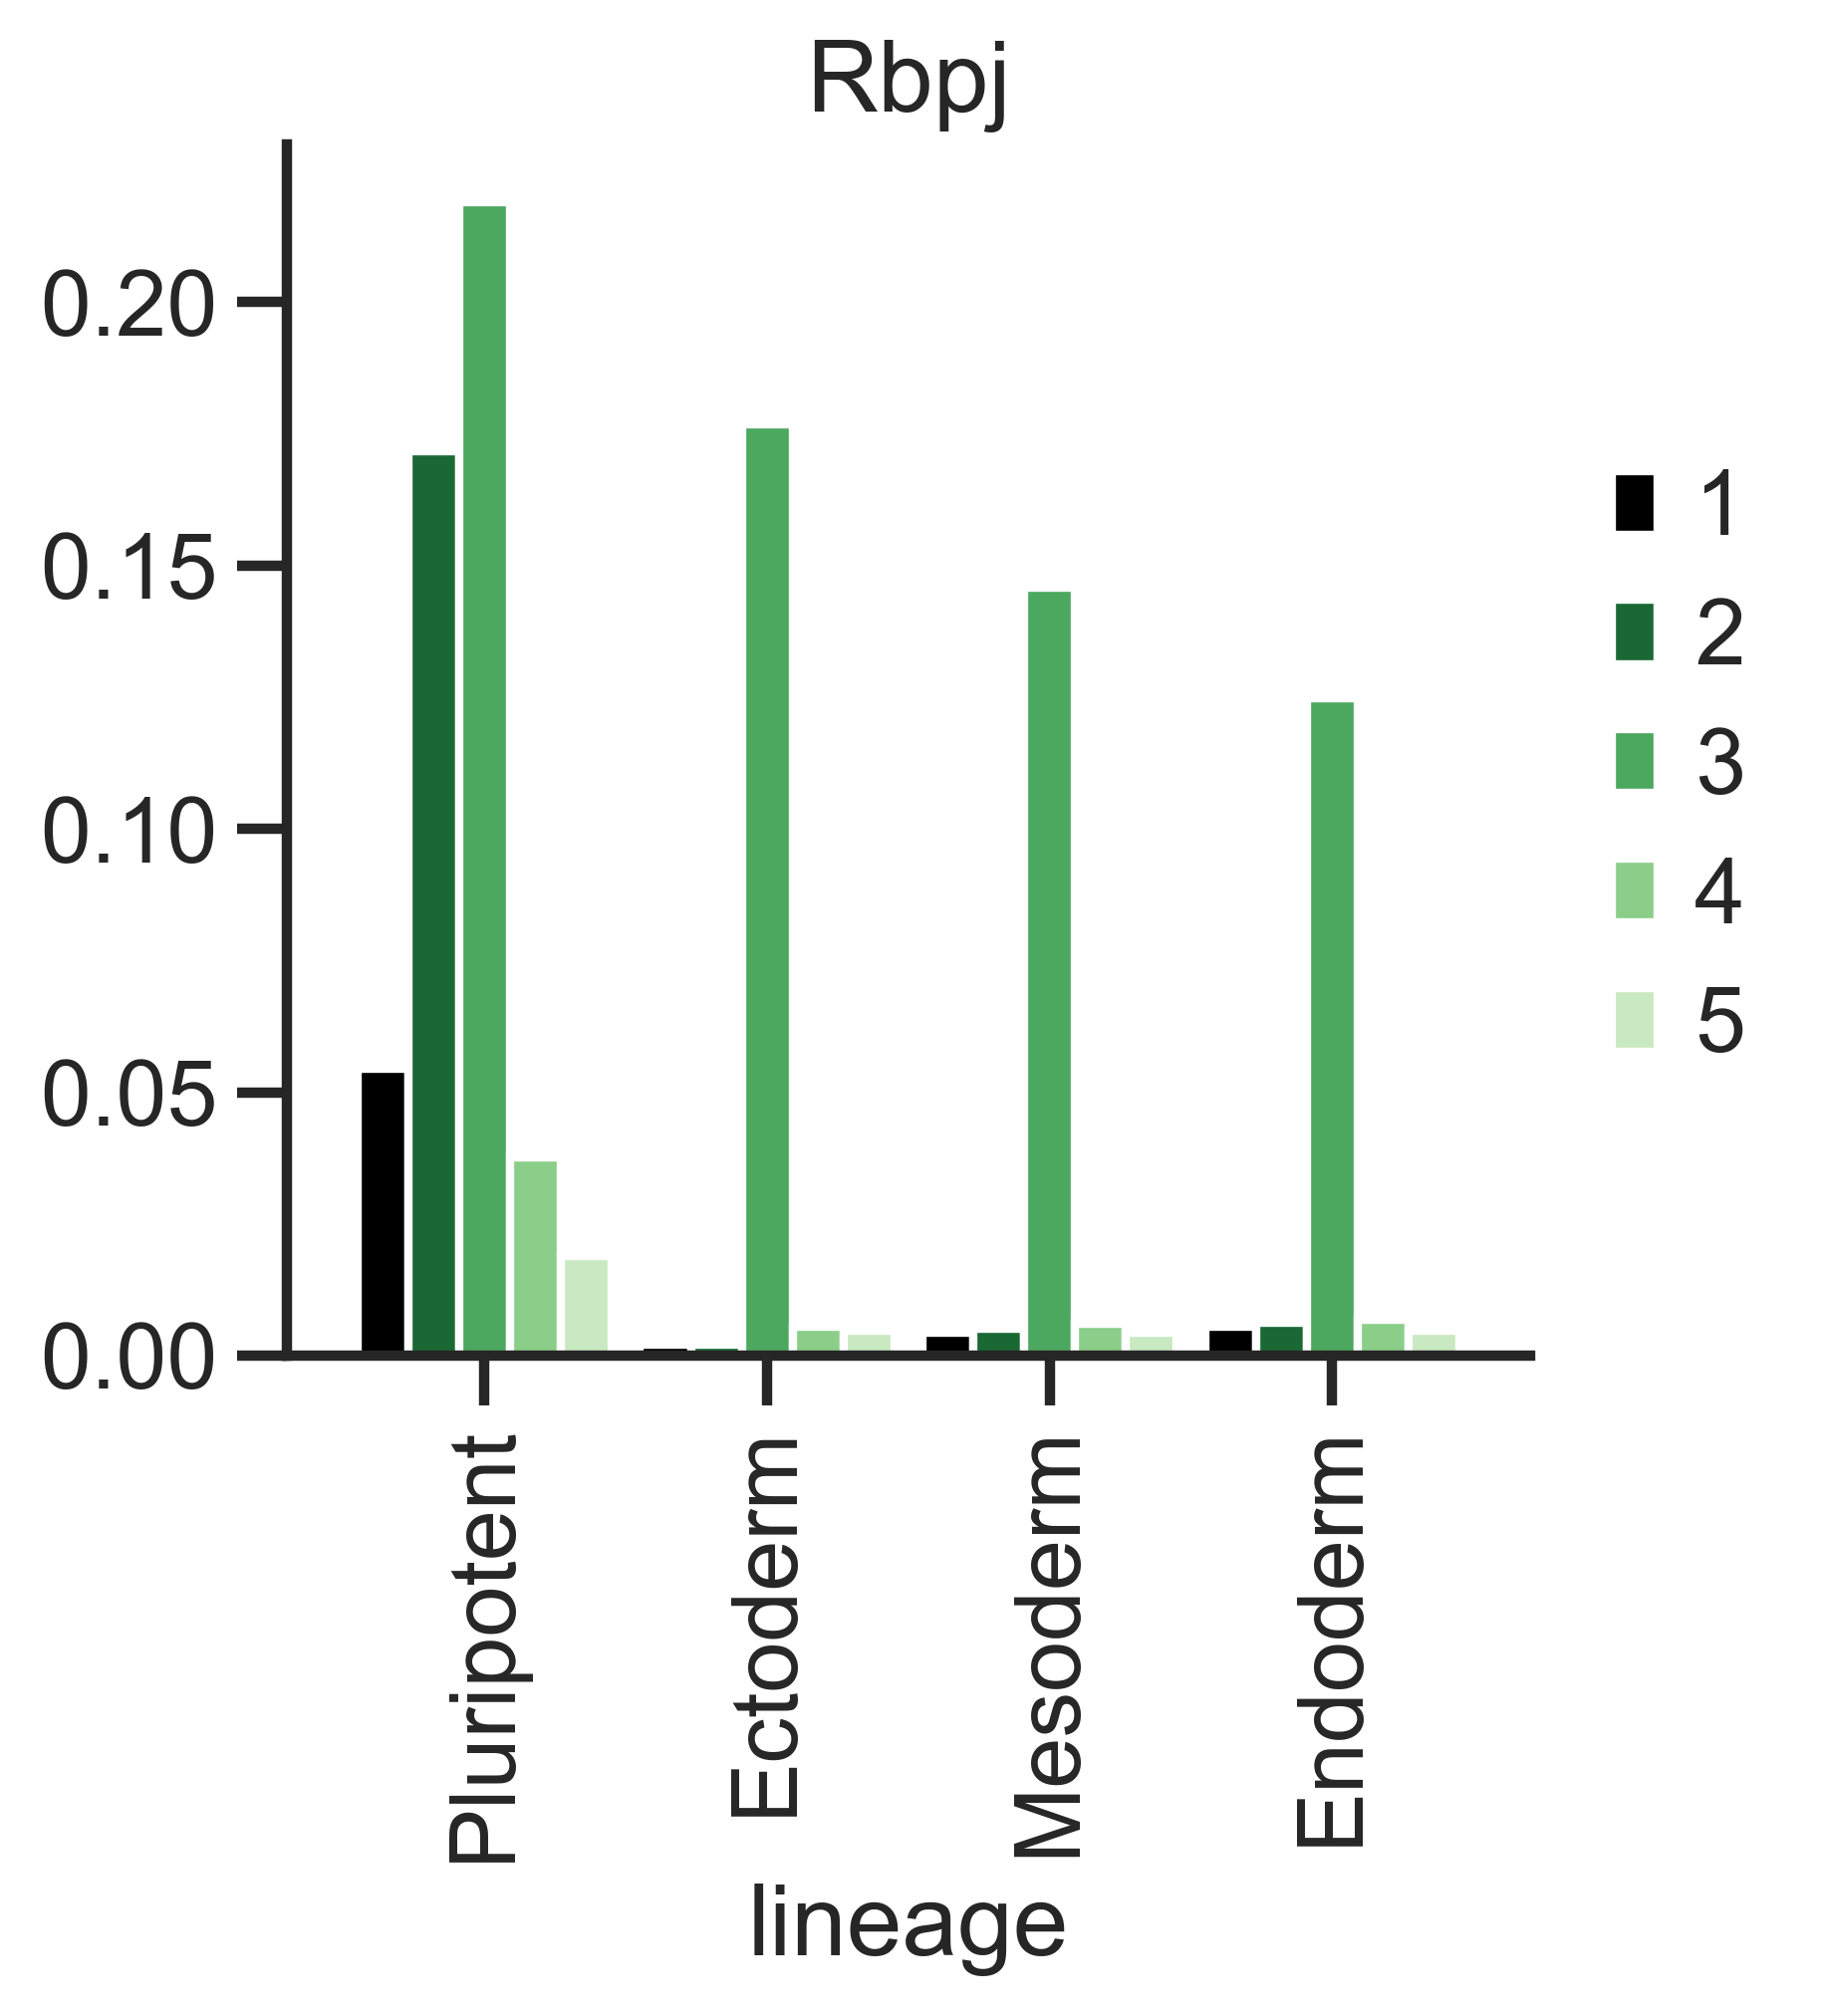

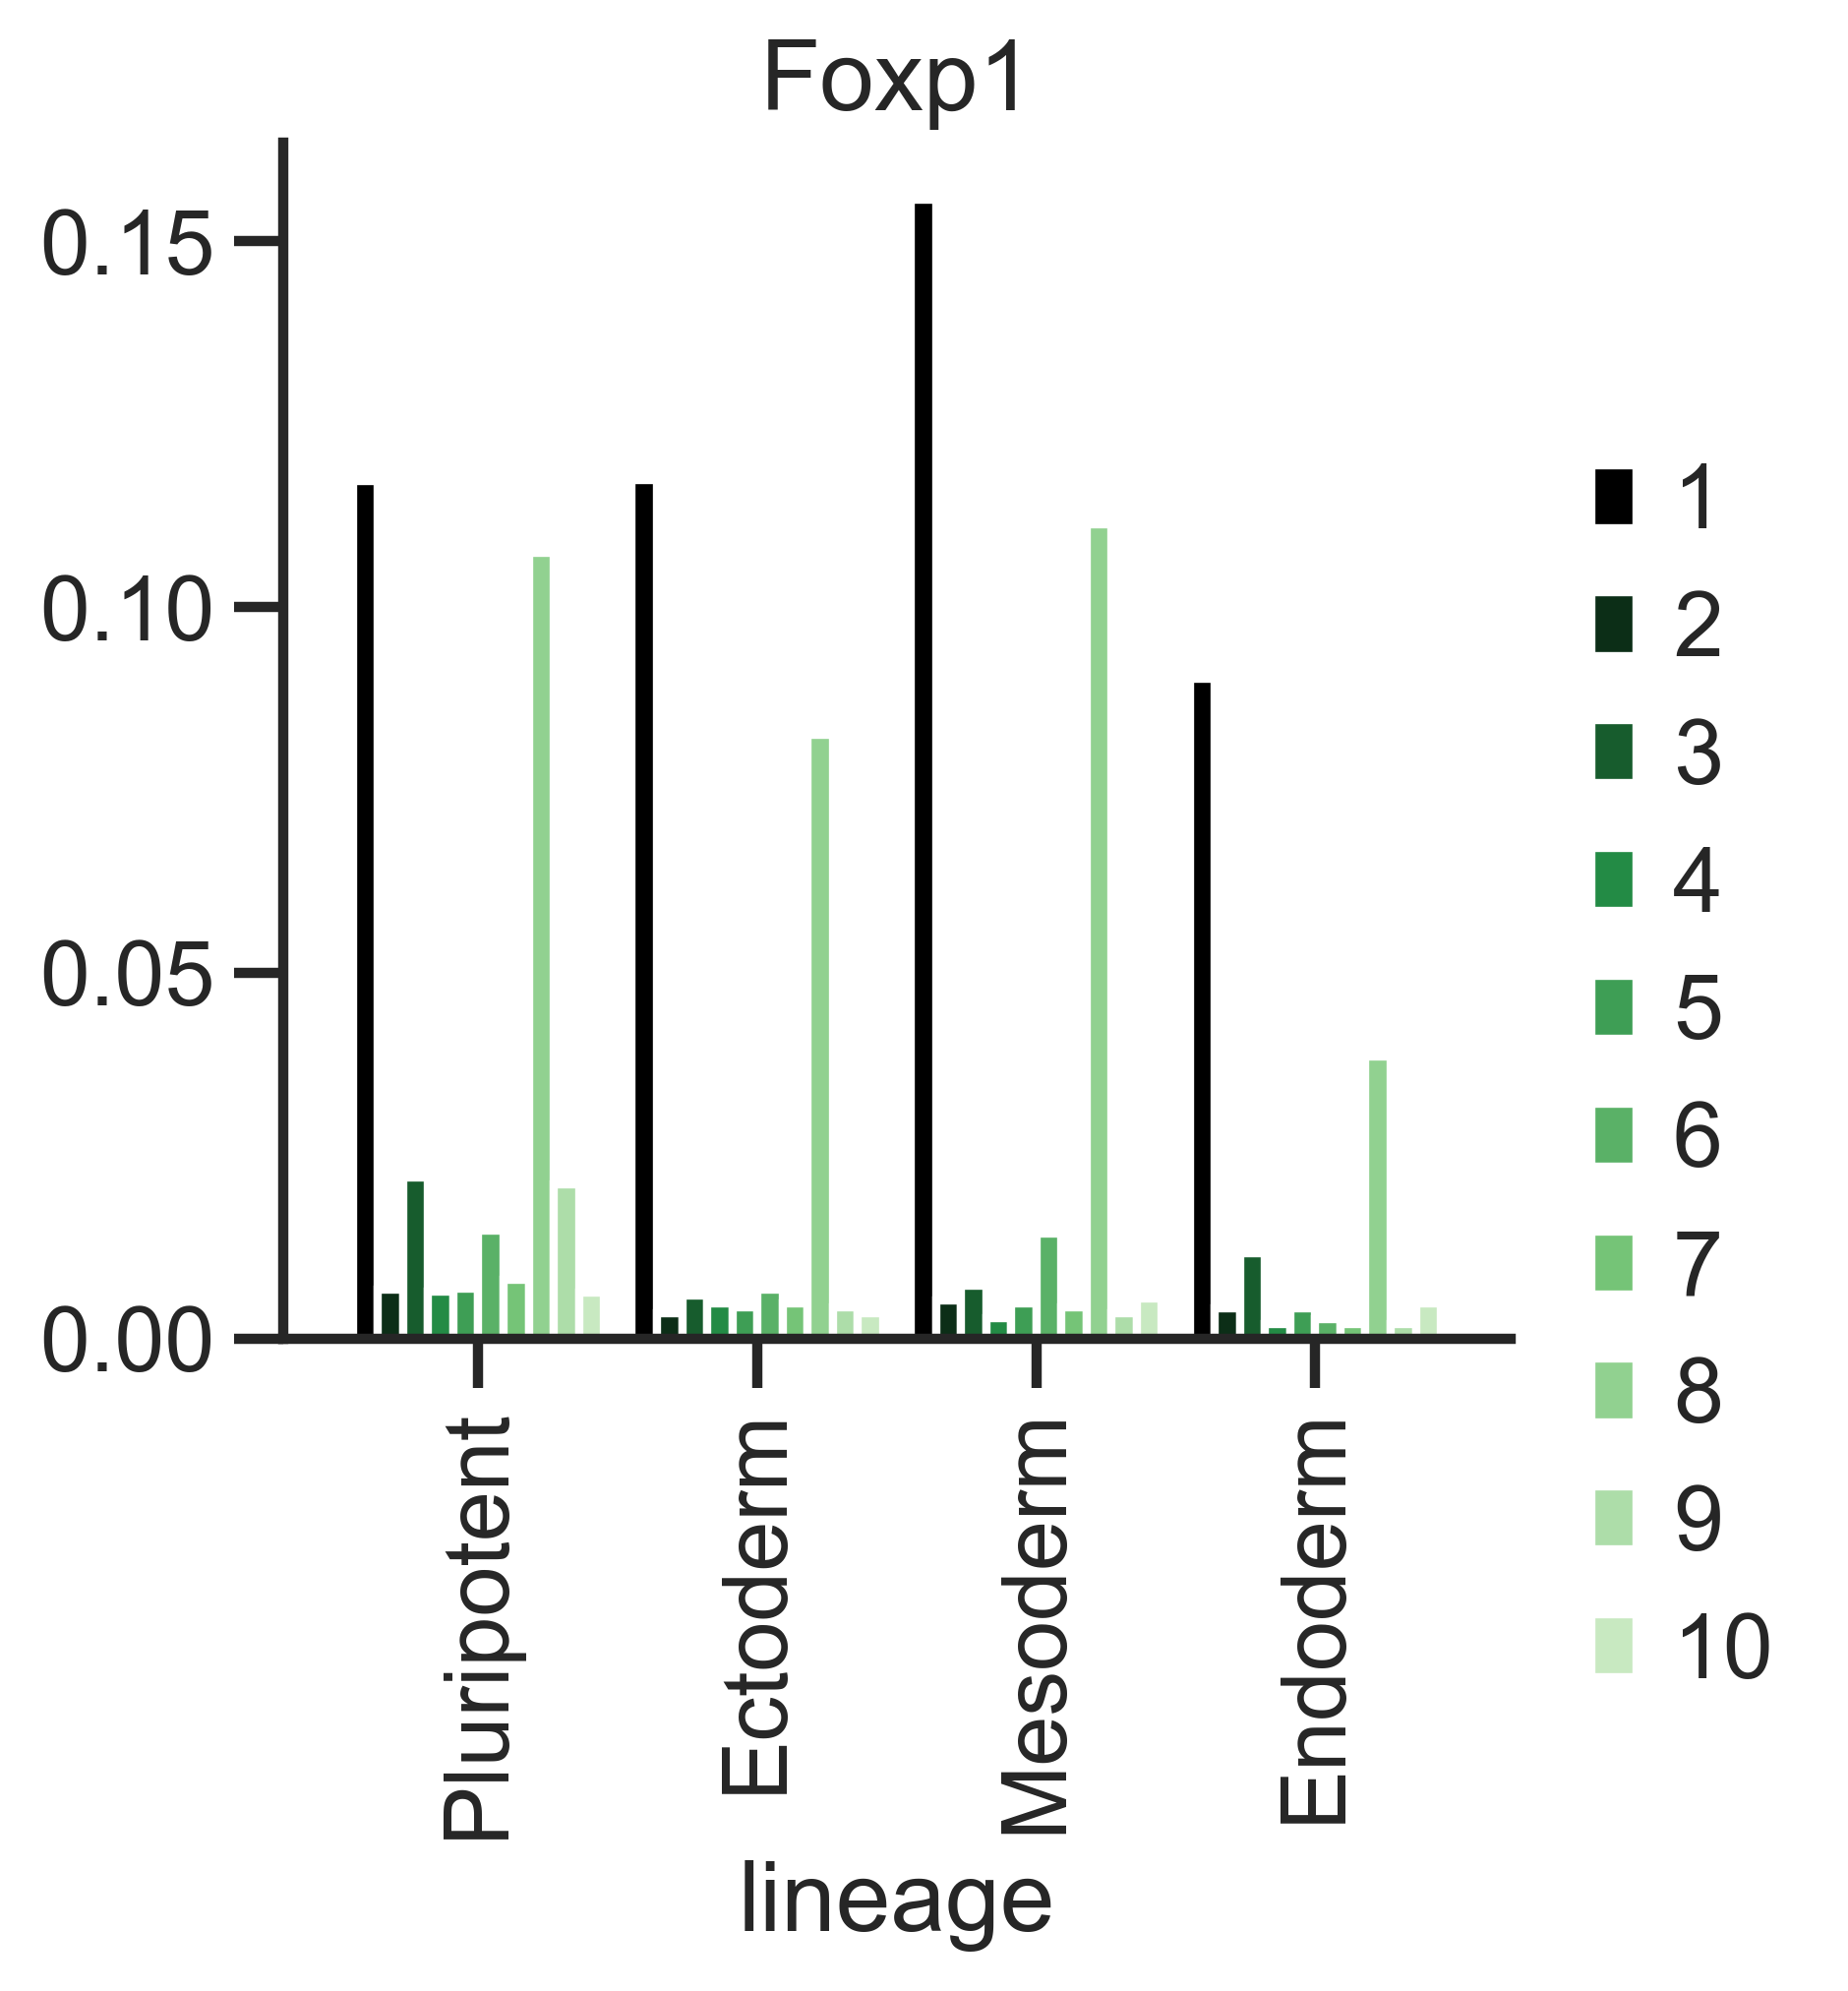

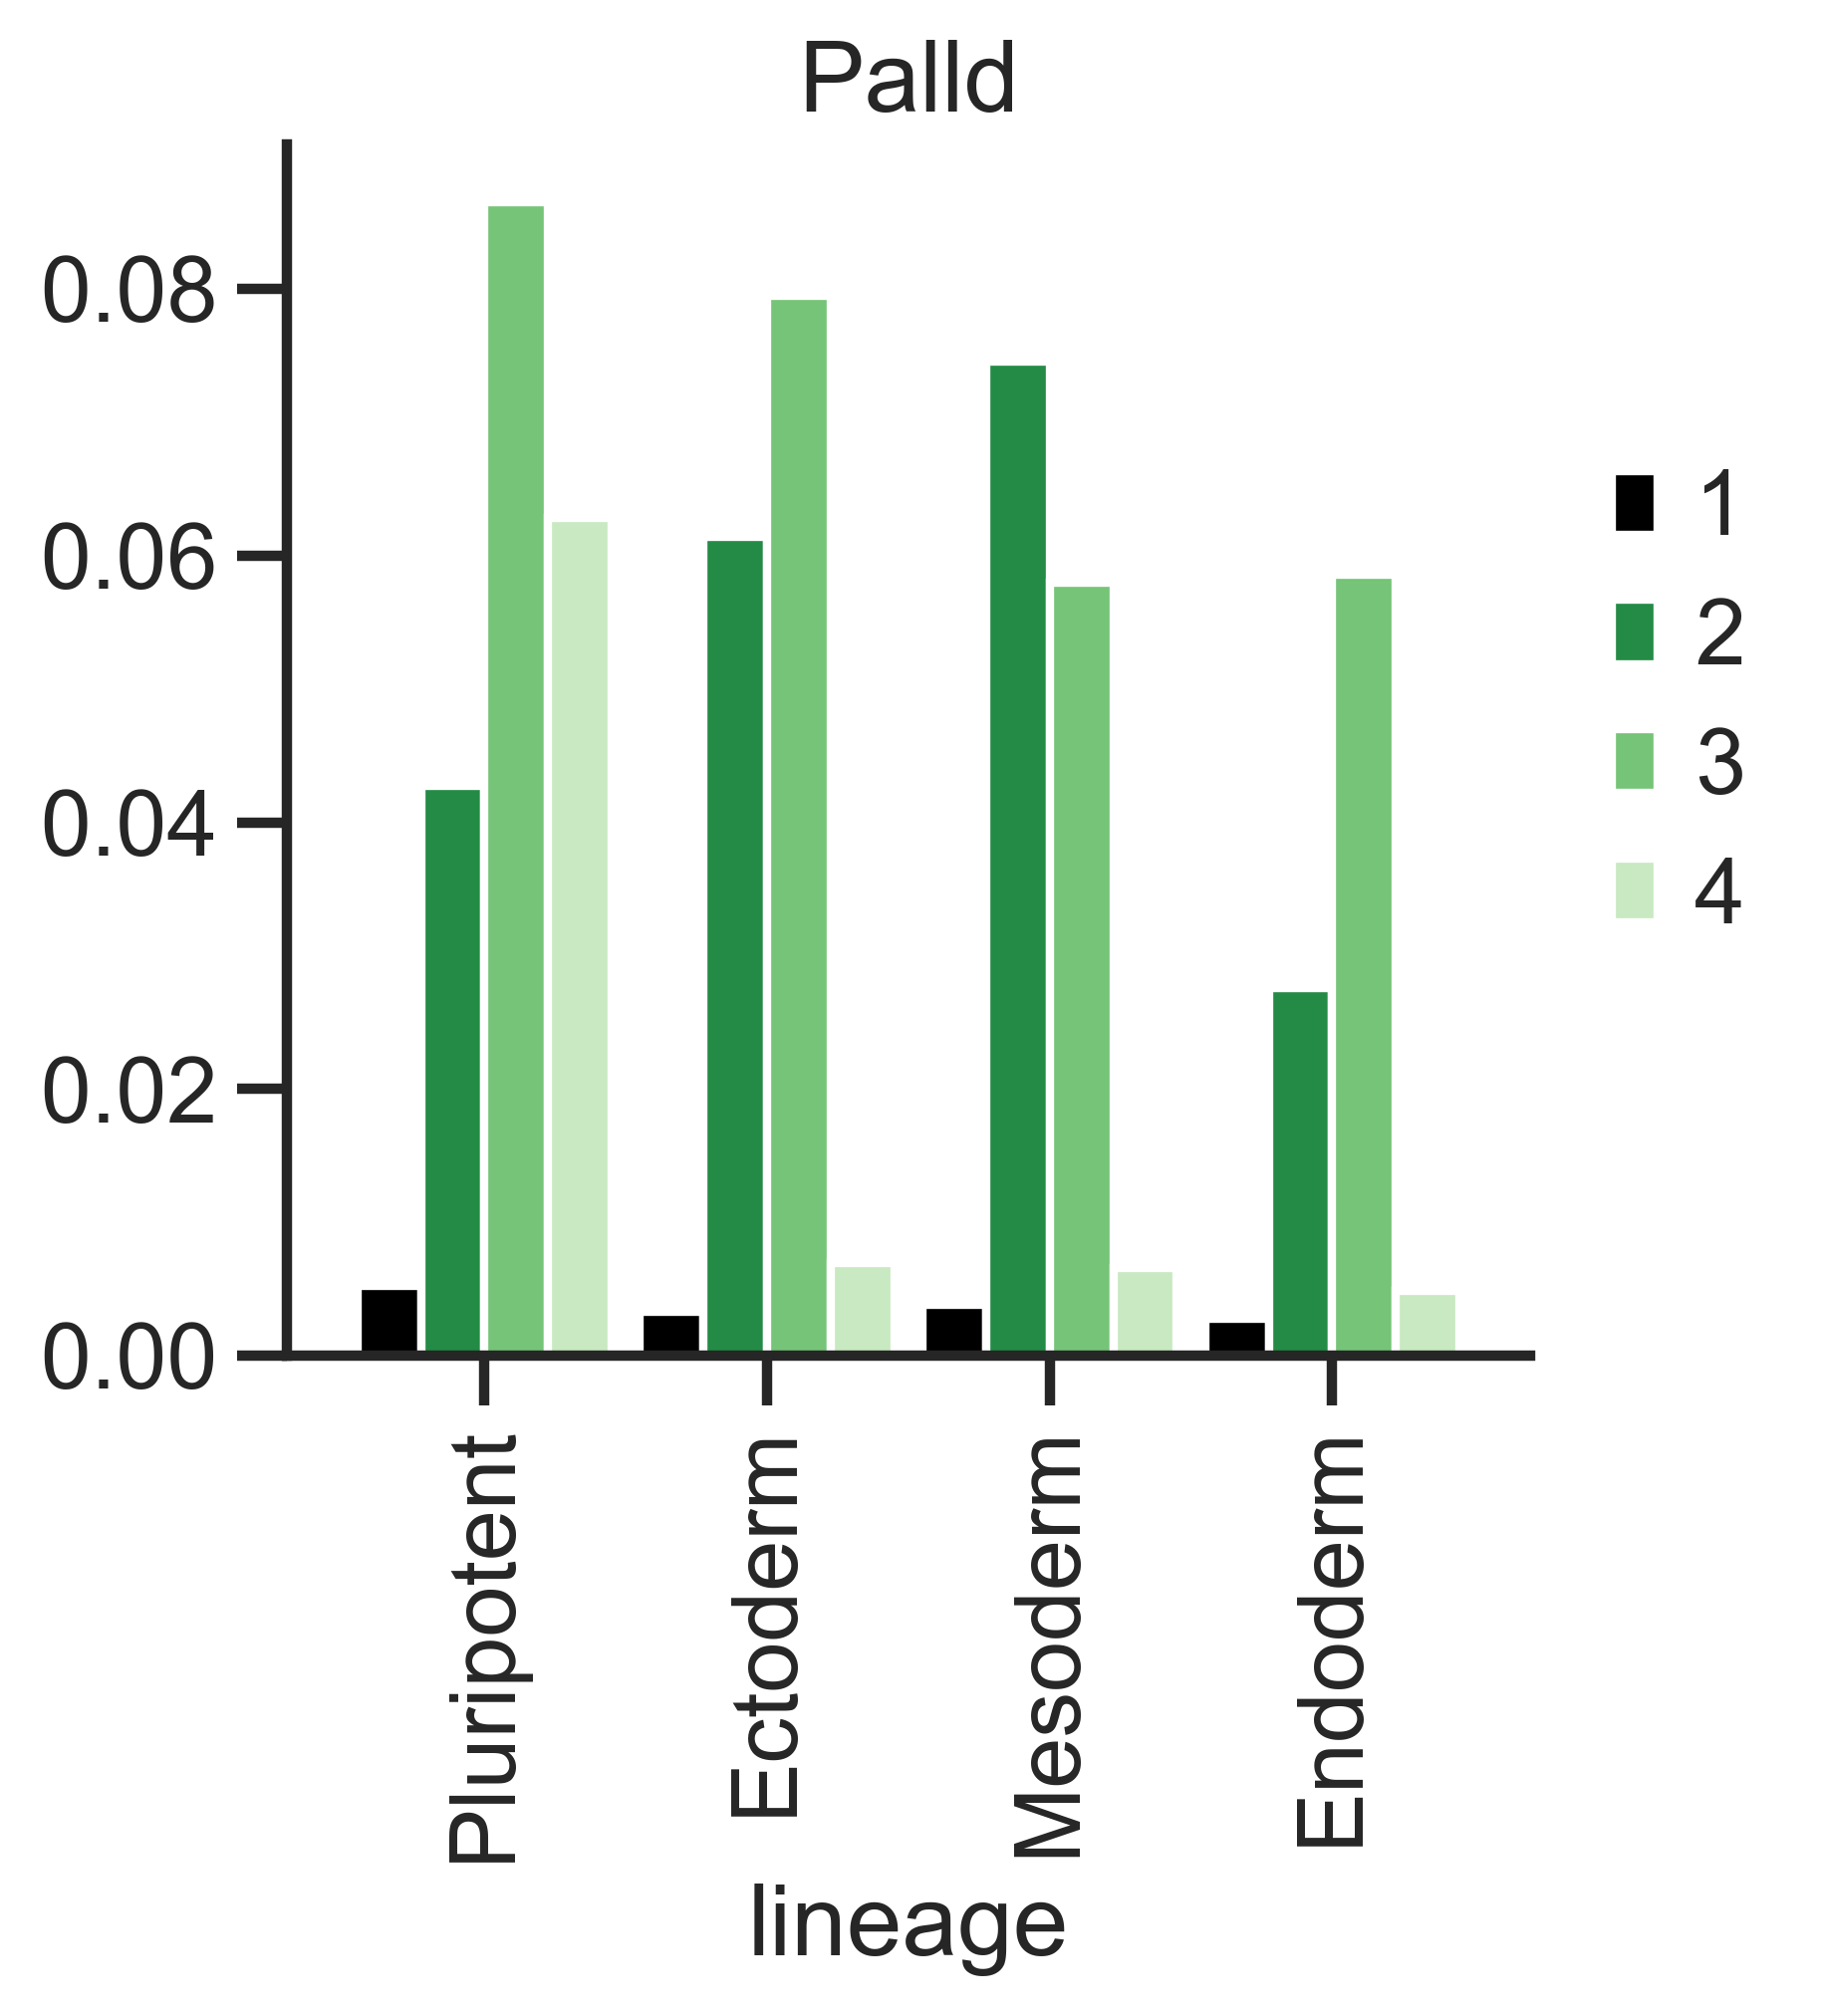

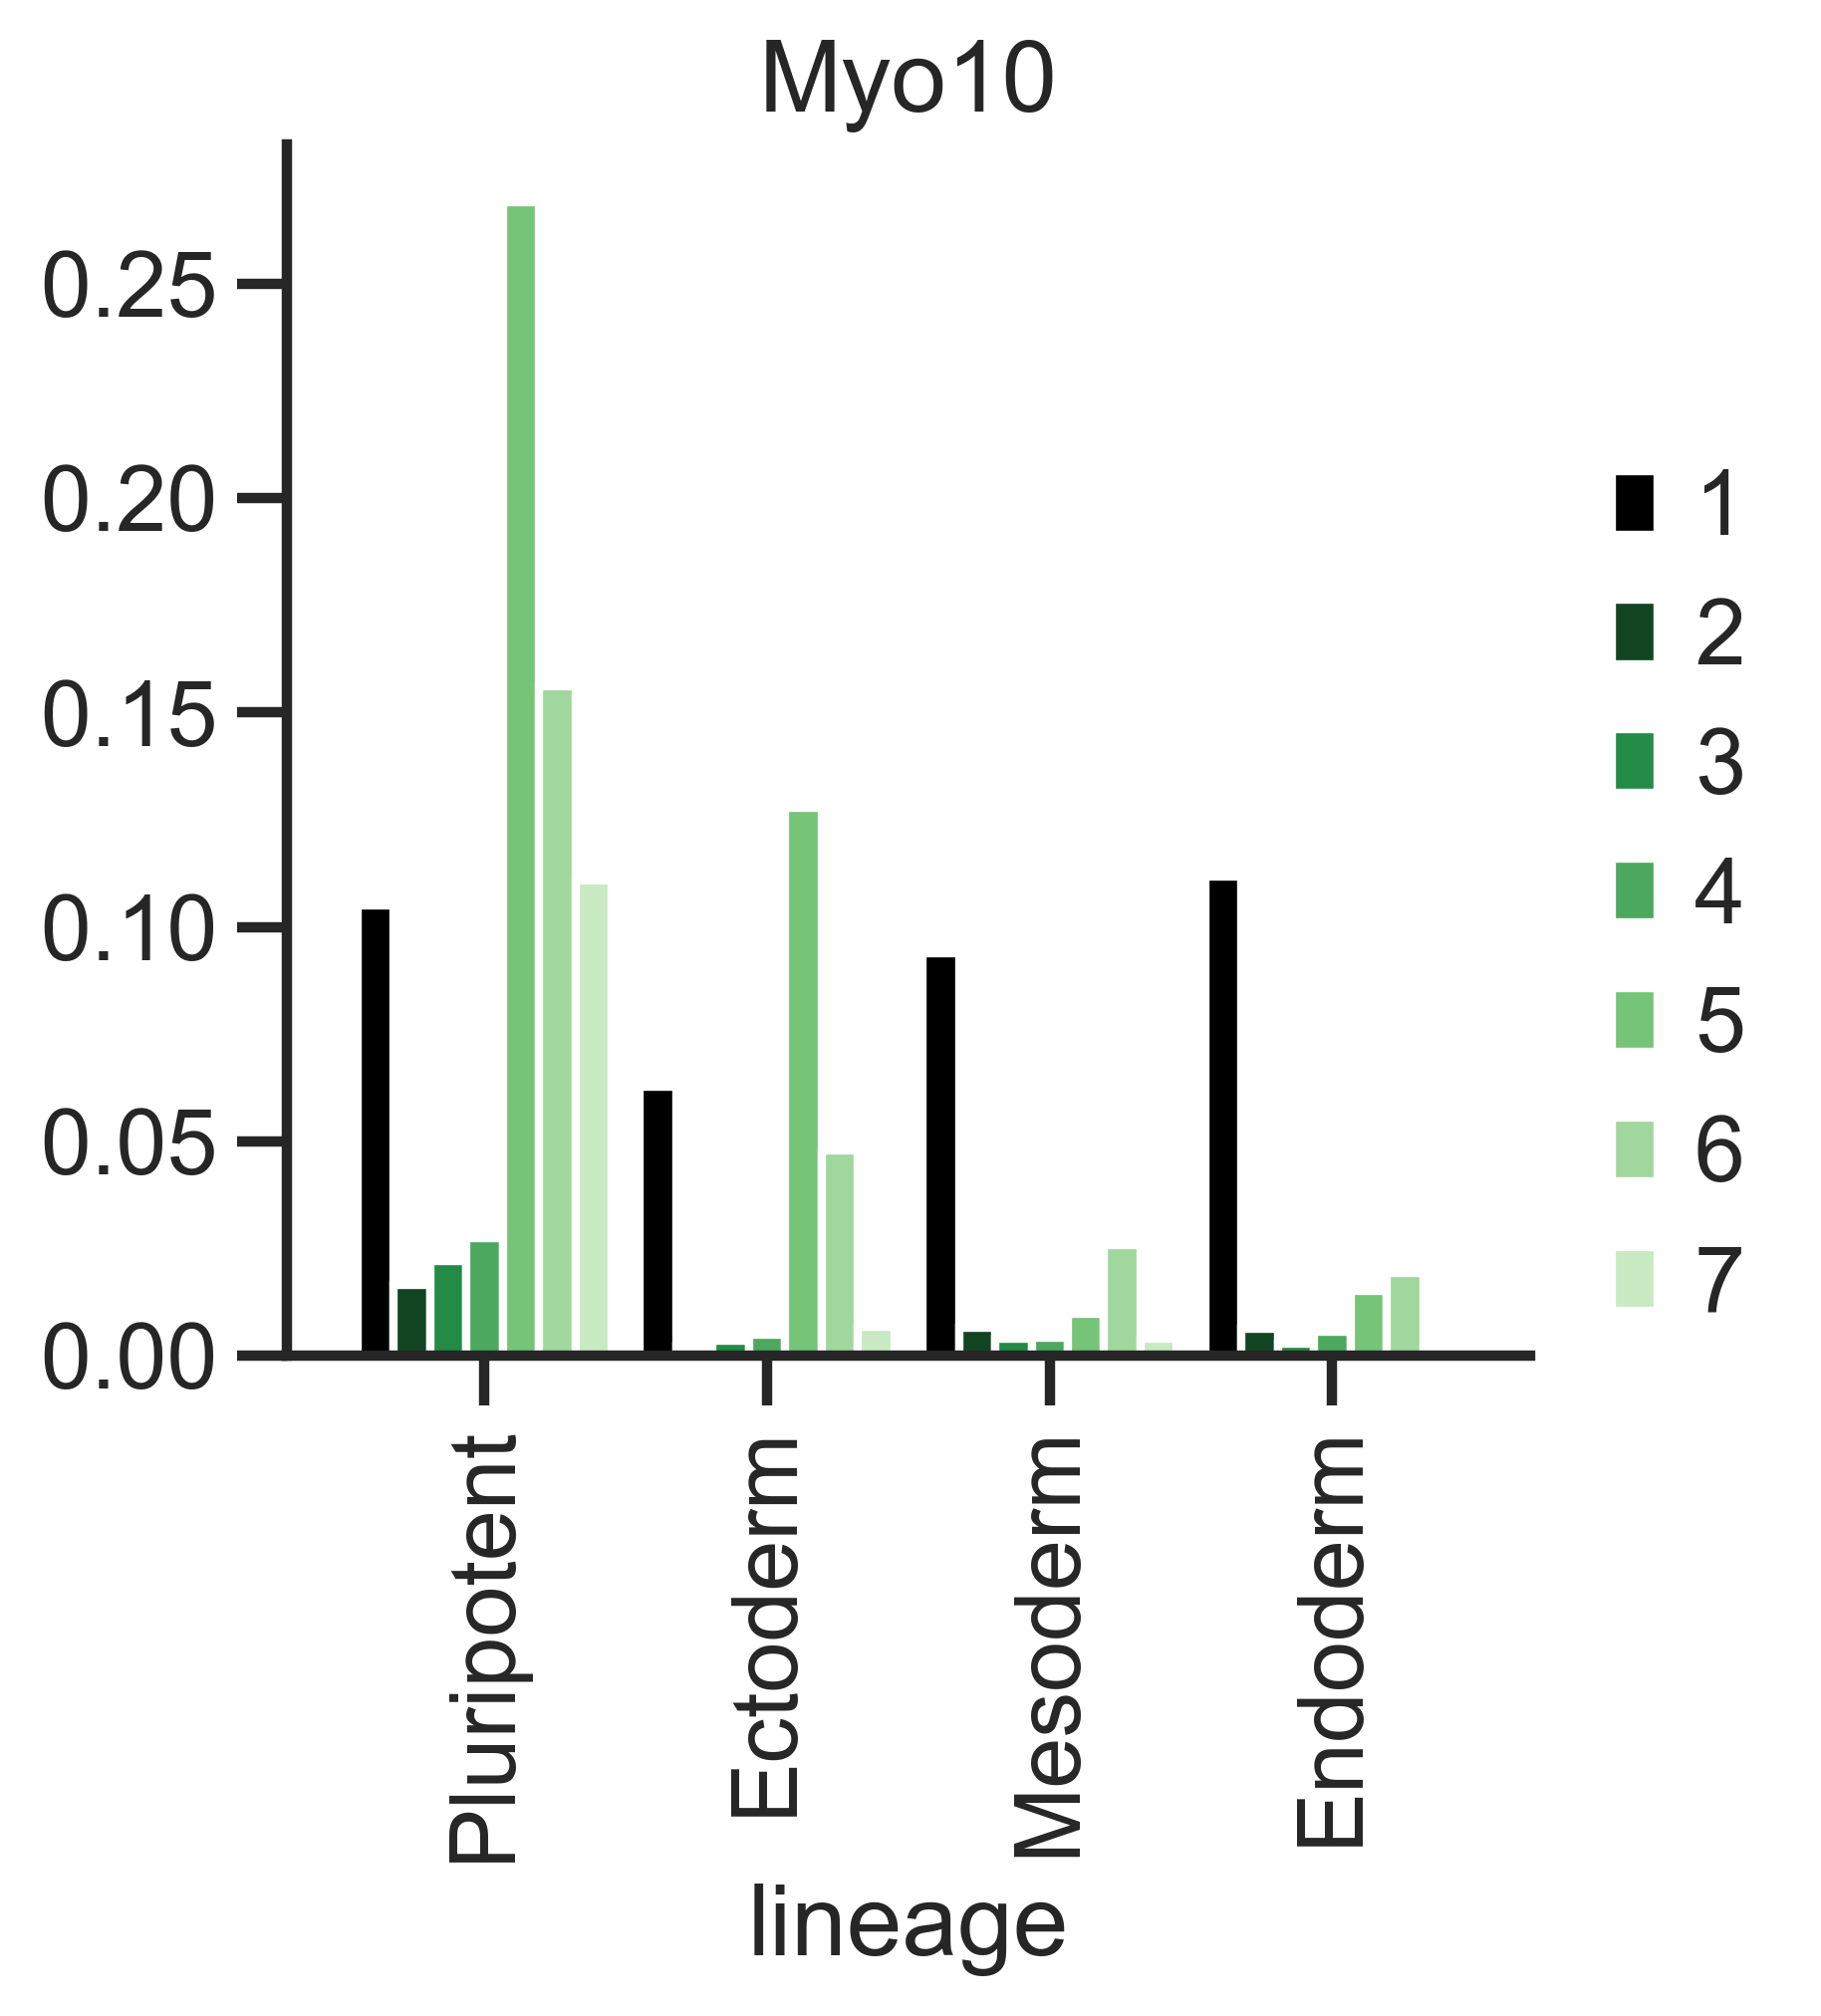

In [66]:
for gene in genes:
    df_test[gene].plot.bar(stacked=False,width = 0.9, figsize = (4,4),
                    cmap = greens_r,)
    #plt.yscale('log')
    plt.legend(bbox_to_anchor=(1,0.8),frameon=False)
    plt.title(gene)
    sns.despine()
    plt.show()

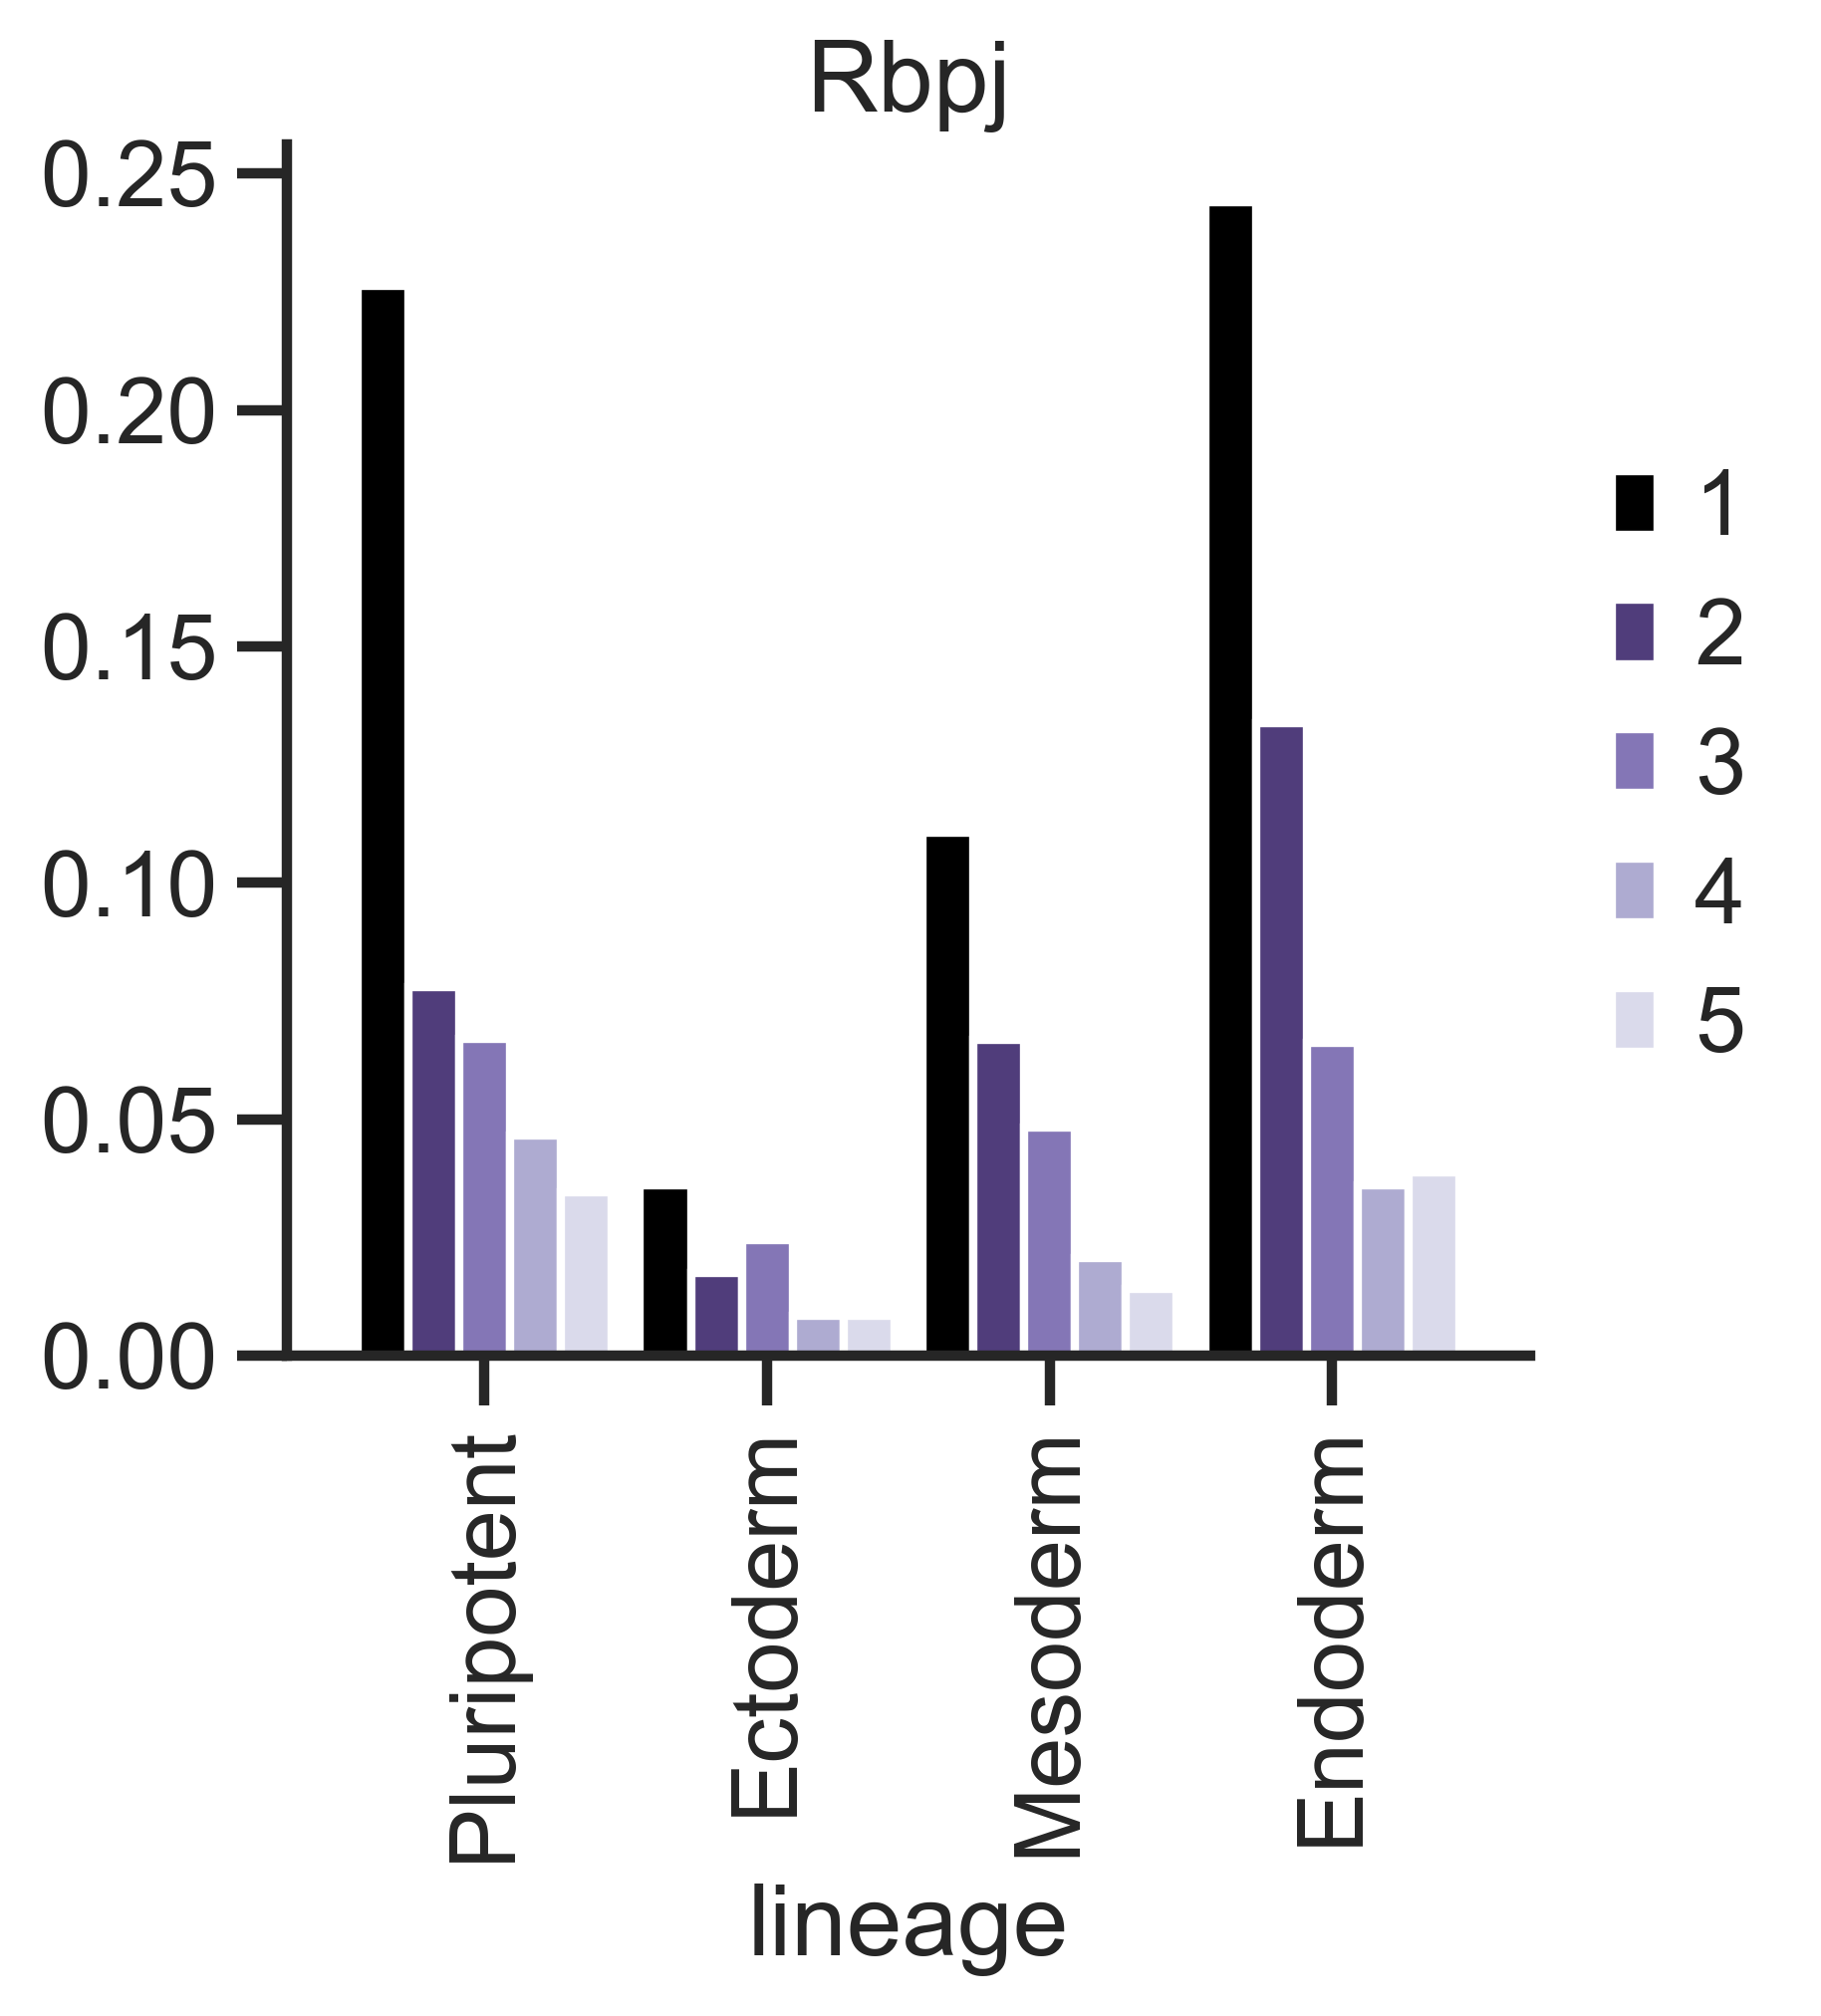

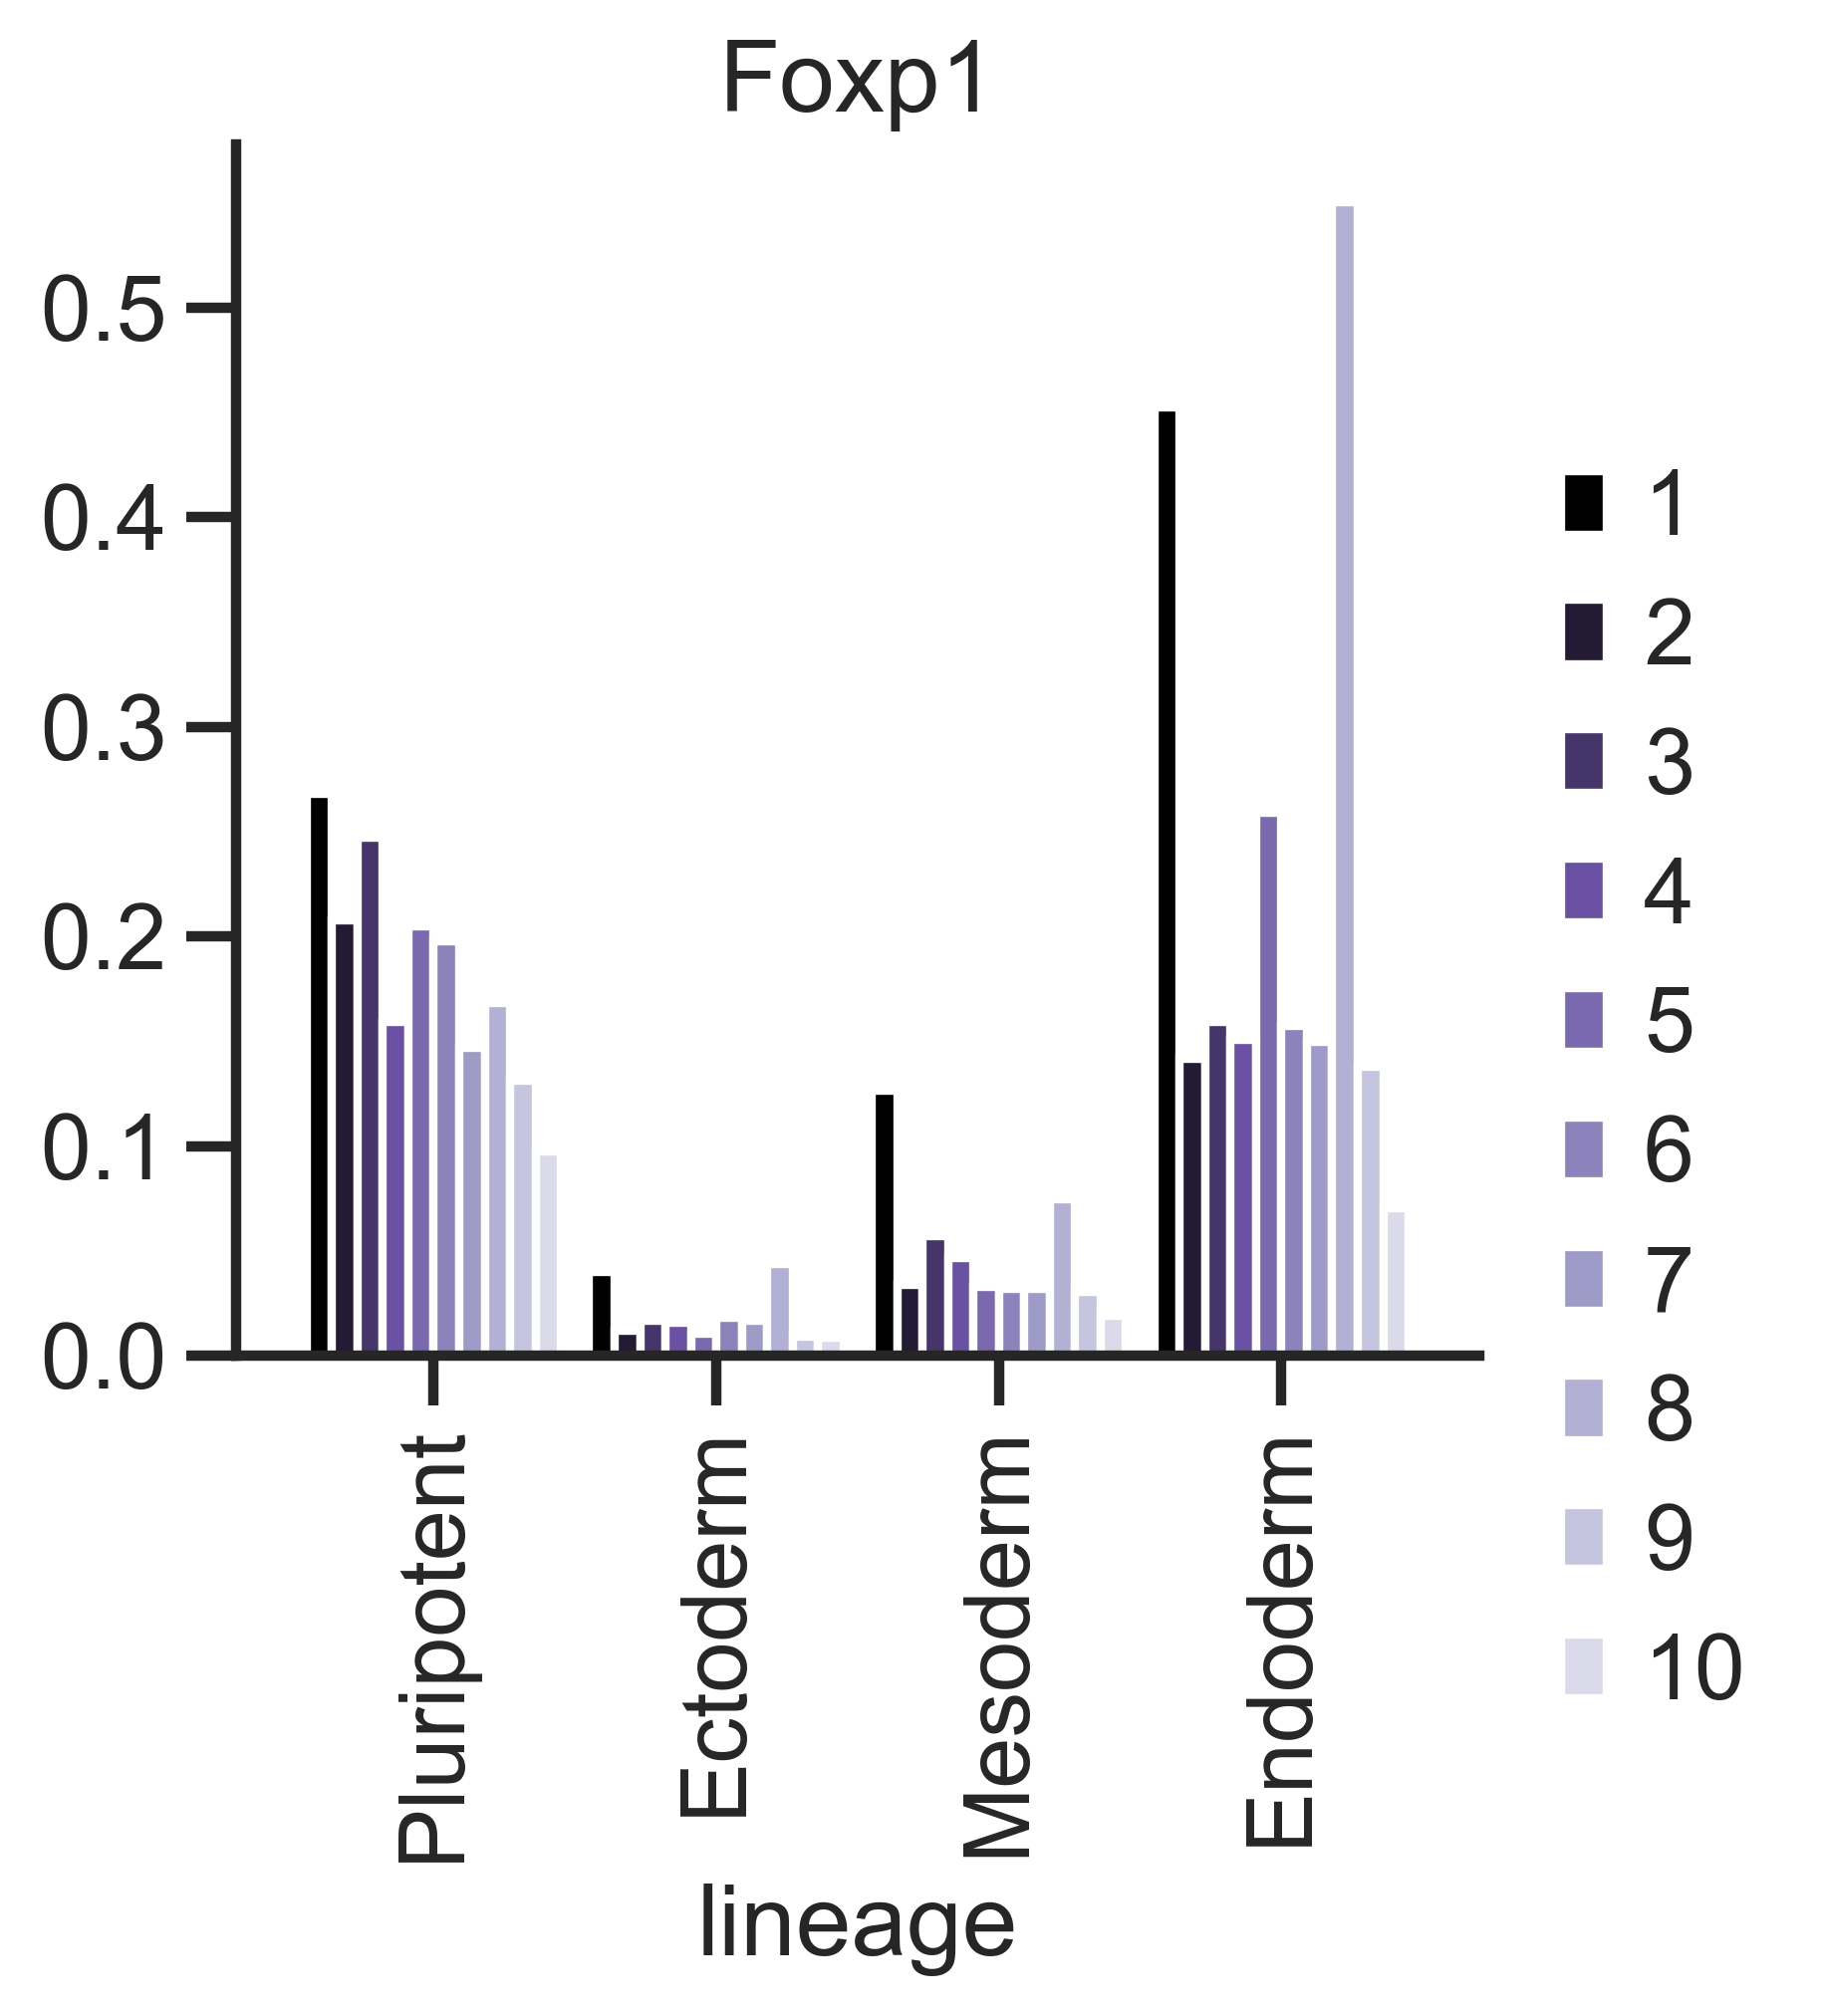

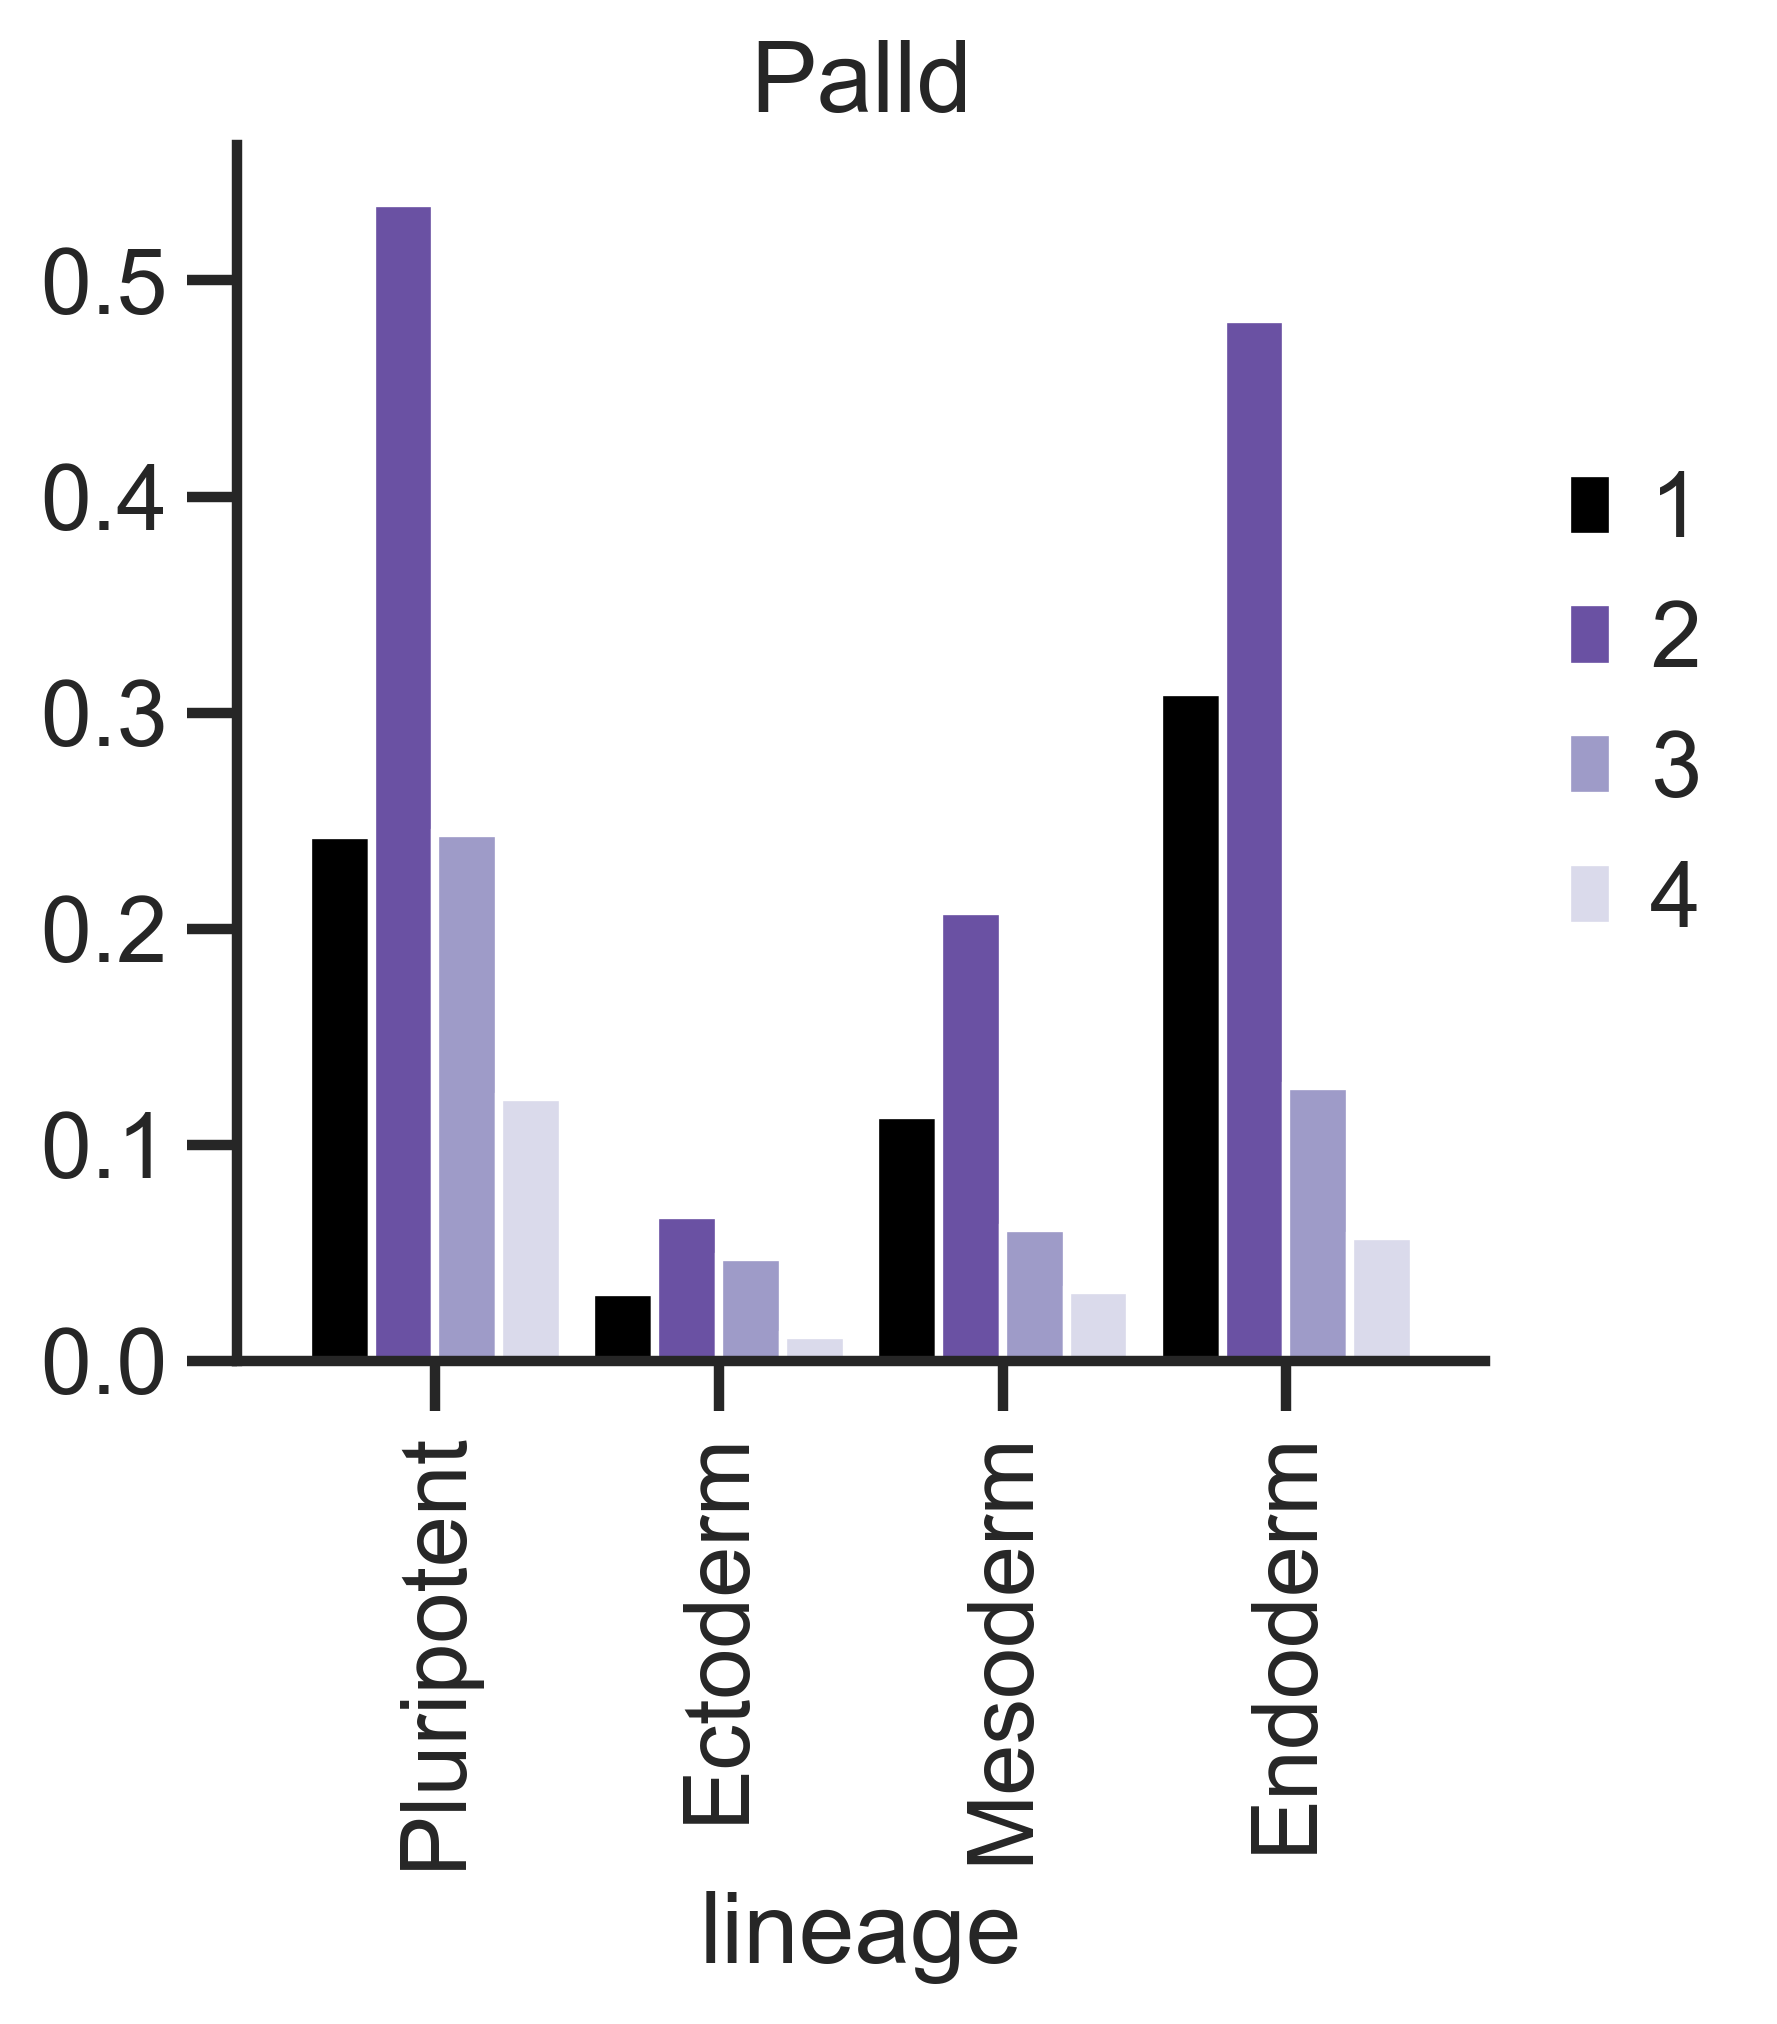

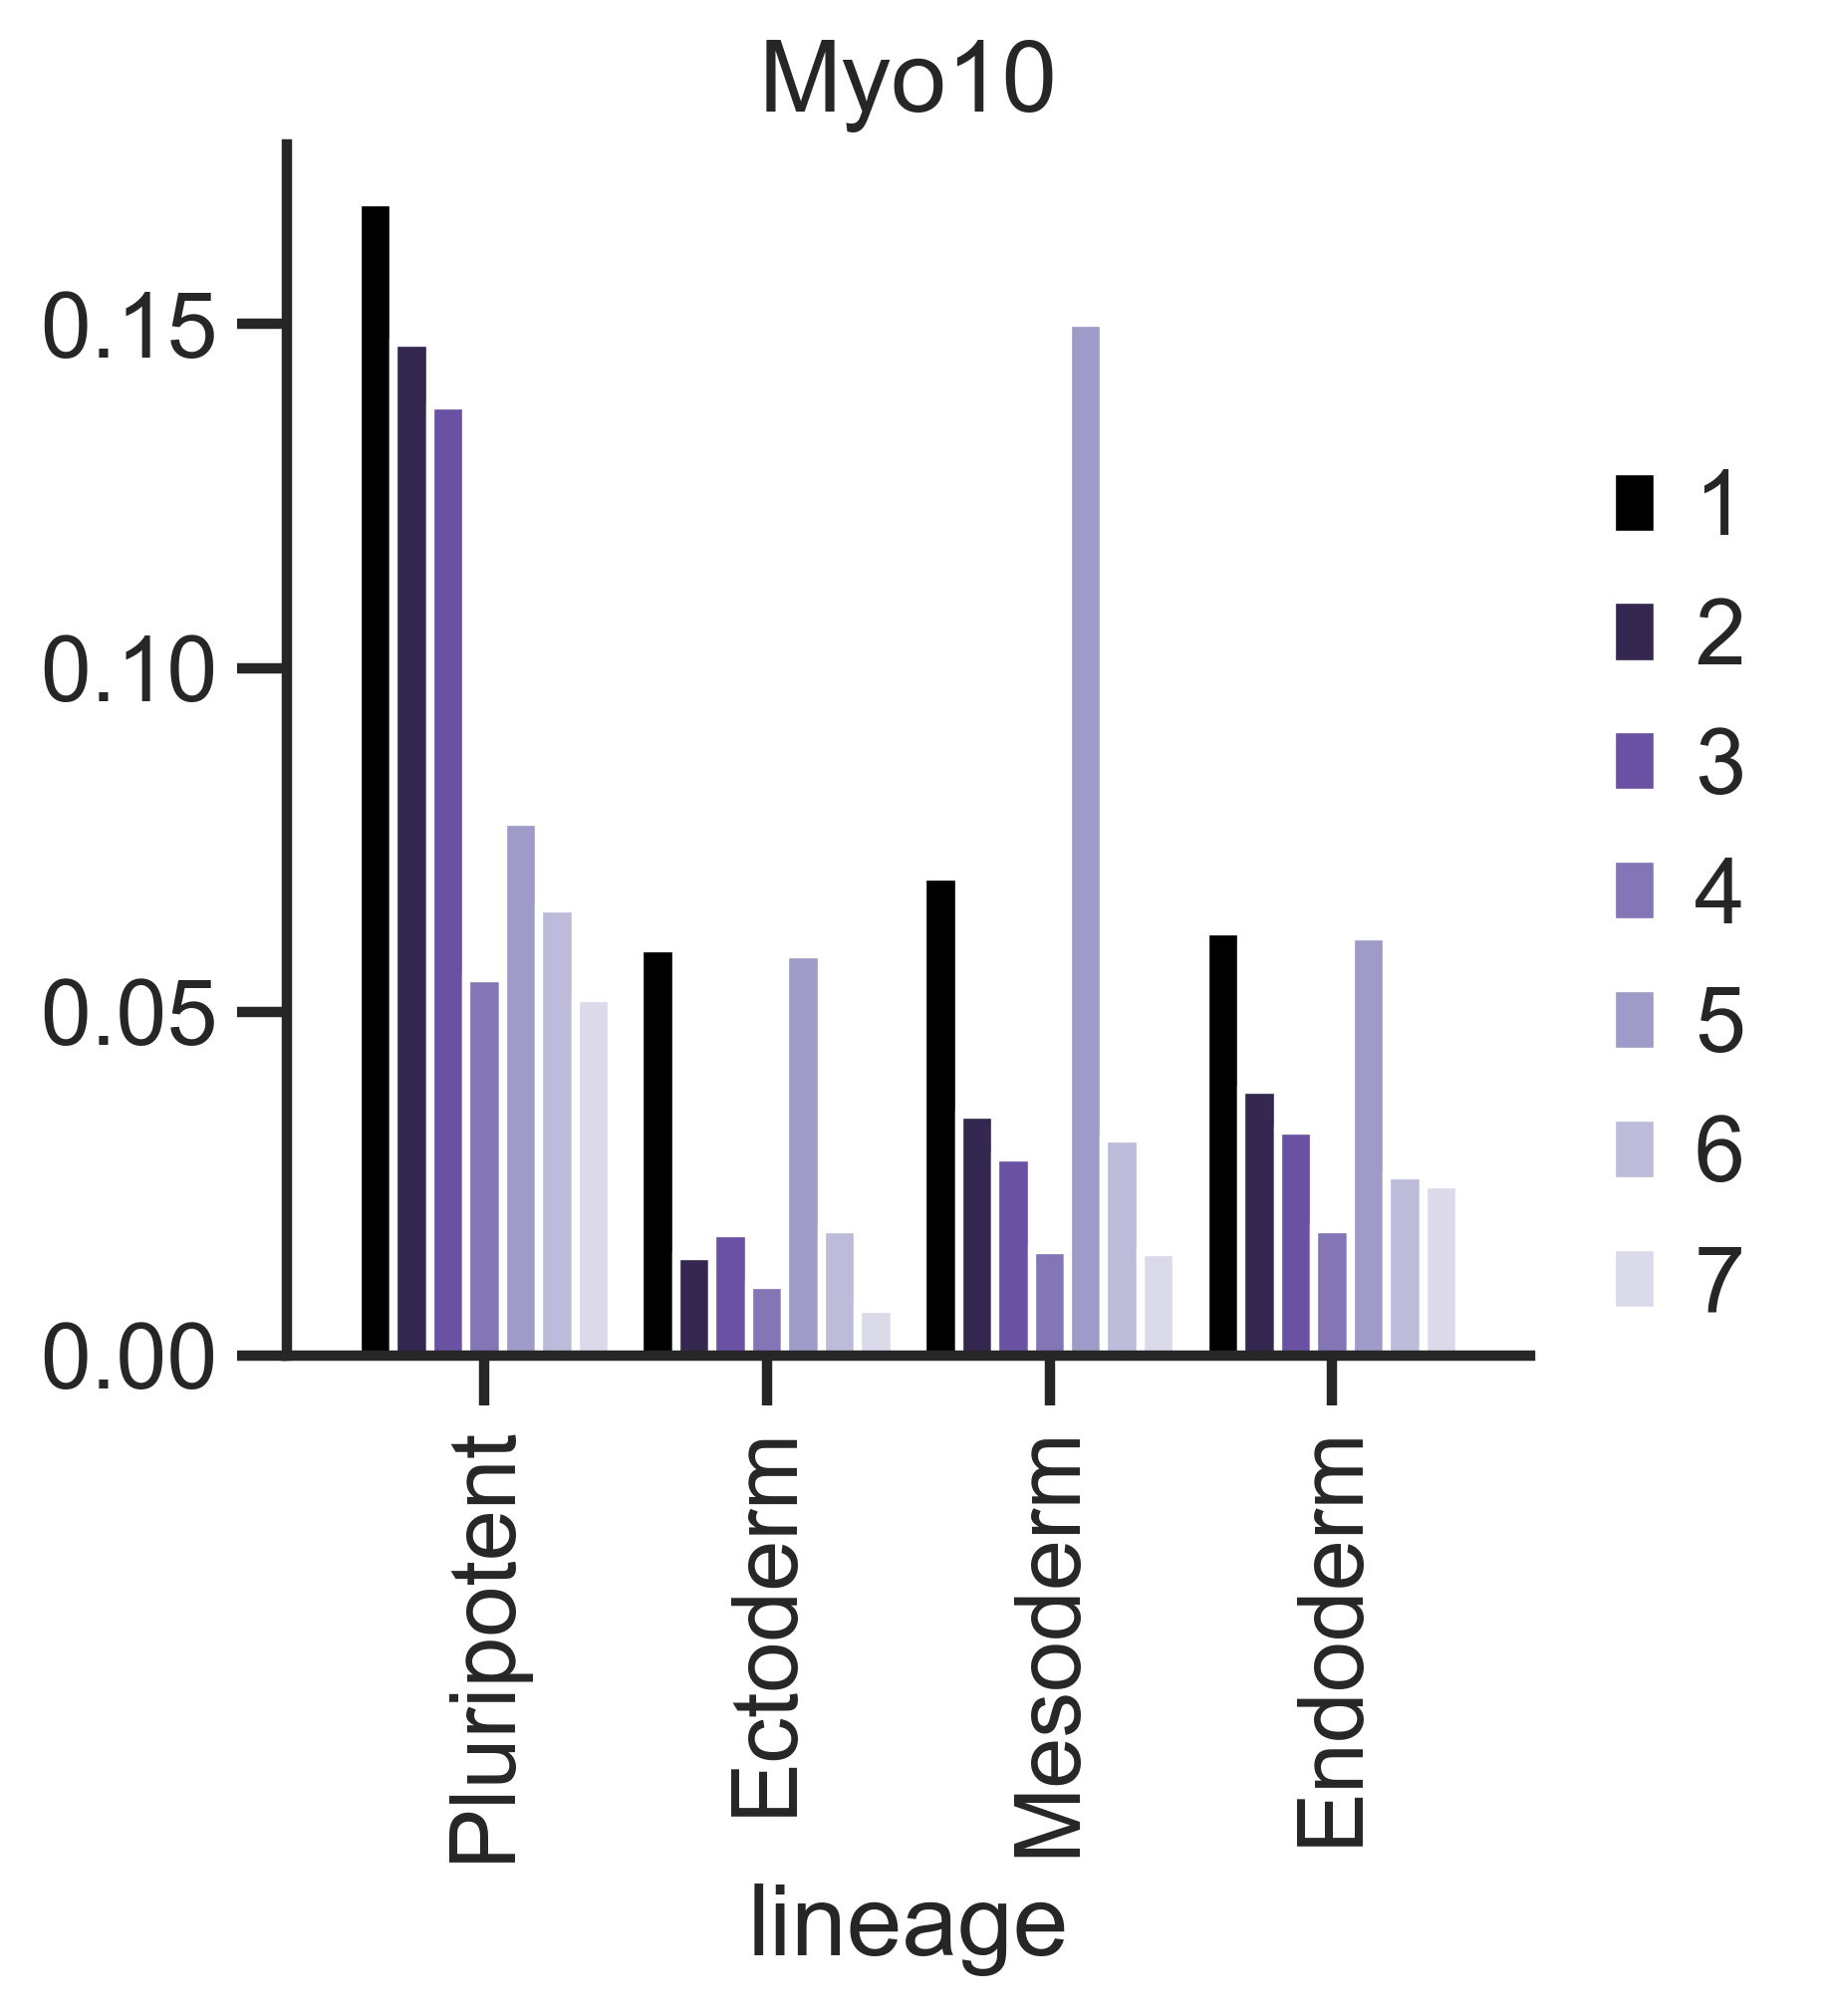

In [67]:
for gene in genes:
    df_test2[gene].plot.bar(stacked=False,width = 0.9, figsize = (4,4),
                    cmap = purples_r,)
    #plt.yscale('log')
    plt.legend(bbox_to_anchor=(1,0.8),frameon=False)
    plt.title(gene)
    sns.despine()
    plt.show()

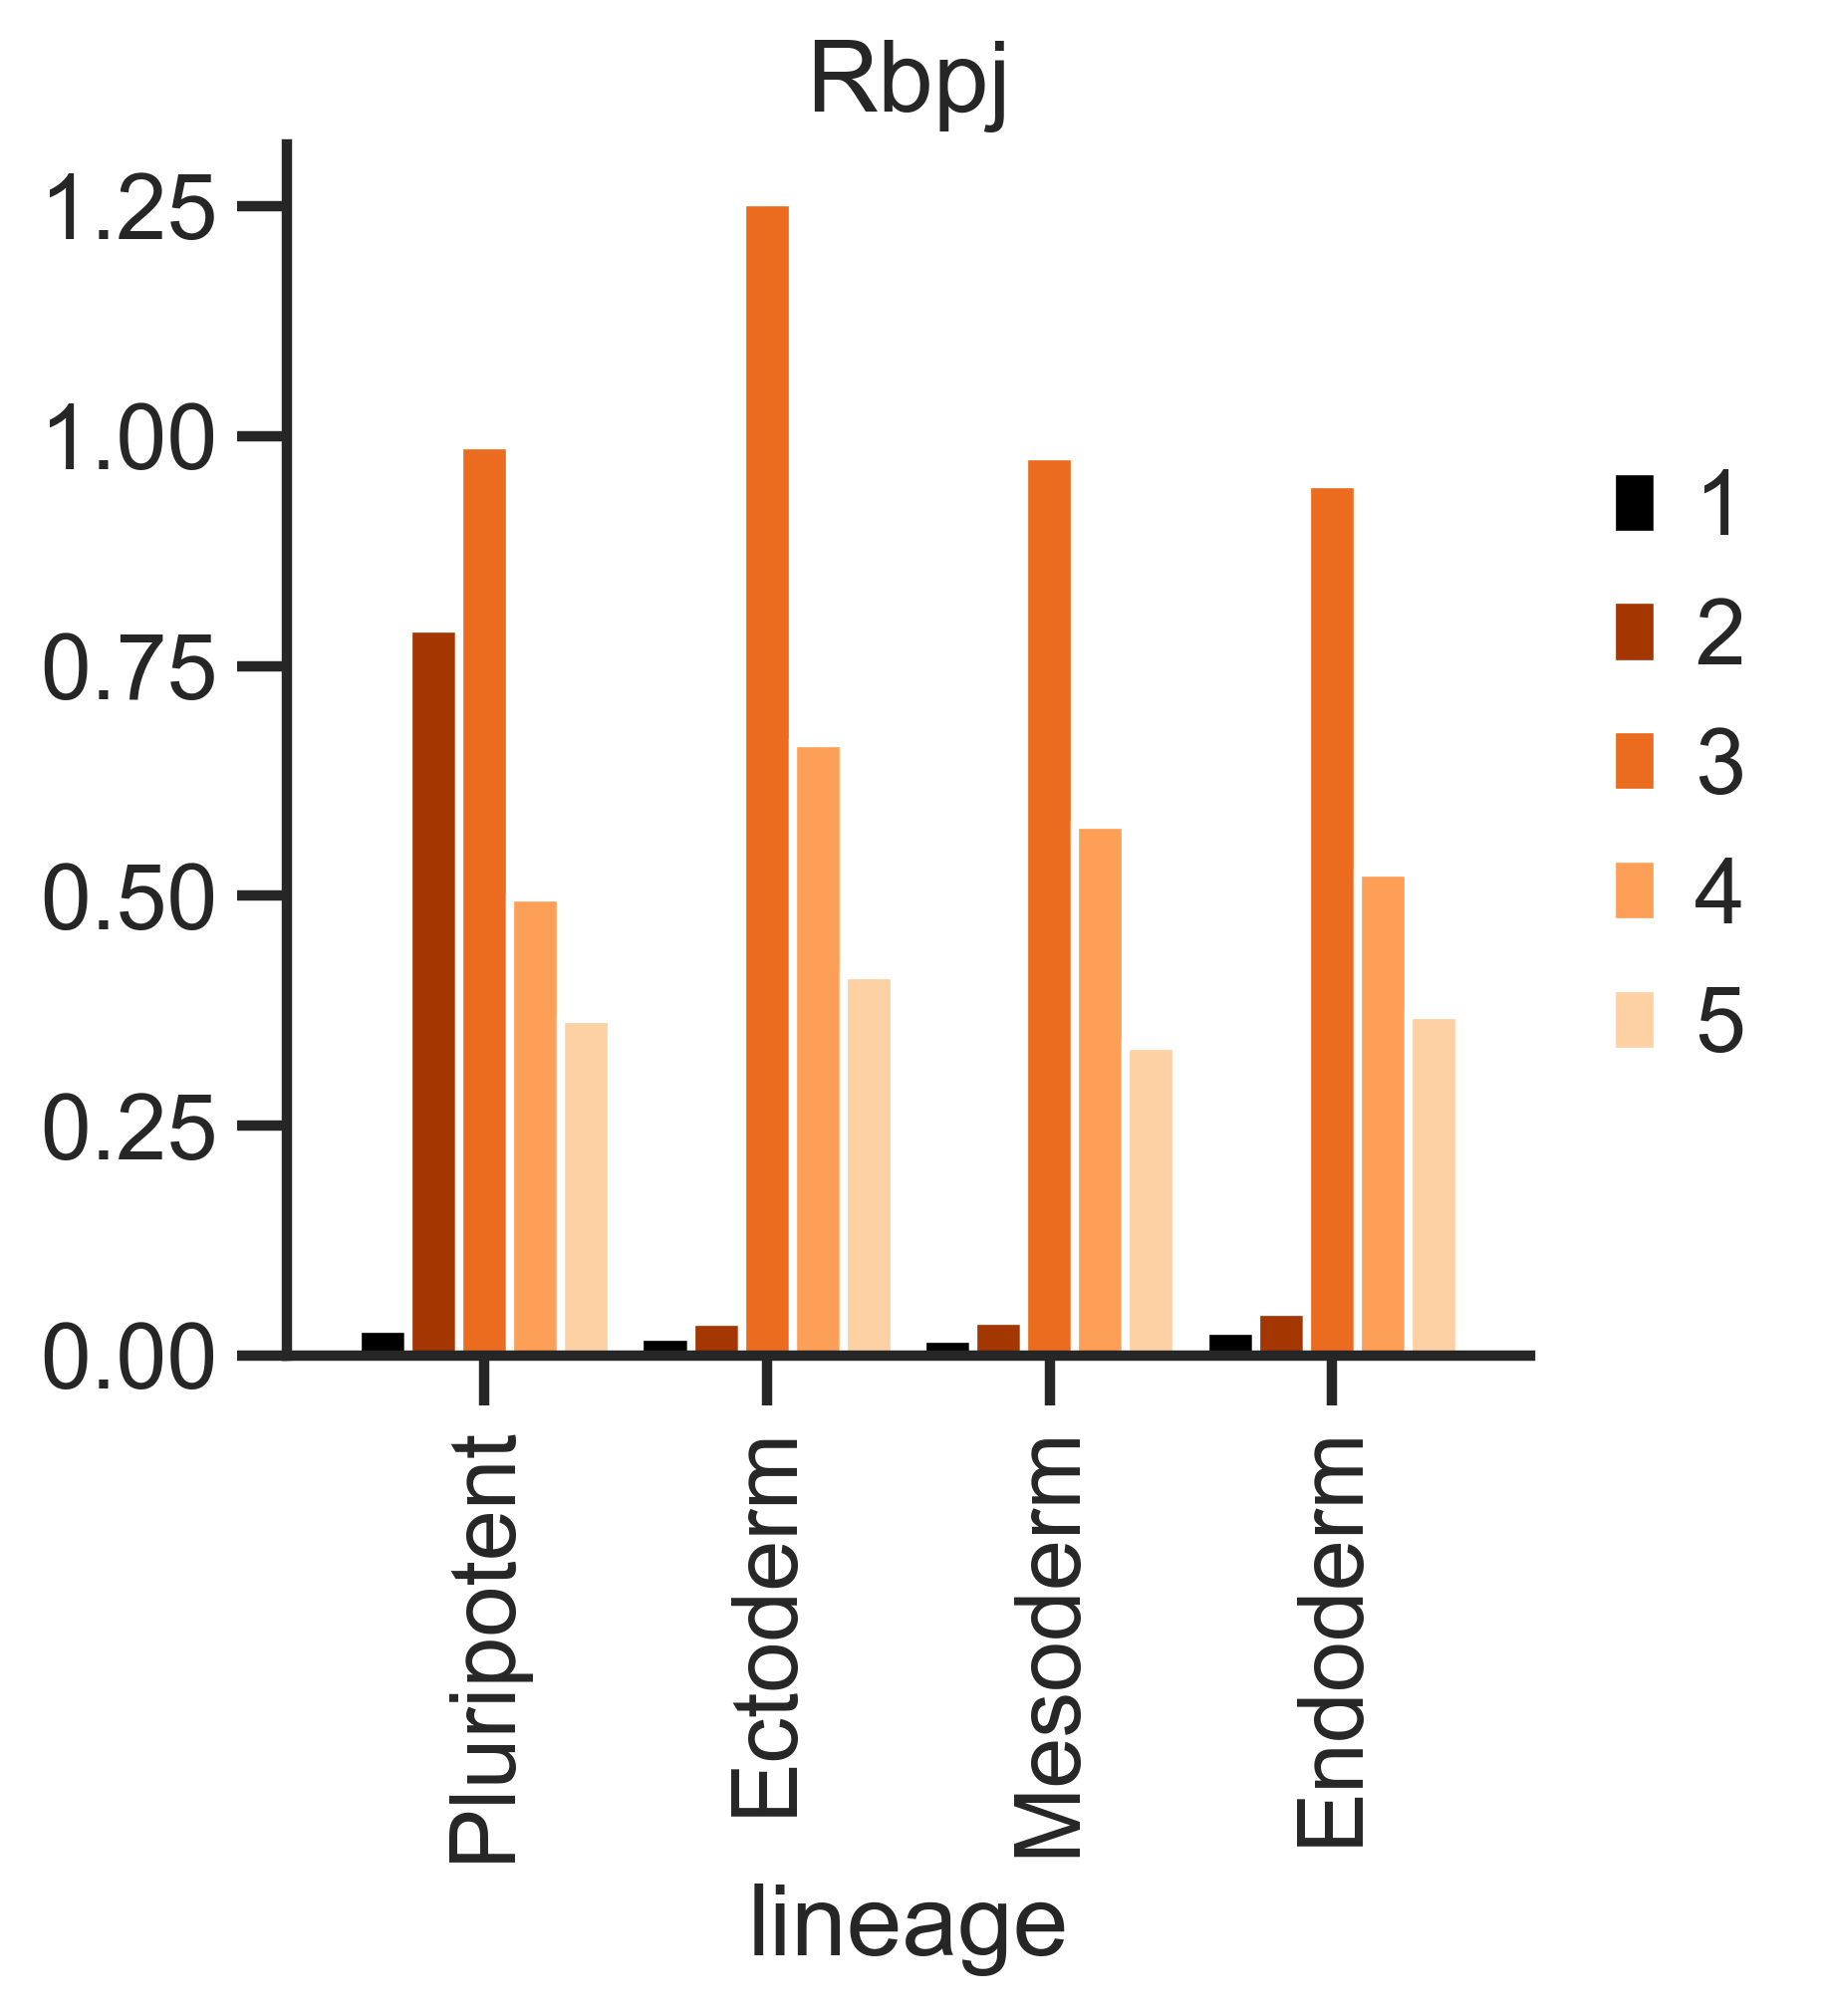

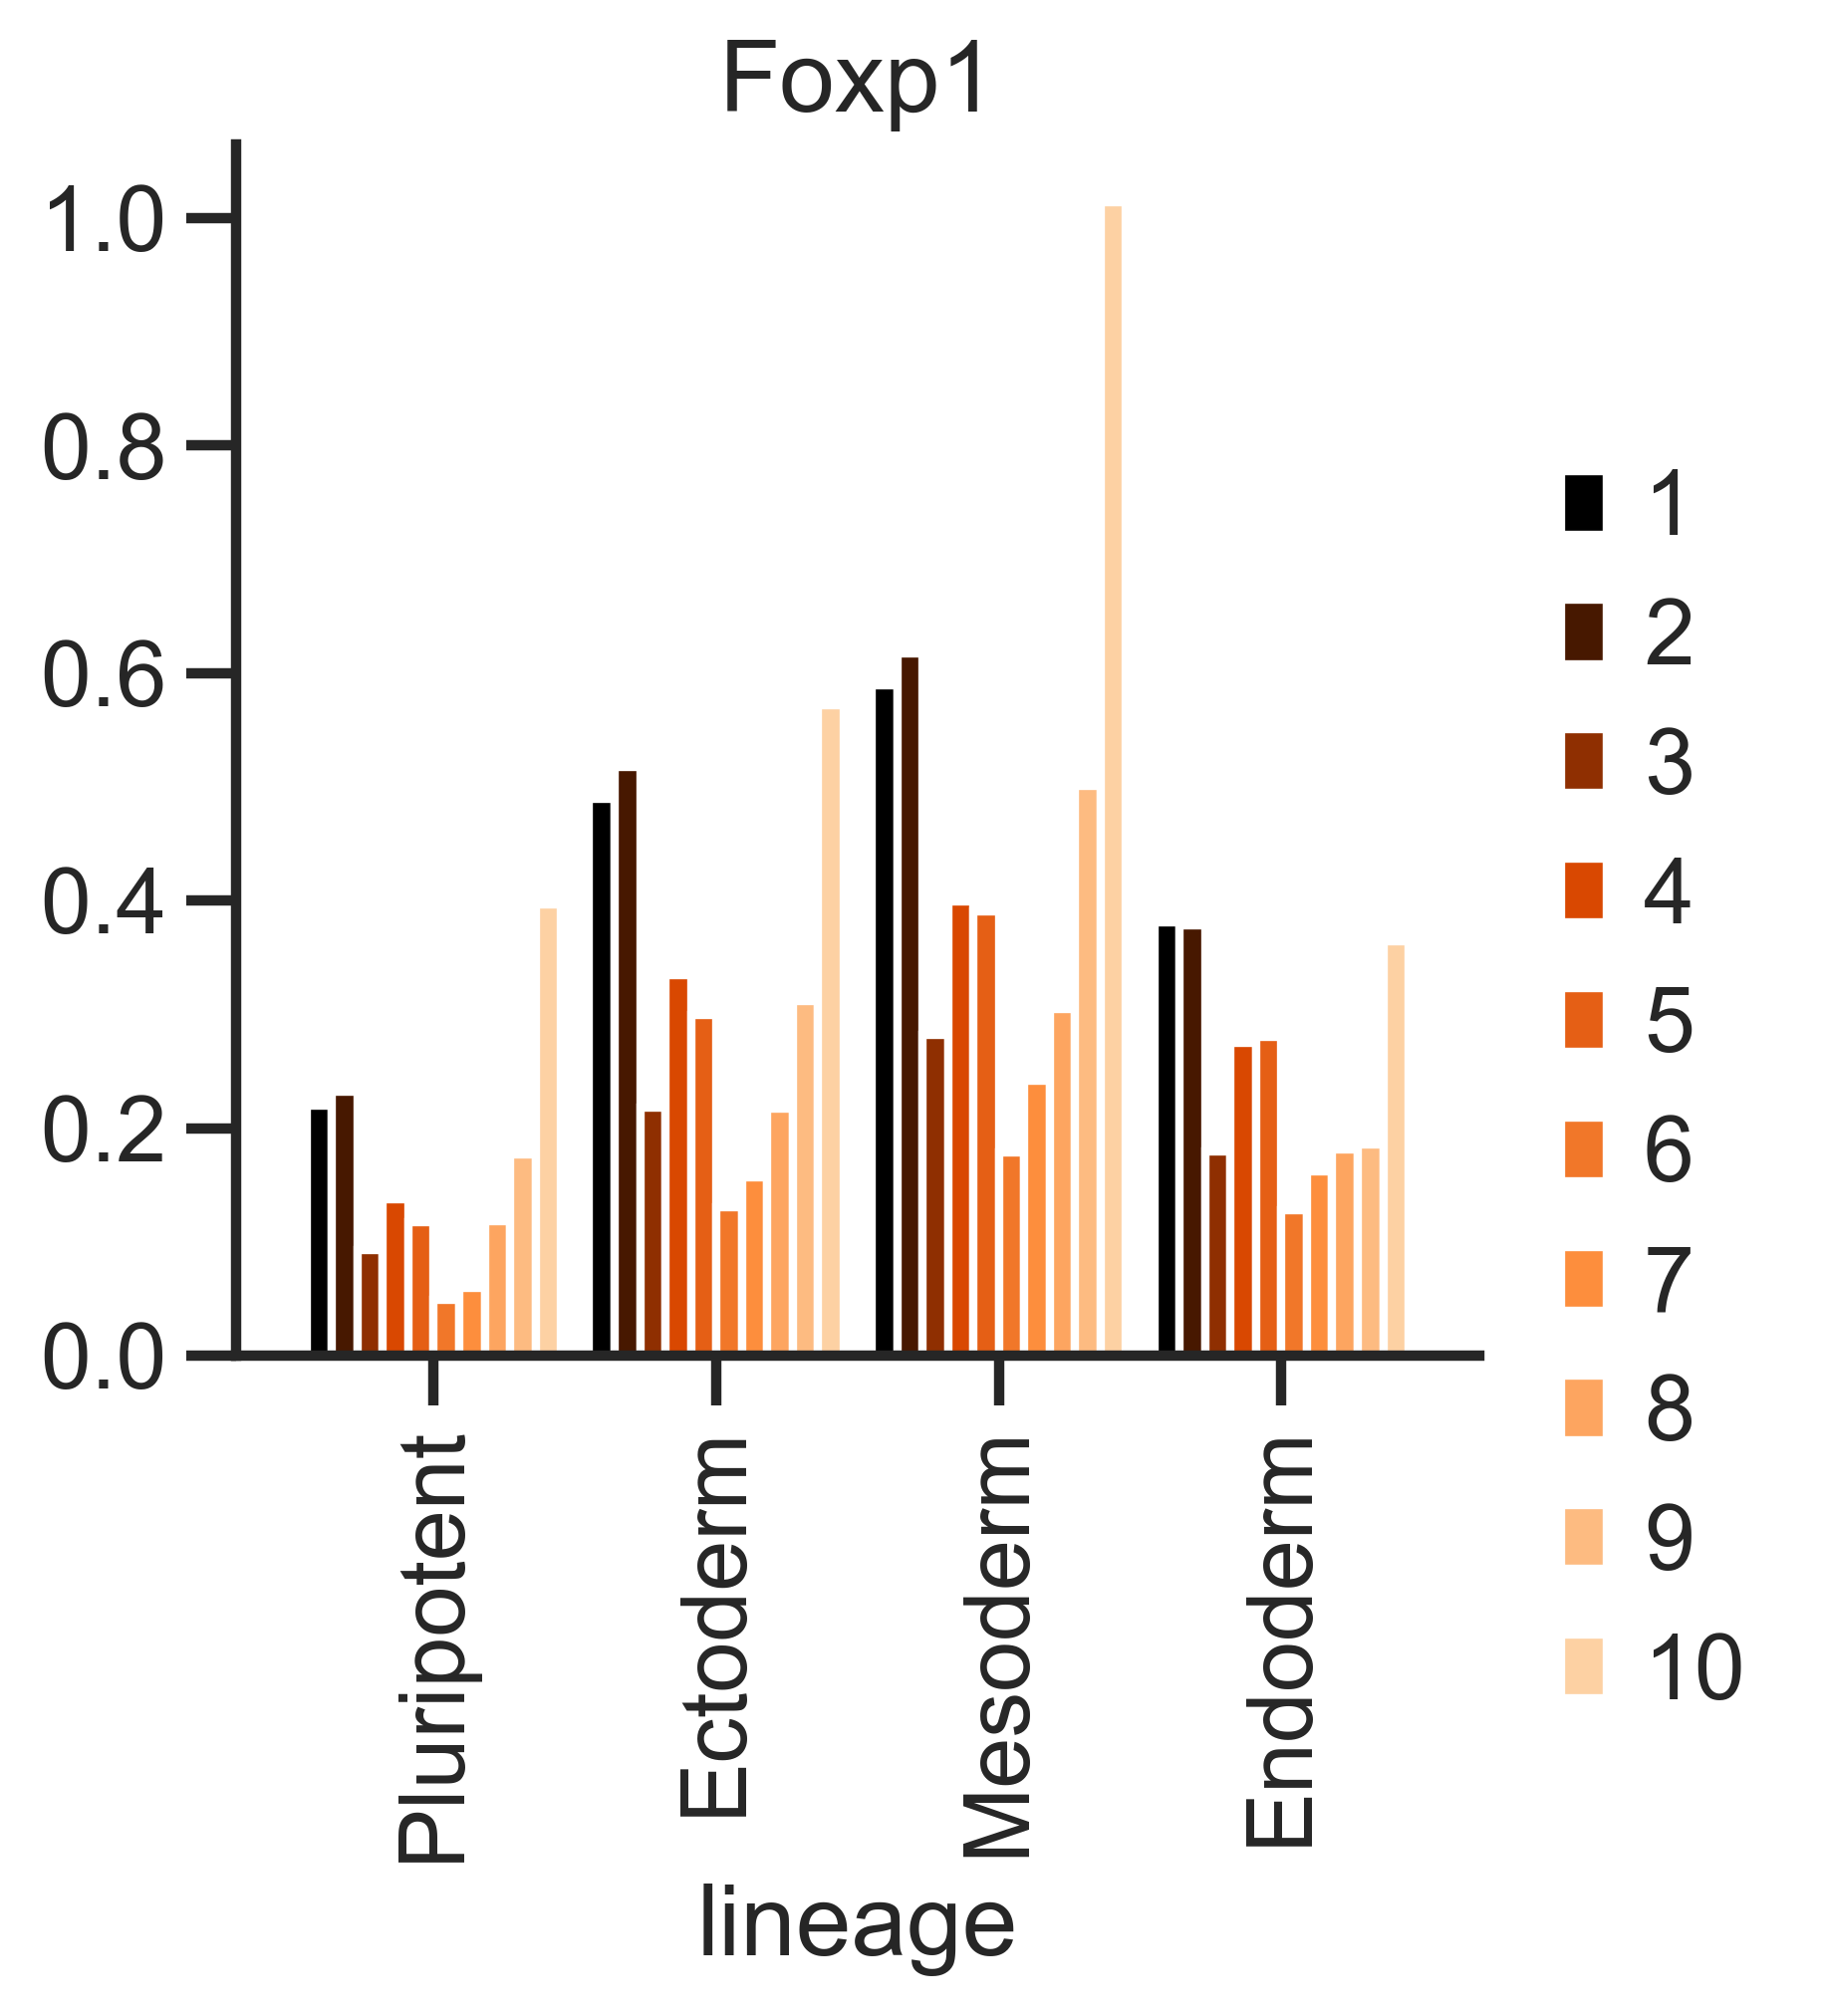

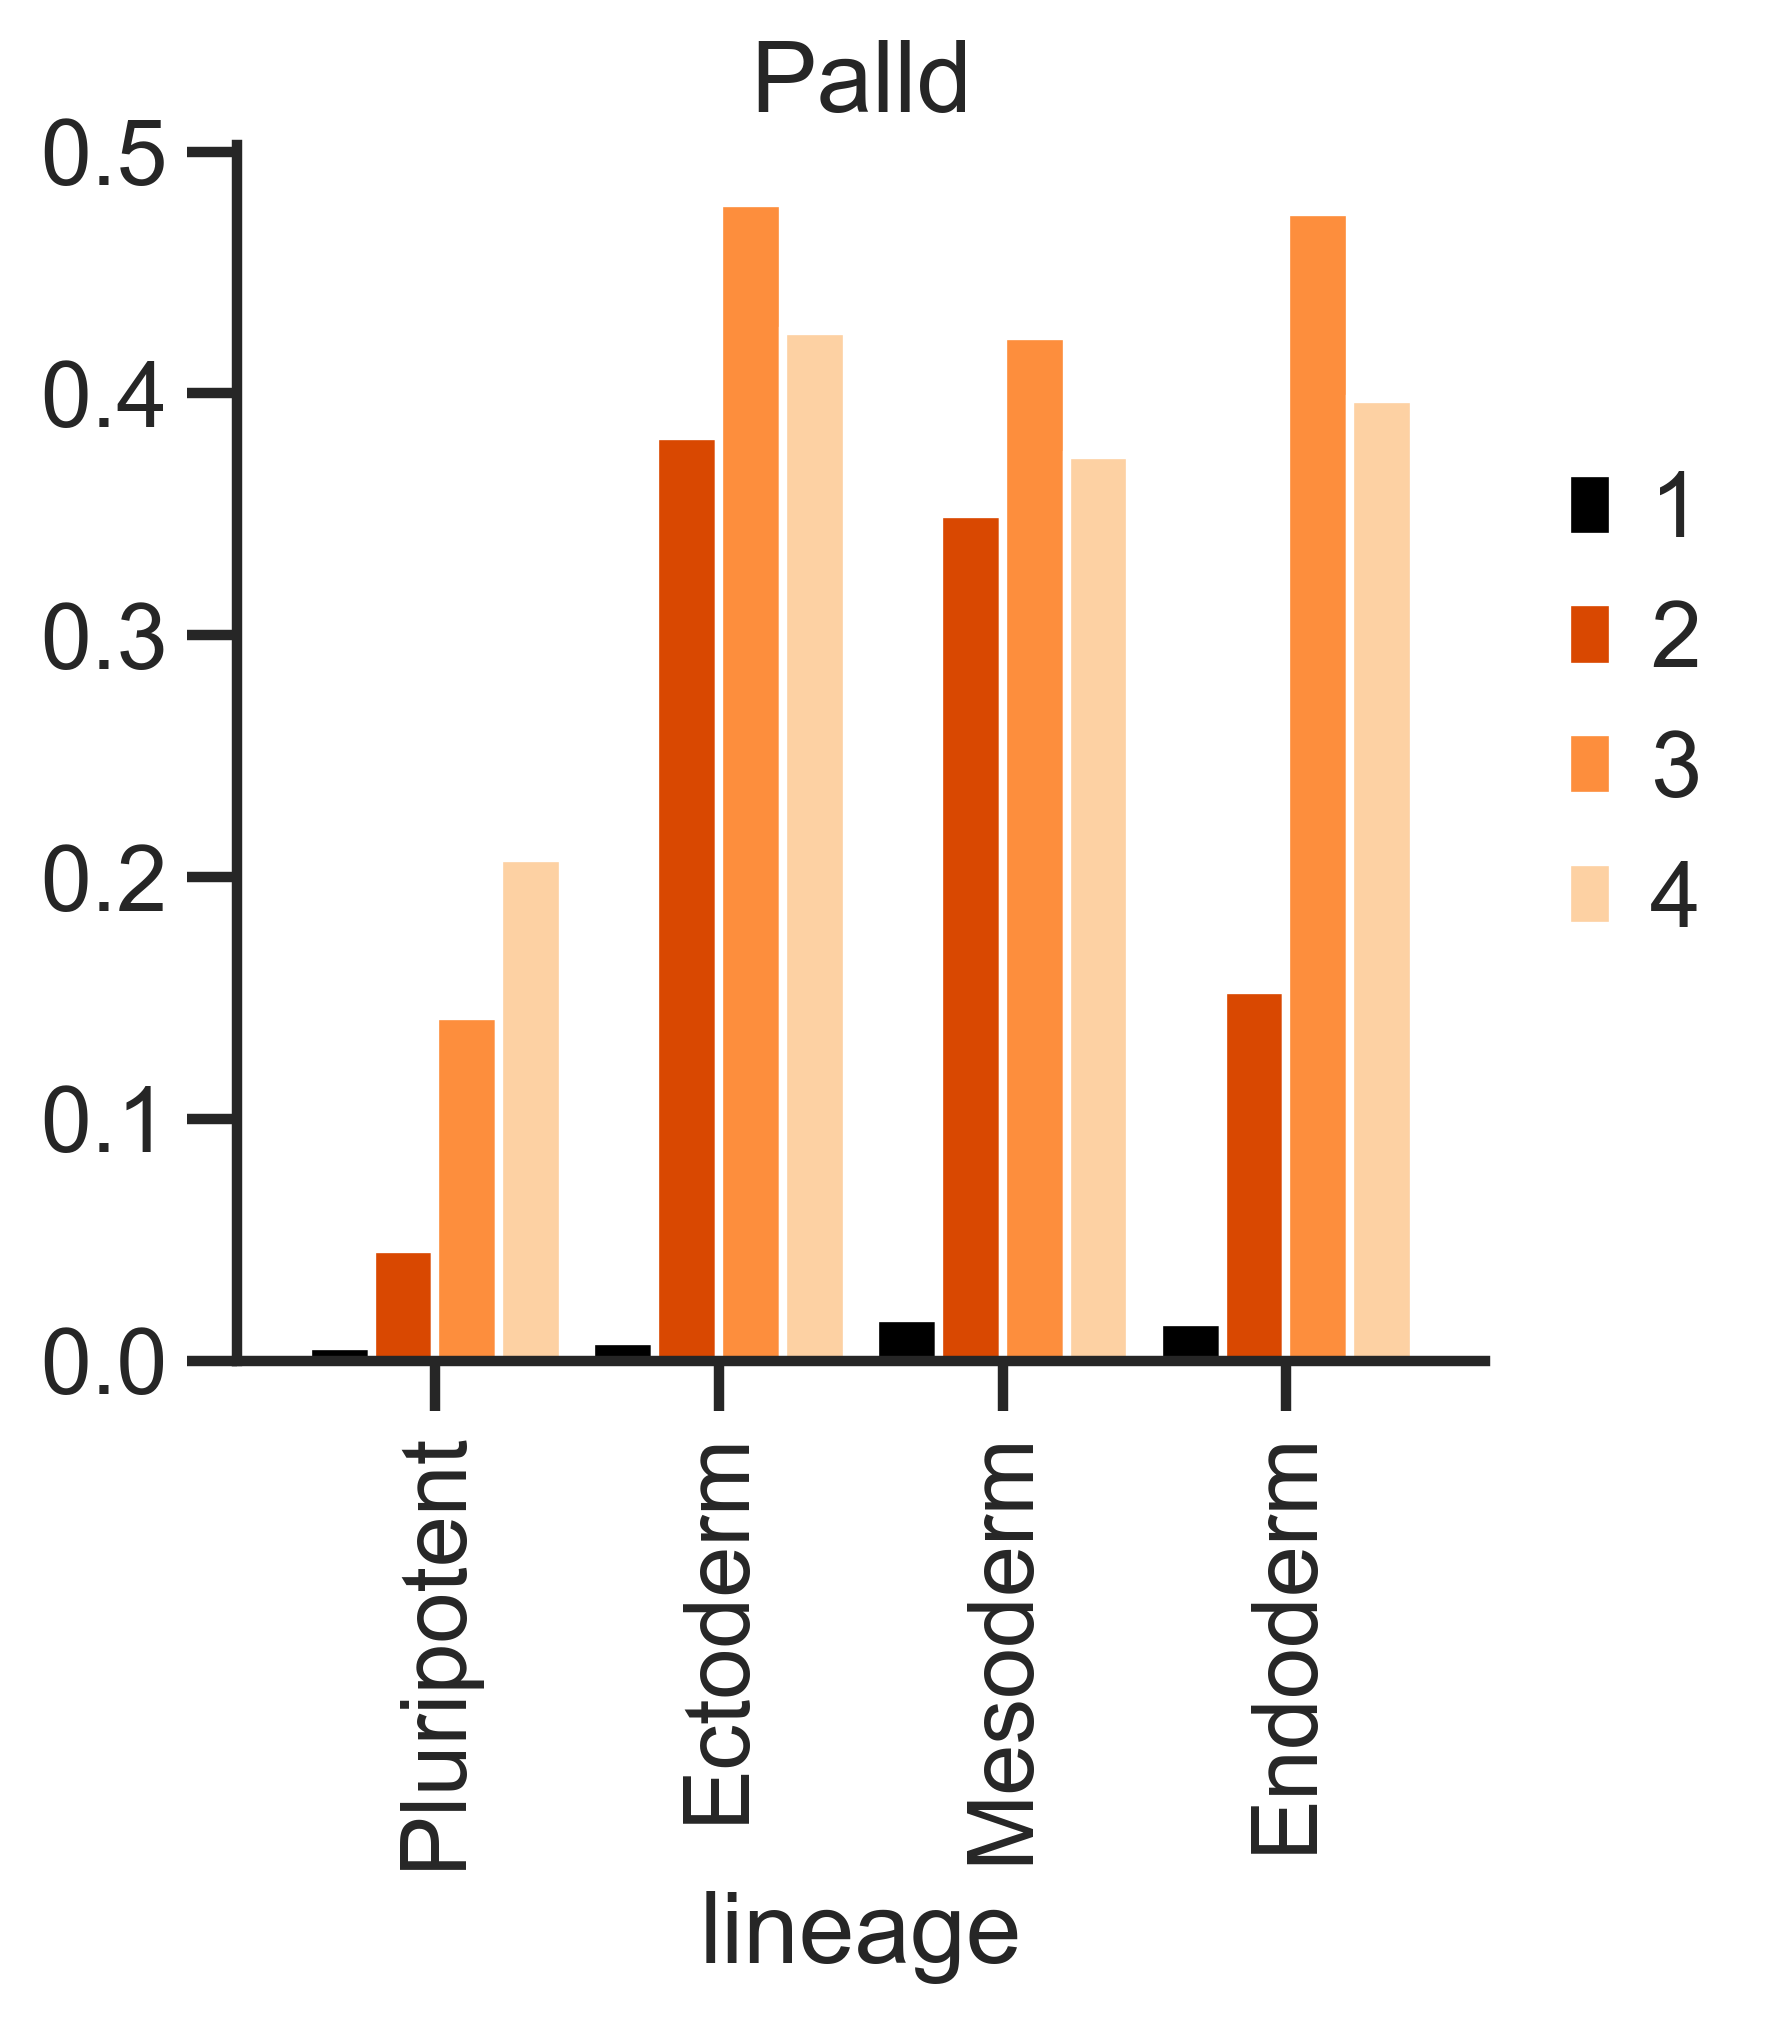

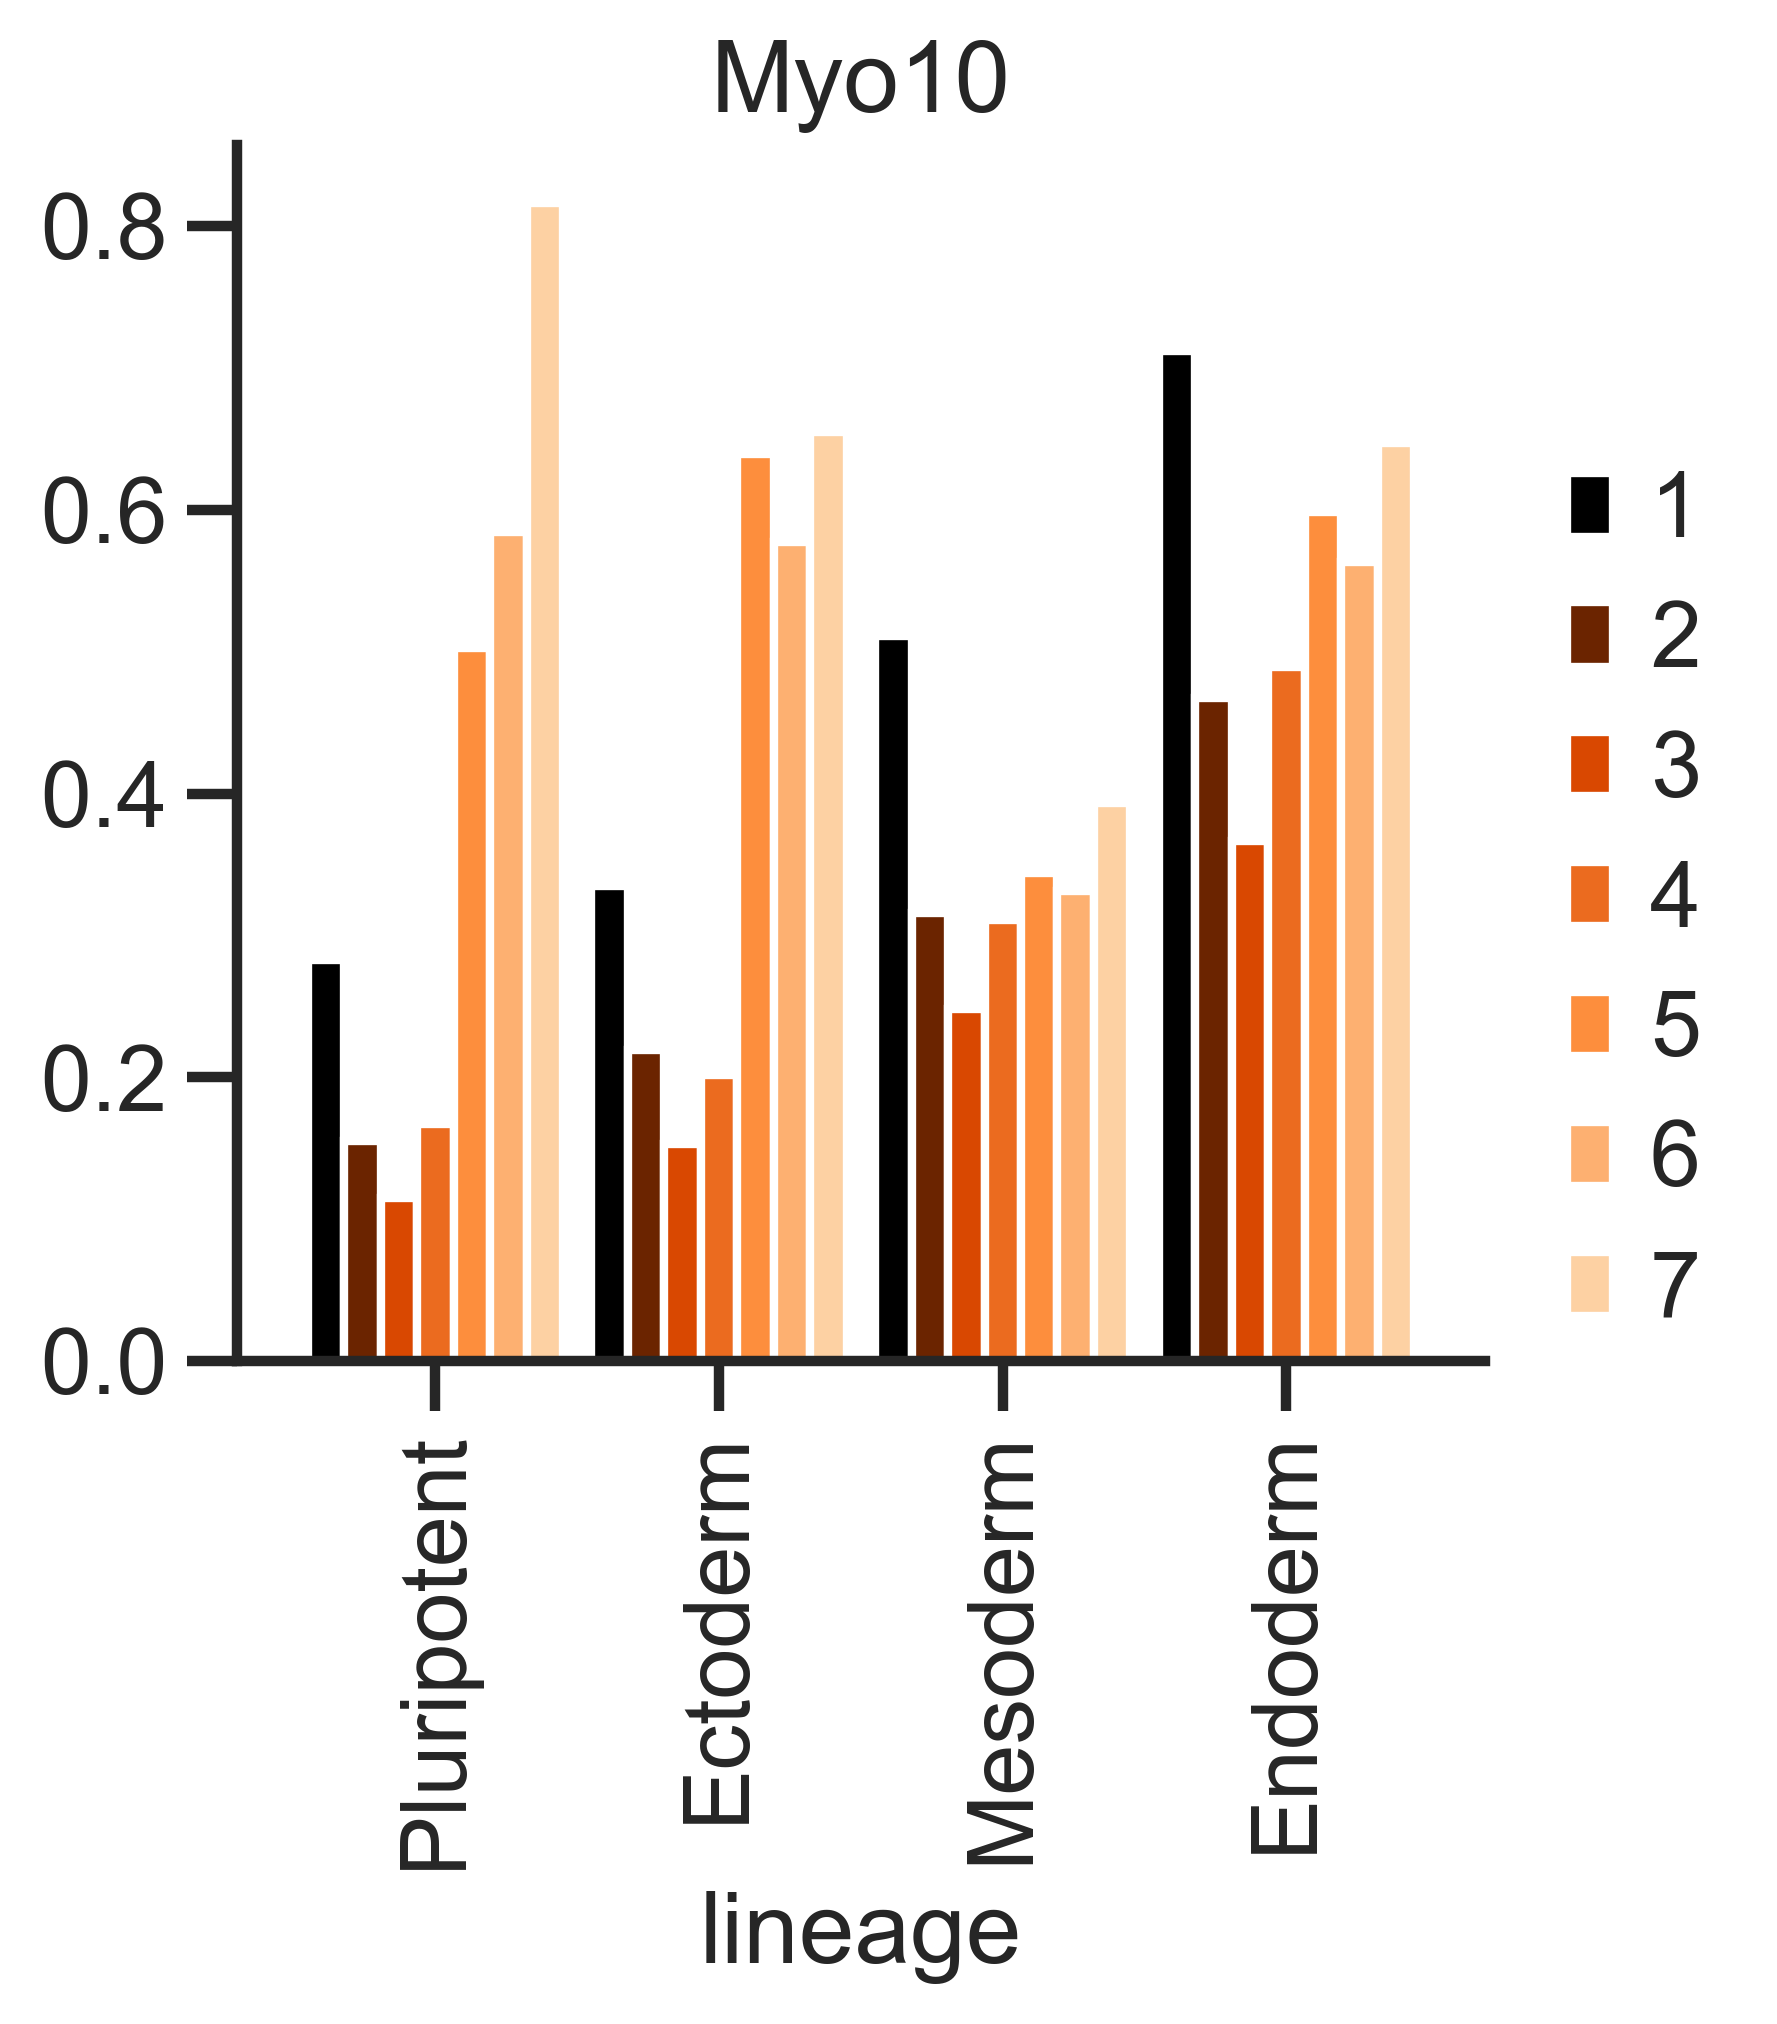

In [68]:
for gene in genes:
    df_test3[gene].plot.bar(stacked=False,width = 0.9, figsize = (4,4),
                    cmap = oranges_r,)
    #plt.yscale('log')
    plt.legend(bbox_to_anchor=(1,0.8),frameon=False)
    plt.title(gene)
    sns.despine()
    plt.show()